# Stage 1: mRNA Stability and Representation Analysis

This notebook studies twelve frozen DNA, RNA, and protein encoders on the stability dataset. Each retained coding sequence supplies DNA letters, RNA letters, and its translated protein. Translation loses synonymous codon distinctions, so these related inputs do not retain identical information. See the [shared model overview and research questions](Stage1_analysis.ipynb#Models-and-input-settings) for the encoders, pretraining context, and role of Stage 1.

Follow [input preparation](#Data) and [embeddings](#Encoders-and-embeddings) into [Track A (decodability)](#Track-A:-Decodability), [Track B (cross-modal geometry)](#Track-B:-Cross-modal-geometry), the [synonymous-recoding control](#Pipeline-control:-synonymous-recoding), [Track C (attention and diagnostics)](#Track-C:-Attention-and-exploratory-diagnostics), and the [published-split comparison](#Published-split-comparison) with BioLangFusion. The [GTEx experiment](Stage1_gtex.ipynb) repeats the main analyses with genomic DNA, transcripts, and proteins as distinct inputs; neither notebook requires the other to run.

**Saved results.** Outputs and execution counts are retained from the combined Stage 1 notebook; they do not record a new run of this separated notebook. For a new run, start a fresh kernel and run this notebook from its own setup, using `Code/` as the working directory. See [environment setup](../README.md#setup).


---

## Setup

### Imports

Imports are grouped by purpose; the analysis functions come from the shared `mbf` package. The next cell sets `PYTORCH_ENABLE_MPS_FALLBACK` with `setdefault` before importing PyTorch, preserving any existing value. This ordering matters when using the Apple GPU backend. See [Notebook dependencies](../README.md#notebook-dependencies) for environment preparation and MPS fallback details.


In [1]:
# Standard library
import itertools
import os

# Run any operation the Apple GPU backend lacks on the CPU; must precede importing torch
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# Data handling and pretrained encoders
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

# Shared project code in Code/mbf
from mbf import analysis, datasets, embeddings, encoders, sequences, splits
from mbf.notebook import show_source

### Implementation displays

`SHOW_IMPLEMENTATION = False` gives compact links to the maintained functions beside each method. Set it to `True`, run the setting, and rerun a chosen `show_source` cell to see its full Python source. These display cells inspect code without executing the analysis functions. See [Reading implementation code](../README.md#reading-implementation-code) for usage and source-link behavior.


In [ ]:
SHOW_IMPLEMENTATION = False


### Analysis settings

Run these settings groups in order before the stability analyses; relative paths use `Code/` as the working directory. The final group selects the device and displays the encoder registry. GTEx has its own settings in the [GTEx notebook](Stage1_gtex.ipynb#Analysis-settings).

#### Seed, stability sample, and control

`SEED` initializes PyTorch here and is passed to the sampling and analysis calls that use it. The [Reproducibility](#Reproducibility) section explains the probe helpers' separate fold-seed behavior.

`DATASET` selects the main coding-sequence dataset, `N_ROWS` sets the number sampled before filtering, and `CONTROL_DATASET` selects the synonymous-recoding control. Filtering can reduce the sample. See [sampling and retained rows](../docs/methods/inputs-and-embeddings.md#sampling-and-retained-rows).


In [ ]:
SEED = 42
torch.manual_seed(SEED)

# Dataset from the mbf.datasets registry, and the pilot sample size before filtering
DATASET = "mrna_stability"
N_ROWS = 1000

# Synonymous-recoding control dataset
CONTROL_DATASET = "mrfp_expression"



#### Shared encoder selection

`ENCODER_KEYS` selects registered encoders and sets their table order. `REFERENCE_KEYS` selects the one-per-modality concatenation and layerwise heatmaps. The registry table below records checkpoints, revisions, and token limits. Token limits differ from nucleotide limits: a token can represent a nucleotide, several nucleotides, a codon, or an amino acid. Special tokens also occupy positions. The structural-proxy crop is measured in nucleotides. See [tokens and input limits](../docs/methods/inputs-and-embeddings.md#tokens-and-input-limits) for the encoder-specific distinctions.


In [ ]:
# Encoders from the mbf.encoders registry; this order sets the row and column order of every table
ENCODER_KEYS = [
    "nt500m", "ntv2_100m", "dnabert2", "hyenadna",   # DNA
    "rnafm", "rinalmo", "mrnafm", "calm",            # RNA: single-nucleotide, then codon tokens
    "esm2_8m", "esm2_35m", "esm2_150m", "protbert",  # protein
]
ENCODERS = [encoders.ENCODERS[key] for key in ENCODER_KEYS]
LABELS = {e.key: e.label for e in ENCODERS}
MODALITY = {e.key: e.modality for e in ENCODERS}

# One encoder per modality, in ENCODER_KEYS order
REFERENCE_KEYS = ["nt500m", "rnafm", "esm2_35m"]



#### Probe, diagnostic, and benchmark limits

`N_FOLD_ASSIGNMENTS` controls the additional probe partitions, as explained in the [probe evaluation walkthrough](../docs/methods/linear-probing.md#evaluation-and-interpretation). `PCA_TOP_K` controls the [high-variance block](#High--and-low-variance-directions), and `ATTENTION_NULL_PERMUTATIONS` controls the [attention null shuffles](#Controlling-the-attention-test-for-position-and-codons). `BENCHMARK_N_TRAIN` and `BENCHMARK_N_TEST` set the [published-split comparison](#Published-split-comparison) sample sizes.


In [ ]:
# Probe evaluation: further grouped fold assignments summarized after the pinned one
N_FOLD_ASSIGNMENTS = 10

# Additional analysis limits
LAYERWISE_N_ROWS = 200      # rows sampled before filtering
STRUCTURE_N_ROWS = 200      # retained rows
STRUCTURE_CROP_LEN = 200    # nucleotides
ATTENTION_N_ROWS = 100      # first retained rows

# Layer-wise CKA heatmaps to draw; every pair is summarized in a table
LAYERWISE_PLOT_PAIRS = list(itertools.combinations(REFERENCE_KEYS, 2))
LAYERWISE_CODON_PAIRS = [("mrnafm", "calm"), ("mrnafm", "esm2_35m"), ("calm", "esm2_35m")]

# Principal components in the high-variance block
PCA_TOP_K = 10

# Nucleotide encoders whose models return attention weights, and shuffles for the permutation nulls
ATTENTION_ENCODERS = [
    k for k in ENCODER_KEYS if MODALITY[k] in ("DNA", "RNA") and encoders.ENCODERS[k].attention
]
ATTENTION_NULL_PERMUTATIONS = 500

# Published-split comparison: rows sampled from the published train and test splits before filtering
BENCHMARK_N_TRAIN = 3000
BENCHMARK_N_TEST = 1000



#### Embedding caches, device, and encoder overview

`DEVICE` prefers CUDA, then MPS, then CPU. Package installation and compatibility guidance are in [Notebook dependencies](../README.md#notebook-dependencies). See [cache reuse](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse) for how saved matrices are checked.


In [2]:
# Saved embeddings, one folder per dataset sample
EMBEDDING_DIR = os.path.join("stage1_embeddings", f"{DATASET}_n{N_ROWS}_seed{SEED}")
CONTROL_EMBEDDING_DIR = os.path.join("stage1_embeddings", f"{CONTROL_DATASET}_n{N_ROWS}_seed{SEED}")
BENCHMARK_TRAIN_DIR = os.path.join("stage1_embeddings", f"{DATASET}_published_train{BENCHMARK_N_TRAIN}_seed{SEED}")
BENCHMARK_TEST_DIR = os.path.join("stage1_embeddings", f"{DATASET}_published_test{BENCHMARK_N_TEST}_seed{SEED}")

DEVICE = encoders.select_device()
print("Using device:", DEVICE)

pd.DataFrame(
    [
        {"encoder": e.label, "modality": e.modality, "checkpoint": e.checkpoint,
         "input": e.alphabet, "token limit": e.max_len, "attention": e.attention,
         "revision": e.revision or "latest"}
        for e in ENCODERS
    ]
).set_index("encoder")

Using device: mps


,modality,checkpoint,input,token limit,attention,revision
encoder,,,,,,
NT 500M human-ref,DNA,InstaDeepAI/nucleotide-transformer-500m-human-ref,dna,1000,True,latest
NT v2 100M multi-species,DNA,InstaDeepAI/nucleotide-transformer-v2-100m-mul...,dna,2048,True,f34324c6fde36a4f635f0f1f06cac5d25acd6798
DNABERT-2,DNA,zhihan1996/DNABERT-2-117M,dna,1024,False,7bce263b15377fc15361f52cfab88f8b586abda0
HyenaDNA large,DNA,multimolecule/hyenadna-large,dna,1000000,False,928e4a8cf67eab56be6e9c517b1a155faca0b1e1
RNA-FM,RNA,multimolecule/rnafm,rna,1024,True,latest
RiNALMo 150M,RNA,multimolecule/rinalmo-mega,rna,1024,True,5e3a682eb856148fe81f12a25301962c9ffaf0ed
mRNA-FM,RNA,multimolecule/mrnafm,rna,1024,True,latest
CaLM,RNA,multimolecule/calm,rna,1026,True,63fb4125a6139353defa40cbdb0c2f5e76a8cc75
ESM-2 8M,protein,facebook/esm2_t6_8M_UR50D,protein,1024,True,latest


### Reproducibility

Sampling, stochastic analyses that receive it, and PyTorch initialization use the notebook's `SEED`, currently 42. Individual NumPy generators receive it when constructed. Probe tables have a separate boundary: `analysis.probe_table` calls `probe_scores` without a seed argument, so its pinned folds use the helper's default of 42. Additional assignments use seeds 0 through `N_FOLD_ASSIGNMENTS - 1`. Changing `SEED` alone therefore does not change those probe assignments. See the [fold-assignment procedure](../docs/methods/linear-probing.md#evaluation-and-interpretation).

PyTorch is seeded before loading the encoders. Evaluation mode and disabled gradient tracking are handled by the loading and embedding functions. Reproduction also depends on data, checkpoint revisions, package versions, and settings; a fixed seed alone does not guarantee identical results across environments. The [cache-reuse explanation](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse) identifies which changes the saved-matrix check can detect.


---

## Data

This section loads and filters the stability sample, then audits the full file for published comparisons. The [sequence-preparation guide](../docs/methods/inputs-and-embeddings.md#sequence-checks-and-translation) contains the helper walkthrough and examples.

### Sequence checks and translation

Each retained coding sequence supplies DNA letters to DNA encoders, RNA letters to RNA encoders, and its translation to protein encoders. These inputs share an origin but do not preserve identical information.

#### Checking the sequence length and start

After trimming surrounding whitespace and converting to uppercase, the filter requires a length divisible by three, an `ATG` or `AUG` start, and a translation of at least five amino acids. These preliminary checks do not validate the full alphabet, require a terminal stop codon, or establish a complete biological CDS. See the [length-check equation and example](../docs/methods/inputs-and-embeddings.md#checking-the-sequence-length-and-start).

#### Translating the sequence

`translate_cds` uses the standard genetic code and stops at the first in-frame stop codon, omitting the stop symbol. It does not enable Biopython's `cds=True` validation. The nucleotide inputs retain the supplied sequence even when protein translation stops earlier. See [translation and slicing](../docs/methods/inputs-and-embeddings.md#translating-the-sequence) and the [Biopython documentation](https://biopython.org/docs/latest/api/Bio.Seq.html#Bio.Seq.Seq.translate).

#### Converting between RNA and DNA letters

`rna_to_dna` replaces U with T; `dna_to_rna` replaces T with U. Neither computes a complementary strand nor translates a protein. See the [alphabet-conversion examples](../docs/methods/inputs-and-embeddings.md#converting-between-rna-and-dna-letters).


In [ ]:
show_source(
    sequences.is_in_frame_and_starts_correctly, sequences.translate_cds,
    sequences.rna_to_dna, sequences.dna_to_rna, datasets.is_retained, encoders.encoder_input,
    full=SHOW_IMPLEMENTATION,
)


Implementation: [`sequences.is_in_frame_and_starts_correctly` (line 16)](mbf/sequences.py#L16), [`sequences.translate_cds` (line 22)](mbf/sequences.py#L22), [`sequences.rna_to_dna` (line 28)](mbf/sequences.py#L28), [`sequences.dna_to_rna` (line 33)](mbf/sequences.py#L33), [`datasets.is_retained` (line 86)](mbf/datasets.py#L86), [`encoders.encoder_input` (line 81)](mbf/encoders.py#L81)

### Sampling and retained rows

`datasets.load_dataset` drops rows missing a sequence, samples `N_ROWS` without replacement using `SEED`, then normalizes and filters those sequences. Retained rows keep sample order and their original file indices. The [sampling walkthrough](../docs/methods/inputs-and-embeddings.md#sampling-and-retained-rows) explains the filter counts and row correspondence.

`kept_seqs` and `labels` must remain in matching order for every embedding and target. The stability probes group identical `kept_seqs` strings together in their outer folds; this does not establish independence of related sequences or grouped internal model selection. See the [probe evaluation limitation](../docs/methods/linear-probing.md#current-evaluation-limitation).

This sample does not use the CSV's `Split` column. Published-split evaluation is a separate later analysis, and GTEx uses its own input and grouping path.


In [ ]:
show_source(datasets.load_dataset, datasets.sample_rows, datasets.retain, full=SHOW_IMPLEMENTATION)


Implementation: [`datasets.load_dataset` (line 180)](mbf/datasets.py#L180), [`datasets.sample_rows` (line 146)](mbf/datasets.py#L146), [`datasets.retain` (line 158)](mbf/datasets.py#L158)

In [5]:
dataset = datasets.load_dataset(DATASET, n_rows=N_ROWS, seed=SEED)
kept_seqs, labels = dataset.sequences, dataset.labels

print(
    f"Retained {len(kept_seqs)} of {dataset.n_sampled} sampled rows "
    f"({len(set(kept_seqs))} distinct sequences)."
)
for reason, count in dataset.dropped.items():
    print(f"  Dropped {count} rows that {reason}.")

Retained 981 of 1000 sampled rows (964 distinct sequences).
  Dropped 19 rows that failed the length or start check.
  Dropped 0 rows that translated to fewer than five amino acids.


**Results.** Of the 1,000 sampled rows, 19 failed the length/start check and none translated to fewer than five amino acids, leaving 981 retained rows that contain 964 distinct sequences. The retained count is the same for every encoder because the filters depend only on the sequence.

### Dataset audit for published comparisons

Published fusion results on mRNA stability depend on which rows, splits, and labels were used. Before comparing this notebook's numbers with a paper, the cell below summarizes the full dataset file with `datasets.audit`, not only the 1,000-row sample.

It reports four properties:

1. The number of rows and distinct sequence strings.
2. The rows assigned to each value of the supplied `Split` column, and how many distinct sequences appear in more than one split.
3. How many sequences occur more than once and how many of those carry different `Value` labels. The median standard deviation of labels within one repeated sequence estimates how much the label varies for an identical input.
4. The share of rows at most 1,000 nucleotides long, which indicates how often RNA-FM and RiNALMo, each limited to 1,022 nucleotides, receive a truncated sequence.

[BioLangFusion](../Papers/BioLangFusion.pdf), Appendix A.2 and Table 2, reports 41,123 raw and 23,929 used mRNA stability sequences with the CodonBERT splits. Differences from those counts would mean the file here is a different version or was filtered differently, so published numbers would not be directly comparable.

In [ ]:
show_source(datasets.audit, full=SHOW_IMPLEMENTATION)


Implementation: [`datasets.audit` (line 203)](mbf/datasets.py#L203)

In [7]:
datasets.audit(DATASET).to_frame()

,mRNA stability
Rows,65356
Distinct sequences,29949
Rows per split,"{'train': 45749, 'test': 9804, 'val': 9803}"
Distinct sequences in both test and train,5392
Distinct sequences in both test and val,2347
Distinct sequences in both train and val,5443
Repeated sequences,12844
Repeated sequences with differing labels,12775
Median label SD within a repeated sequence,0.487024
"Share of rows with at most 1,000 nucleotides",0.366133


**Results.**

| Property | Value |
|---|---|
| Rows; distinct sequences | 65,356; 29,949 |
| Rows per supplied split | train 45,749; validation 9,803; test 9,804 |
| Distinct sequences shared by test and train | 5,392 |
| Distinct sequences shared by test and validation | 2,347 |
| Distinct sequences shared by train and validation | 5,443 |
| Repeated sequences; with differing labels | 12,844; 12,775 |
| Median label SD within a repeated sequence | 0.487 |
| Rows at most 1,000 nucleotides | 36.6% |

**Interpretation.** This file is not the version BioLangFusion used. It has 65,356 rows, while that paper reports 41,123 raw and 23,929 used sequences. Its supplied splits also share thousands of identical sequences between test and train, so a model evaluated on the supplied test split would be scored partly on sequences it trained on. Published stability numbers are therefore not directly comparable with results from this file, and any benchmark on it should group identical sequences, as this notebook does.

Almost every repeated sequence carries more than one label, with a typical spread of about 0.49 for the same input. This measurement noise limits how much variance any model can explain. Finally, about two thirds of the rows are longer than 1,000 nucleotides, so encoders limited to about 1,000 single-nucleotide tokens, such as RNA-FM and RiNALMo, see only the start of most sequences.

---

## Encoders and embeddings

### Loading an encoder

`encoders.load_encoder` returns the tokenizer and model for a registry entry at its recorded revision, moved to `DEVICE`. The analyses load one encoder when needed, then release it with `encoders.free_memory`. Importing the package alone does not load an encoder. See the [loading walkthrough](../docs/methods/inputs-and-embeddings.md#loading-an-encoder) for checkpoint-specific handling.

`model.eval()` selects evaluation behavior, including disabling dropout; it does not disable gradient tracking. The separate `@torch.no_grad()` on embedding extraction avoids recording gradients. No training updates are performed on these encoders. The [evaluation-mode explanation](../docs/methods/inputs-and-embeddings.md#loading-an-encoder) retains the PyTorch references.


In [ ]:
show_source(encoders.Encoder, encoders.load_encoder, encoders.free_memory, full=SHOW_IMPLEMENTATION)


Implementation: [`encoders.Encoder` (line 17)](mbf/encoders.py#L17), [`encoders.load_encoder` (line 229)](mbf/encoders.py#L229), [`encoders.free_memory` (line 258)](mbf/encoders.py#L258)

### Interpreting the loading messages

Some checkpoints report unused prediction-head weights or newly initialized pooler weights. `embed` uses the final hidden states, not those heads or `pooler_output`. That explains these particular messages; it does not make arbitrary missing encoder weights acceptable. Nucleotide Transformer v2 and DNABERT-2 instead use explicit weight checks in `load_encoder`. See the [loading-message reference](../README.md#interpreting-loading-messages) for parameter names and library references. Successful loading alone does not establish successful embedding extraction or analysis.

**Recorded backend observation.** The existing run notes report that HyenaDNA's Apple GPU execution emitted a Fourier-transform output-resizing warning, and that embeddings of the 981 retained stability sequences agreed with CPU embeddings within $3 \times 10^{-6}$ in every coordinate. This comparison applies to that reported run; it is not a general guarantee for every warning or backend. The [CCA results](#Canonical-correlation-and-cross-modal-retrieval) identify the pairs with convergence warnings.


### Encoder loading check

Each encoder is loaded once and applied to the first retained sequence. The table records the embedding width, the first tokens of that sequence, the longest tokenized input in the sample, and how many retained sequences exceed the encoder's token limit. Truncation follows the tokenizer configuration; positions removed by truncation never reach the encoder. `embed` requests truncation but does not explicitly set its side. Counting the untruncated length makes some tokenizers print that a sequence is longer than the model's maximum; that message concerns the count only, because `embed` truncates every input to the limit.

See [tokens and input limits](../docs/methods/inputs-and-embeddings.md#tokens-and-input-limits) when interpreting the token counts.


In [9]:
check_rows = []
for encoder in ENCODERS:
    tokenizer, model = encoders.load_encoder(encoder, DEVICE)
    example = encoders.encoder_input(encoder, kept_seqs[0])
    vector = embeddings.embed(example, tokenizer, model, encoder.max_len, DEVICE)
    example_ids = tokenizer(example, truncation=True, max_length=encoder.max_len)["input_ids"]
    full_lengths = [len(tokenizer(encoders.encoder_input(encoder, s))["input_ids"]) for s in kept_seqs]
    check_rows.append({
        "encoder": encoder.label,
        "embedding width": vector.shape[0],
        "first tokens": " ".join(tokenizer.convert_ids_to_tokens(example_ids[:5])),
        "longest input (tokens)": max(full_lengths),
        "sequences truncated": sum(n > encoder.max_len for n in full_lengths),
    })
    del model, tokenizer
    encoders.free_memory()

pd.DataFrame(check_rows).set_index("encoder")

W1002 21:53:32.375000 45851 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transforme

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.68GB            

model.safetensors: downloading bytes:           |  0.00B            

,embedding width,first tokens,longest input (tokens),sequences truncated
encoder,,,,
NT 500M human-ref,1280,<cls> ATGTCA TCCAAA CAAGAA ATAATG,513,0
NT v2 100M multi-species,512,<cls> ATGTCA TCCAAA CAAGAA ATAATG,513,0
DNABERT-2,768,[CLS] ATG TCA TCCAAA CAAGAAA,628,0
HyenaDNA large,256,<cls> A T G T,3059,0
RNA-FM,640,<cls> A U G U,3059,610
RiNALMo 150M,640,<cls> A U G U,3059,610
mRNA-FM,1280,<cls> AUG UCA UCC AAA,1021,0
CaLM,768,<cls> ATG TCA TCC AAA,1021,0
ESM-2 8M,320,<cls> M S S K,1020,0


**Results.** The encoders produce embeddings from 256 to 1,280 features wide, and each tokenizer splits the first sequence as expected: six-nucleotide tokens for both Nucleotide Transformer models, byte-pair tokens of varying length for DNABERT-2, single nucleotides for HyenaDNA, RNA-FM, and RiNALMo, codons for mRNA-FM and CaLM, and amino acids for the three ESM-2 models and ProtBERT. CaLM's vocabulary spells codons in DNA letters, so its tokenizer maps the RNA input's U to T before matching codons.

Only RNA-FM and RiNALMo truncate retained sequences: 610 of the 981 need more than their 1,024 tokens, because each reads one token per nucleotide. HyenaDNA also reads one token per nucleotide, but its limit of one million tokens covers the longest retained sequence, 3,059 tokens. The codon-level encoders need at most 1,021 tokens and the protein encoders at most 1,020. RNA-FM and RiNALMo therefore read only the start of most sequences, while the other ten encoders read each retained sequence in full.

### Producing a sequence embedding

`embeddings.embed` tokenizes one sequence, truncates it to the encoder's token limit, and runs the model without requesting padding. The final hidden states have shape `(1, T, d)`: one sequence, `T` returned token positions, and `d` features per position. See the [embedding walkthrough](../docs/methods/inputs-and-embeddings.md#producing-a-sequence-embedding) for the operation-by-operation shapes and library references.

Mean pooling produces one sequence vector:

$$
\mathbf{z}=\frac{1}{T}\sum_{t=1}^{T}\mathbf{h}_{t}.
$$

**In this notation:**

- $T$ counts the returned positions after tokenization and truncation, including special tokens; $t$ identifies one position.
- $\mathbf{h}_{t}$ is that position's final hidden-state vector with $d$ features.
- $\mathbf{z}$ is the pooled vector, also with $d$ features. The sum adds token vectors and division by $T$ averages them feature by feature.

**Interpretation.** Sequences with different token counts yield the same vector width for a given encoder, but separate token positions are no longer retained.

**Connection to the code.** `out[0]` supplies the hidden states; `.mean(dim=1)` performs the average, and `.squeeze().float().cpu().numpy()` returns a one-dimensional float32 NumPy vector. The [worked example and shape table](../docs/methods/inputs-and-embeddings.md#producing-a-sequence-embedding) expand these steps.

#### Current pooling choice

Every returned position contributes, including special tokens. No separate pooling mask excludes positions. Changing that definition would change the embeddings, and the cache does not automatically detect a pooling-code change. See [pooling](../docs/methods/inputs-and-embeddings.md#current-pooling-choice) and [cache reuse](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse).


In [ ]:
show_source(embeddings.embed, full=SHOW_IMPLEMENTATION)


Implementation: [`embeddings.embed` (line 19)](mbf/embeddings.py#L19)

---

### Embedding the sample with every encoder

Each retained sequence is converted to the encoder's input, embedded, and stacked into a matrix in `kept_seqs` order. `EMBEDDINGS` maps encoder keys to matrices; `PAIRS` lists pairs in `ENCODER_KEYS` order. The table reports rows and feature widths, which should agree with the retained sample and loading check.

`embed_with_cache` reuses a matrix when its checkpoint identifier, recorded revision, token limit, and fingerprint of the ordered supplied sequences match. This check does not cover every change: pooling/conversion code, package versions, and device are not validated, and an unpinned revision does not identify a resolved checkpoint commit. See [exact cache checks and limitations](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse). Cache location and Git treatment are described under [Generated files](../README.md#generated-files).


In [ ]:
show_source(embeddings.embed_with_cache, full=SHOW_IMPLEMENTATION)


Implementation: [`embeddings.embed_with_cache` (line 40)](mbf/embeddings.py#L40)

In [12]:
EMBEDDINGS = {}
for encoder in ENCODERS:
    X, reused = embeddings.embed_with_cache(encoder, kept_seqs, EMBEDDING_DIR, DEVICE)
    EMBEDDINGS[encoder.key] = X
    status = "loaded from saved file" if reused else "computed and saved"
    print(f"{encoder.label}: {status}")

PAIRS = list(itertools.combinations(ENCODER_KEYS, 2))
NAMED_EMBEDDINGS = {LABELS[k]: EMBEDDINGS[k] for k in ENCODER_KEYS}

pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "rows": [EMBEDDINGS[k].shape[0] for k in ENCODER_KEYS],
     "embedding width": [EMBEDDINGS[k].shape[1] for k in ENCODER_KEYS]},
    index=[LABELS[k] for k in ENCODER_KEYS],
)

NT 500M human-ref: loaded from saved file
NT v2 100M multi-species: loaded from saved file
DNABERT-2: loaded from saved file


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] HyenaDnaModel LOAD REPORT from: multimolecule/hyenadna-large
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/opt/anaconda3/lib/python3.12/site-packages/multimolecule/models/hyenadna/modeling_hyenadna.py:602: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [256, 2559]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  k_f = torch.fft.rfft(k.to(torch.float32), n=fft_size) / fft_size
/opt/anaconda3/lib/python3

    hyenadna: 200/981


/opt/anaconda3/lib/python3.12/site-packages/multimolecule/models/hyenadna/modeling_hyenadna.py:602: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [256, 945]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  k_f = torch.fft.rfft(k.to(torch.float32), n=fft_size) / fft_size
/opt/anaconda3/lib/python3.12/site-packages/multimolecule/models/hyenadna/modeling_hyenadna.py:603: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 256, 945]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You

...

    calm: 200/981
    calm: 400/981
    calm: 600/981
    calm: 800/981
CaLM: computed and saved
ESM-2 8M: loaded from saved file
ESM-2 35M: loaded from saved file
ESM-2 150M: loaded from saved file


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    protbert: 200/981
    protbert: 400/981
    protbert: 600/981
    protbert: 800/981
ProtBERT: computed and saved


,modality,rows,embedding width
NT 500M human-ref,DNA,981,1280
NT v2 100M multi-species,DNA,981,512
DNABERT-2,DNA,981,768
HyenaDNA large,DNA,981,256
RNA-FM,RNA,981,640
RiNALMo 150M,RNA,981,640
mRNA-FM,RNA,981,1280
CaLM,RNA,981,768
ESM-2 8M,protein,981,320
ESM-2 35M,protein,981,480


**Results.** Every matrix has 981 rows, one per retained sequence, and the width found in the loading check.

---

## Representation analysis

With matched embeddings from every encoder available, Stage 1 examines what these representations make accessible to downstream analyses. The encoders remain fixed; the analyses fit probes, compare representation spaces, or inspect model behavior.

| Track | Main question |
|---|---|
| [A: Decodability](#Track-A:-Decodability) | Can a linear probe predict stability or a sequence property from an embedding? |
| [B: Cross-modal geometry](#Track-B:-Cross-modal-geometry) | How do the representation spaces relate pair by pair, and how do simple combined representations perform? |
| [C: Attention and exploratory diagnostics](#Track-C:-Attention-and-exploratory-diagnostics) | What do attention patterns, sequence motifs, and alignment diagnostics suggest about model behavior? |

The first comparison establishes a single-encoder stability baseline for every encoder.

### Track A: Decodability

#### Linear probing

A linear probe tests whether a target can be predicted from an embedding with a simple fitted model. Here the encoders stay frozen: only the probe is fitted. A weak score does not establish that an embedding contains no useful information; it describes what this probe can recover under this evaluation procedure.

For the stability analyses below, `analysis.probe_scores` receives features `X` with shape `(n, p)`, a scalar target per row in `y` with shape `(n,)`, and one sequence-group identifier per row. Features, targets, and groups must share row order. Simpler features, such as sequence length, can replace embeddings. The function returns five held-out scores; `analysis.probe_table` summarizes them and the further fold assignments.

The [linear-probing guide](../docs/methods/linear-probing.md) develops the calculations, worked example, API details, and references. The essentials for reading the results follow here.

##### Standardization and model choice

Each outer fold fits a `StandardScaler` on its training rows and applies those same statistics to its held-out rows. The continuous-target probe uses ridge regression: a weighted sum of standardized features plus an intercept, with a penalty on large coefficients. `RidgeCV` selects among 20 penalties from $10^{-3}$ to $10^5$. The classification branch instead uses logistic regression and accuracy. See the [standardization and ridge derivation](../docs/methods/linear-probing.md#standardization-and-model-choice).

##### Evaluation and interpretation

The outer evaluation has five folds. `splits.grouped_folds` hashes a seed and each normalized sequence string, keeping identical strings together. All encoders use the same groups in matching row order. The current `probe_table` uses `probe_scores`' default seed of 42 for its pinned assignment; changing the notebook's `SEED` alone does not change that helper default.

For a held-out fold whose targets vary, regression performance is measured by:

$$
R^2=1-\frac{\sum_{i\in\mathcal F}(y_i-\hat y_i)^2}
{\sum_{i\in\mathcal F}(y_i-\bar y_{\mathcal F})^2}.
$$

**In this notation:**

- $\mathcal F$ is the set of held-out row indices; $i$ identifies one row, and $\sum_{i\in\mathcal F}$ adds over those rows.
- $y_i$ is the observed target and $\hat y_i$ is its prediction from the model fitted without this fold.
- $\bar y_{\mathcal F}$ is the held-out targets' mean, used to define the score, not to train the probe.

**Interpretation.** One means perfect prediction; zero means the squared errors equal those of the held-out-mean reference; negative values mean larger errors. See [the scoring definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html), including constant-target handling.

The table reports the mean and standard deviation (`ddof=0`) of the five pinned-fold scores. Each fold receives equal weight. It also reports the mean and standard deviation of five-fold means across `N_FOLD_ASSIGNMENTS` assignments, using seeds 0 through `N_FOLD_ASSIGNMENTS - 1`. Those assignments reuse the same rows: neither reported spread is a confidence interval or standard error. The [evaluation walkthrough](../docs/methods/linear-probing.md#evaluation-and-interpretation) explains the split and score calculations.

##### Current evaluation limitation

Outer held-out rows do not fit the scaler or probe. However, within each outer training subset, the scaler is fitted once before `RidgeCV` selects its penalty by internal leave-one-out evaluation. Scaling is not refitted for each internal held-out row, and that internal evaluation does not enforce sequence groups. The effect of changing this procedure has not been measured here. See the [implementation and validation boundary](../docs/methods/linear-probing.md#current-evaluation-limitation).

The CSV contains 65,356 rows but 29,949 distinct sequences, and 8,928 sequence groups occur in more than one supplied `Split`. In the retained sample, 981 rows represent 964 distinct sequences. The current group policy addresses exact duplicate strings in the outer folds; it does not establish independence among related sequences. The cause of repetition, source-label mapping, and appropriate evaluation unit remain unresolved. The [dataset audit](#Dataset-audit-for-published-comparisons) records the current observations. No deduplication is performed by the probes.

##### Statistical and course references

The guide retains the [statistical and course references](../docs/methods/linear-probing.md#statistical-and-course-references), including ISLR's ridge-regression and cross-validation sections and the UCF lecture references.


In [ ]:
show_source(splits.grouped_folds, analysis.probe_scores, analysis.probe_assignment_means, analysis.probe_table, full=SHOW_IMPLEMENTATION)


Implementation: [`splits.grouped_folds` (line 15)](mbf/splits.py#L15), [`analysis.probe_scores` (line 33)](mbf/analysis.py#L33), [`analysis.probe_assignment_means` (line 52)](mbf/analysis.py#L52), [`analysis.probe_table` (line 65)](mbf/analysis.py#L65)

#### Stability prediction with linear probes

This is the Stage 1 preview of the single-modality baselines. One probe per encoder assesses stability prediction from that encoder's embedding, using the same retained examples and `labels` in corresponding order. The probes are fitted on these representations; the encoders are not fine-tuned.

Each probe uses ridge regression and reports the mean $R^2$ and standard deviation of five outer-fold scores on the pinned folds, then the mean and standard deviation of the five-fold means over `N_FOLD_ASSIGNMENTS` further fold assignments. See [Linear probing](#Linear-probing) above for the equations, symbols, and evaluation procedure.

Every probe receives the same `groups=kept_seqs`. The `grouped_folds` assignment therefore keeps all rows with the same normalized sequence string together and uses matching outer folds for every encoder, provided their row order matches. This grouping is based on exact string identity; it does not establish separation between biologically related but nonidentical sequences. The pinned folds use the helper's default seed of 42; further assignments use seeds 0 through `N_FOLD_ASSIGNMENTS - 1`, as explained under [Reproducibility](#Reproducibility). ISLR Section 5.1.3 and the course's Week 04 Validation slides 5, 7, and 9 provide the cross-validation context; their source details are listed in [Statistical and course references](#Statistical-and-course-references) above.

In [14]:
stability_probes = analysis.probe_table(
    NAMED_EMBEDDINGS, {"Stability": labels}, groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS
)
stability_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
stability_probes.round(3)

,modality,Stability R2,Stability SD,"Stability R2, 10 assignments","Stability SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.032,0.043,0.046,0.006
NT v2 100M multi-species,DNA,0.080,0.032,0.074,0.011
DNABERT-2,DNA,0.054,0.031,0.057,0.008
HyenaDNA large,DNA,0.026,0.017,0.019,0.006
RNA-FM,RNA,0.052,0.032,0.046,0.008
RiNALMo 150M,RNA,0.078,0.021,0.079,0.008
mRNA-FM,RNA,0.127,0.032,0.110,0.012
CaLM,RNA,0.127,0.058,0.132,0.005
ESM-2 8M,protein,0.127,0.044,0.131,0.006


**Results.**

| Encoder | Modality | $R^2$, pinned folds (fold SD) | $R^2$, 10 further assignments (SD) |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.032 (0.043) | 0.046 (0.006) |
| NT v2 100M multi-species | DNA | 0.080 (0.032) | 0.074 (0.011) |
| DNABERT-2 | DNA | 0.054 (0.031) | 0.057 (0.008) |
| HyenaDNA large | DNA | 0.026 (0.017) | 0.019 (0.006) |
| RNA-FM | RNA | 0.052 (0.032) | 0.046 (0.008) |
| RiNALMo 150M | RNA | 0.078 (0.021) | 0.079 (0.008) |
| mRNA-FM | RNA | 0.127 (0.032) | 0.110 (0.012) |
| CaLM | RNA | 0.127 (0.058) | 0.132 (0.005) |
| ESM-2 8M | Protein | 0.127 (0.044) | 0.131 (0.006) |
| ESM-2 35M | Protein | 0.114 (0.049) | 0.123 (0.005) |
| ESM-2 150M | Protein | 0.144 (0.035) | 0.142 (0.005) |
| ProtBERT | Protein | 0.143 (0.041) | 0.135 (0.009) |

**Interpretation.** The protein encoders and the two codon-level RNA encoders carry the most linearly accessible stability signal, explaining about 11% to 14% of label variance. ESM-2 150M and ProtBERT score highest (0.144 and 0.143 on the pinned folds), and size matters little within the ESM-2 family: ESM-2 8M scores at least as well as ESM-2 35M. CaLM matches mRNA-FM (0.127 on the pinned folds, 0.132 over the further assignments), so the codon-level result does not depend on one model: two encoders from different groups, both reading one token per codon, reach the protein encoders' range. Each codon token fixes an amino acid as well as the synonymous codon, so a codon-level representation can carry much of what the protein encoders see; this is a consistent explanation, not a tested mechanism.

The six encoders that read single nucleotides, six-nucleotide tokens, or byte-pair tokens reach 0.026 to 0.080, and HyenaDNA scores lowest (0.026 on the pinned folds, 0.019 over the further assignments). These encoders read the letters of the sequence directly, so their lower scores do not reflect missing input. Two properties of their pooled embeddings are candidate explanations: composition dominates them (see the [GC-content probes](#GC-content-prediction) and the [composition control](#Composition-control)), and RNA-FM and RiNALMo read only the first 1,022 nucleotides. Neither explanation is tested by this probe. Nucleotide Transformer 500M's pinned fold standard deviation exceeds its mean, so its folds disagree about the size of a small signal; over the further assignments its mean settles at 0.046.

All scores are low in absolute terms. Part of that ceiling comes from the labels themselves: in the full file, identical sequences carry different stability values with a median within-sequence standard deviation of 0.487 (see the [dataset audit](#Dataset-audit-for-published-comparisons)). The [current evaluation limitations](#Current-evaluation-limitation) apply to every probe.

#### Sequence-length baseline

This baseline predicts stability from one feature: the full retained nucleotide-sequence length. Comparing it with the encoder probes asks how much predictive value this simple property provides. Inputs are the same retained rows and stability `labels`.

$$
X_{i1} = |s_i|.
$$

**In this notation:**

- $s_i$ is the normalized nucleotide string for retained example $i$, where $i=1,\ldots,n$ and $n$ is the number of retained examples.
- $|s_i|$ counts characters in that string; these bars mean string length, not a vector norm.
- $X$ is `seq_lengths`, with shape `(n, 1)`; $X_{i1}$ is the only feature for row $i$. Python indexes these rows from 0 and this column as 0.

`dataset.lengths` applies `len` to each retained string and reshapes the values into one column, preserving the `kept_seqs`/`labels` order. Translation determines retention but does not shorten the measured string: length includes any sequence after the first translated stop and beyond an encoder's input limit. It is neither protein length nor token count. See the [length example and implementation explanation](../docs/methods/biological-targets-and-controls.md#sequence-length-baseline).

The deterministic feature requires no additional seed. `probe_table` uses ridge regression and reports the mean and SD of five outer-fold $R^2$ scores, plus the configured further fold assignments. `groups=kept_seqs` keeps exact repeated strings within one outer fold. The [linear-probe procedure](../docs/methods/linear-probing.md) and its [evaluation limitations](../docs/methods/linear-probing.md#current-evaluation-limitation) apply; a useful length baseline does not identify the biological cause of stability.


In [15]:
seq_lengths = dataset.lengths
analysis.probe_table(
    {"Sequence length only": seq_lengths}, {"Stability": labels},
    groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS,
).round(3)

,Stability R2,Stability SD,"Stability R2, 10 assignments","Stability SD, 10 assignments"
encoder,,,,
Sequence length only,0.003,0.009,0.004,0.003


**Results.** Sequence length alone gives a mean $R^2$ of 0.003 on the pinned folds, with a fold standard deviation of 0.009, and 0.004 over the further assignments.

**Interpretation.** Length has essentially no linear predictive value for stability in this sample, so the encoder probes above are not length effects in disguise. Nonlinear length effects or interactions with composition are not ruled out by this check. The [current evaluation limitations](#Current-evaluation-limitation) apply.

#### GC-content prediction

This probe asks whether each encoder's embeddings make overall GC composition linearly recoverable. The target is calculated from `kept_seqs`; it is not the dataset's stability label.

$$
\mathrm{GC}(s) = \frac{N_G(s) + N_C(s)}{L(s)}.
$$

**In this notation:**

- $s$ is one normalized, uppercase retained nucleotide string.
- $N_G(s)$ and $N_C(s)$ count its G and C characters.
- $L(s)$ is the full string length. Dividing the combined count by this length gives one scalar fraction between zero and one.
- The target array `seq_gc` has shape `(n,)`, with one fraction per retained row and $n$ the number of retained examples.

For example, `GCAU` gives $2/4=0.5$. This illustrates the helper; the four-base string would not pass the retention filters. The [GC guide](../docs/methods/biological-targets-and-controls.md#gc-content-prediction) retains the detailed implementation explanation.

`sequences.gc_content` uses string counts and `len`. It expects nonempty uppercase input and does not validate the alphabet: every character enters the denominator, while only uppercase G and C enter the numerator. It measures the full retained sequence, including any sequence after the first translated stop and beyond the encoder's input limit.

The list comprehension preserves the same row order as every embedding matrix. `probe_table` uses each encoder's embeddings as features and this shared target, with `groups=kept_seqs` grouping exact repeated strings in the outer folds. GC calculation is deterministic. See the [linear-probe procedure](../docs/methods/linear-probing.md) and [evaluation limitations](../docs/methods/linear-probing.md#current-evaluation-limitation); successful prediction shows recoverable composition, without establishing a mechanism for stability.


In [ ]:
show_source(sequences.gc_content, sequences.gc3_content, full=SHOW_IMPLEMENTATION)


Implementation: [`sequences.gc_content` (line 38)](mbf/sequences.py#L38), [`sequences.gc3_content` (line 43)](mbf/sequences.py#L43)

In [17]:
seq_gc = np.array([sequences.gc_content(s) for s in kept_seqs])

gc_probes = analysis.probe_table(
    NAMED_EMBEDDINGS, {"GC": seq_gc}, groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS
)
gc_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
gc_probes.round(3)

,modality,GC R2,GC SD,"GC R2, 10 assignments","GC SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.985,0.002,0.986,0.000
NT v2 100M multi-species,DNA,0.991,0.002,0.991,0.000
DNABERT-2,DNA,0.990,0.001,0.991,0.000
HyenaDNA large,DNA,0.997,0.000,0.997,0.000
RNA-FM,RNA,0.951,0.012,0.952,0.001
RiNALMo 150M,RNA,0.954,0.009,0.955,0.001
mRNA-FM,RNA,0.951,0.004,0.951,0.002
CaLM,RNA,0.984,0.001,0.984,0.000
ESM-2 8M,protein,0.679,0.033,0.679,0.004


**Results.**

| Encoder | Modality | Mean $R^2$ for GC content | Fold SD |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.985 | 0.002 |
| NT v2 100M multi-species | DNA | 0.991 | 0.002 |
| DNABERT-2 | DNA | 0.990 | 0.001 |
| HyenaDNA large | DNA | 0.997 | 0.000 |
| RNA-FM | RNA | 0.951 | 0.012 |
| RiNALMo 150M | RNA | 0.954 | 0.009 |
| mRNA-FM | RNA | 0.951 | 0.004 |
| CaLM | RNA | 0.984 | 0.001 |
| ESM-2 8M | Protein | 0.679 | 0.033 |
| ESM-2 35M | Protein | 0.686 | 0.035 |
| ESM-2 150M | Protein | 0.708 | 0.028 |
| ProtBERT | Protein | 0.700 | 0.037 |

The means over the further fold assignments differ from these by at most 0.003.

**Interpretation.** Every nucleotide embedding encodes GC content almost perfectly (0.951 to 0.997), so composition is one of the most linearly accessible properties of these pooled vectors. HyenaDNA, which reads single nucleotides over the whole sequence, scores highest. RNA-FM, RiNALMo, and mRNA-FM score lowest among the nucleotide encoders, about 0.95, for different apparent reasons: RNA-FM and RiNALMo see only the first 1,022 nucleotides while the target uses the full sequence, and mRNA-FM represents codons rather than individual bases. CaLM, the other codon-level encoder, reaches 0.984, so codon tokens do not by themselves limit GC recovery.

The protein encoders never see a nucleotide, yet recover about two thirds of the variance in GC content. Amino acids differ in how GC-rich their codons are; alanine, glycine, and proline codons are GC-rich, while lysine, asparagine, and phenylalanine codons are AT-rich. A protein's amino-acid composition therefore predicts much of its coding sequence's GC content through the genetic code. This is a consistent explanation, not a demonstrated mechanism.

Predicting GC content does not establish stability prediction. The standard deviations describe variation among five fold scores; they are not confidence intervals. The [current evaluation limitations](#Current-evaluation-limitation) remain relevant.

#### GC3 prediction

GC3 is the fraction of complete codons whose third base is G or C. This probe tests whether the matched embeddings make that composition target linearly recoverable. GC3 relates to synonymous codon usage but is not a complete measure of codon bias, codon optimality, or translation efficiency; 50% is not a universal reference for declaring bias.

$$
\mathrm{GC3}(s)
= \frac{N_{G,3}(s) + N_{C,3}(s)}{N_{\mathrm{codons}}(s)}.
$$

**In this notation:**

- $s$ is a normalized uppercase retained nucleotide string, grouped into codons from its first base.
- $N_{G,3}(s)$ and $N_{C,3}(s)$ count complete codons whose third base is G or C; the subscript 3 means position within a codon.
- $N_{\mathrm{codons}}(s)$ counts complete groups of three; an incomplete trailing codon is excluded.
- GC3 is one fraction between zero and one, defined for at least one complete codon. `seq_gc3` has shape `(n,)` for $n$ retained rows.

For `AUG | GCC | AAA`, the third bases are G, C, A, giving $2/3$. The separators are illustrative, and this short example would fail retention. `sequences.gc3_content` calls `gc_content(seq[2::3])`: zero-based indices 2, 5, 8, … select the third bases. The helper adds no normalization or alphabet validation. See the [slice walkthrough, codon-usage distinctions, and sources](../docs/methods/biological-targets-and-controls.md#gc3-prediction).

GC3 uses the full retained input, including complete codons after the first translated stop and beyond an encoder's input limit. The filters do not establish an experimentally verified complete coding sequence. The deterministic calculation preserves `kept_seqs` order; the [probes](../docs/methods/linear-probing.md) group exact repeated strings in outer folds and retain their [evaluation limitations](../docs/methods/linear-probing.md#current-evaluation-limitation).

The printed `np.corrcoef(seq_gc, seq_gc3)[0, 1]` is the Pearson correlation between the two composition targets, not a probe $R^2$ or an alignment score. Neither that association nor the table's difference between the two probe $R^2$ values tests whether GC3 adds predictive value conditional on overall GC.


In [18]:
seq_gc3 = np.array([sequences.gc3_content(s) for s in kept_seqs])

gc3_probes = analysis.probe_table(
    NAMED_EMBEDDINGS, {"GC3": seq_gc3}, groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS
)
print(f"Pearson correlation between overall GC content and GC3: {np.corrcoef(seq_gc, seq_gc3)[0, 1]:.3f}")

assignments = f"GC3 R2, {N_FOLD_ASSIGNMENTS} assignments"
pd.DataFrame({
    "modality": [MODALITY[k] for k in ENCODER_KEYS],
    "GC R2": gc_probes["GC R2"],
    "GC3 R2": gc3_probes["GC3 R2"],
    "change": gc3_probes["GC3 R2"] - gc_probes["GC R2"],
    "GC3 SD": gc3_probes["GC3 SD"],
    assignments: gc3_probes[assignments],
}).round(3)

Pearson correlation between overall GC content and GC3: 0.922


,modality,GC R2,GC3 R2,change,GC3 SD,"GC3 R2, 10 assignments"
encoder,,,,,,
NT 500M human-ref,DNA,0.985,0.968,-0.018,0.005,0.969
NT v2 100M multi-species,DNA,0.991,0.986,-0.005,0.003,0.986
DNABERT-2,DNA,0.990,0.948,-0.042,0.005,0.950
HyenaDNA large,DNA,0.997,0.896,-0.101,0.007,0.897
RNA-FM,RNA,0.951,0.917,-0.033,0.012,0.919
RiNALMo 150M,RNA,0.954,0.949,-0.004,0.011,0.951
mRNA-FM,RNA,0.951,0.946,-0.005,0.007,0.946
CaLM,RNA,0.984,0.982,-0.001,0.002,0.983
ESM-2 8M,protein,0.679,0.379,-0.300,0.046,0.379


**Results.** Overall GC content and GC3 have a Pearson correlation of 0.922 in this sample.

| Encoder | Modality | Mean $R^2$ for GC | Mean $R^2$ for GC3 | Change | GC3 fold SD |
|---|---|---:|---:|---:|---:|
| NT 500M human-ref | DNA | 0.985 | 0.968 | $-0.018$ | 0.005 |
| NT v2 100M multi-species | DNA | 0.991 | 0.986 | $-0.005$ | 0.003 |
| DNABERT-2 | DNA | 0.990 | 0.948 | $-0.042$ | 0.005 |
| HyenaDNA large | DNA | 0.997 | 0.896 | $-0.101$ | 0.007 |
| RNA-FM | RNA | 0.951 | 0.917 | $-0.033$ | 0.012 |
| RiNALMo 150M | RNA | 0.954 | 0.949 | $-0.004$ | 0.011 |
| mRNA-FM | RNA | 0.951 | 0.946 | $-0.005$ | 0.007 |
| CaLM | RNA | 0.984 | 0.982 | $-0.001$ | 0.002 |
| ESM-2 8M | Protein | 0.679 | 0.379 | $-0.300$ | 0.046 |
| ESM-2 35M | Protein | 0.686 | 0.387 | $-0.299$ | 0.058 |
| ESM-2 150M | Protein | 0.708 | 0.436 | $-0.272$ | 0.058 |
| ProtBERT | Protein | 0.700 | 0.440 | $-0.260$ | 0.060 |

**Interpretation.** Most nucleotide encoders lose little when the target moves from overall GC to third-position GC, because they receive every codon. The two codon-level encoders lose almost nothing (CaLM $-0.001$, mRNA-FM $-0.005$), and neither do Nucleotide Transformer v2 and RiNALMo. HyenaDNA is the exception: it has the best GC probe (0.997) but loses 0.101, ending at 0.896. HyenaDNA is a causal model, in which each position's hidden state depends only on the letters before it, so the first letters of a sequence influence every later state and its mean-pooled embedding weights the start of the sequence more than the rest. That is a consistent explanation for a weaker position-specific signal such as GC3, not a tested one.

The protein encoders lose 0.26 to 0.30 of their score. Translation discards which synonymous codon was used, and third positions carry most synonymous variation, so a protein embedding can reach GC3 only through its correlation with amino-acid composition. The remaining 0.38 to 0.44 is consistent with the strong correlation between GC and GC3 in these sequences rather than with recovery of codon choice.

This contrast is the clearest evidence in Track A that the nucleotide embeddings carry information the protein embeddings cannot: synonymous codon usage. The standard deviations describe variation among five fold scores; they are not significance tests. The [current evaluation limitations](#Current-evaluation-limitation) apply.

#### Secondary-structure proxy: Nussinov pairing fraction

This probe predicts the maximum fraction of bases that can form permitted, noncrossing pairs in a sequence prefix. The [Nussinov-style calculation](https://pubmed.ncbi.nlm.nih.gov/6161375/) maximizes a pair count; it neither estimates thermodynamic free energy nor measures an experimental structure. Targets come from cropped strings, while features reuse the existing embeddings for the selected rows.

`sequences.can_pair` permits A-U, G-C, and G-U in either order, plus A-T and G-T for DNA-letter inputs. Each position may appear in at most one pair; nested pairs are allowed, crossing pairs excluded. Every pair must satisfy the minimum separation:

$$
k-i-1 \geq m.
$$

**In this notation:**

- $i$ and $k$ are zero-based positions in the supplied prefix, with $k>i$.
- $k-i-1$ counts positions strictly between the partners.
- $m$ is `min_loop`, a nonnegative integer defaulting to 3. Enclosed positions may contain nested pairs; they need not all be unpaired.

`nussinov_pairing_fraction` solves shorter intervals before longer ones, comparing leaving the first position unpaired with each eligible pairing and the best counts inside and after it. It returns the optimal count as a paired-base fraction:

$$
f_{\mathrm{paired}} = \frac{2P_{\max}}{n}.
$$

**In this notation:**

- $n$ is the supplied prefix length, and $P_{\max}$ is its maximum permitted number of pairs.
- Each pair uses two bases, so $f_{\mathrm{paired}}$ is a scalar between zero and one. Inputs too short for any eligible pair, including empty input, return zero before division.

For `AAAAU` with `min_loop=3`, positions 0 and 4 form one pair and give $2/5=0.4$. This helper example would not pass retention. The [full recurrence, notation, implementation table, and complexity explanation](../docs/methods/biological-targets-and-controls.md#secondary-structure-proxy-nussinov-pairing-fraction) develop the dynamic program. It uses $O(n^3)$ time and $O(n^2)$ memory, expects uppercase input, and does not reconstruct pairs or independently validate the sequence.

Current settings select 200 retained **row indices** without replacement using `default_rng(SEED)`; at least 200 retained rows are required. Distinct indices may contain repeated sequences. Sorted indices select rows from every embedding matrix; the one-dimensional `pairing_scores` array is calculated in that same index order. Targets use up to the first 200 nucleotides, but the cell does not re-encode those prefixes: the embeddings retain their original inputs and encoder limits. The prefix is not necessarily a verified 5′ UTR or full transcript.

`structure_groups` holds selected full strings so exact repeats remain in one outer fold. The [linear-probe procedure](../docs/methods/linear-probing.md) and [evaluation limitations](../docs/methods/linear-probing.md#current-evaluation-limitation) apply. Reproducing the selection also requires unchanged retained rows, order, settings, and compatible software.


In [ ]:
show_source(sequences.can_pair, sequences.nussinov_pairing_fraction, full=SHOW_IMPLEMENTATION)


Implementation: [`sequences.can_pair` (line 129)](mbf/sequences.py#L129), [`sequences.nussinov_pairing_fraction` (line 135)](mbf/sequences.py#L135)

In [20]:
rng = np.random.default_rng(SEED)
structure_idx = np.sort(rng.choice(len(kept_seqs), size=STRUCTURE_N_ROWS, replace=False))
pairing_scores = np.array(
    [sequences.nussinov_pairing_fraction(kept_seqs[i][:STRUCTURE_CROP_LEN]) for i in structure_idx]
)
structure_groups = [kept_seqs[i] for i in structure_idx]

print(
    f"Nussinov pairing fraction on {STRUCTURE_N_ROWS} rows, "
    f"using up to {STRUCTURE_CROP_LEN} nucleotides per sequence."
)
structure_probes = analysis.probe_table(
    {LABELS[k]: EMBEDDINGS[k][structure_idx] for k in ENCODER_KEYS},
    {"Pairing fraction": pairing_scores},
    groups=structure_groups,
    n_assignments=N_FOLD_ASSIGNMENTS,
)
structure_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
structure_probes.round(3)

Nussinov pairing fraction on 200 rows, using up to 200 nucleotides per sequence.


,modality,Pairing fraction R2,Pairing fraction SD,"Pairing fraction R2, 10 assignments","Pairing fraction SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.038,0.084,0.054,0.029
NT v2 100M multi-species,DNA,0.060,0.083,0.048,0.041
DNABERT-2,DNA,0.046,0.148,0.073,0.033
HyenaDNA large,DNA,0.316,0.159,0.237,0.057
RNA-FM,RNA,0.142,0.084,0.134,0.019
RiNALMo 150M,RNA,0.093,0.153,0.096,0.035
mRNA-FM,RNA,0.098,0.045,0.124,0.015
CaLM,RNA,0.070,0.024,0.056,0.024
ESM-2 8M,protein,0.130,0.071,0.087,0.029


**Results.** Nussinov pairing fraction on 200 rows, computed from the first 200 nucleotides:

| Encoder | Modality | $R^2$, pinned folds (fold SD) | $R^2$, 10 further assignments (SD) |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.038 (0.084) | 0.054 (0.029) |
| NT v2 100M multi-species | DNA | 0.060 (0.083) | 0.048 (0.041) |
| DNABERT-2 | DNA | 0.046 (0.148) | 0.073 (0.033) |
| HyenaDNA large | DNA | 0.316 (0.159) | 0.237 (0.057) |
| RNA-FM | RNA | 0.142 (0.084) | 0.134 (0.019) |
| RiNALMo 150M | RNA | 0.093 (0.153) | 0.096 (0.035) |
| mRNA-FM | RNA | 0.098 (0.045) | 0.124 (0.015) |
| CaLM | RNA | 0.070 (0.024) | 0.056 (0.024) |
| ESM-2 8M | Protein | 0.130 (0.071) | 0.087 (0.029) |
| ESM-2 35M | Protein | 0.088 (0.052) | 0.078 (0.028) |
| ESM-2 150M | Protein | 0.098 (0.103) | 0.075 (0.025) |
| ProtBERT | Protein | 0.077 (0.093) | 0.051 (0.021) |

**Interpretation.** Every encoder carries a small amount of linear information about this structural proxy, and HyenaDNA carries clearly more: 0.316 on the pinned folds and 0.237 over the further assignments, against 0.048 to 0.134 over the further assignments for the other eleven encoders. The proxy is computed from the first 200 nucleotides only, and HyenaDNA's causal design makes the start of a sequence influence every hidden state it averages (see the [GC3 results](#GC3-prediction)), so its embedding plausibly reflects the cropped region more than the others' do. This is a consistent explanation, not a tested one. Among the other encoders, RNA-FM and mRNA-FM have the highest means over the further assignments, 0.134 and 0.124, but with 200 rows the pinned fold standard deviations (0.024 to 0.159) are as large as most differences between encoders, and the partition alone moves the means by several hundredths.

The proxy itself is partly compositional: G-C and G-U pairs make GC-rich sequences able to form more pairs, and the protein encoders score about as well as the DNA encoders other than HyenaDNA while seeing no nucleotides. The scores are therefore consistent with composition carrying much of the recoverable signal, although this probe does not control for it. A weak linear probe does not show that an encoder lacks RNA-structure information, and this crude maximum-pairing score is not a folding-energy estimate. The [current evaluation limitations](#Current-evaluation-limitation) remain relevant.

---

### Track B: Cross-modal geometry

The [representation-comparison guide](../docs/methods/representation-comparison.md) distinguishes whole-space similarity, local neighborhoods, fitted retrieval, composition controls, and the later alignment diagnostics. Each method below links directly to its walkthrough.

#### Stability prediction from concatenated embeddings

Track B begins with a predictive baseline before its geometry comparisons. This baseline gives the stability probe two or more representations of each example and asks whether they improve prediction over each representation alone.

**Concatenation appends feature columns.** For one DNA, one RNA, and one protein encoder:

$$
X_{\mathrm{concat}}
=
\left[X_{\mathrm{DNA}} \;\; X_{\mathrm{RNA}} \;\; X_{\mathrm{protein}}\right].
$$

In this notation:

- $X_{\mathrm{DNA}}$ is a DNA encoder's embedding matrix, such as `EMBEDDINGS["nt500m"]`, with shape `(n, p)`.
- $X_{\mathrm{RNA}}$ is an RNA encoder's embedding matrix, such as `EMBEDDINGS["rnafm"]`, with shape `(n, q)`.
- $X_{\mathrm{protein}}$ is a protein encoder's embedding matrix, such as `EMBEDDINGS["esm2_35m"]`, with shape `(n, r)`.
- $n$ is the number of retained examples. All matrices must contain the same examples in the same row order.
- $p$, $q$, and $r$ are the numbers of DNA, RNA, and protein features per row, respectively; they need not be equal.
- The square brackets place the matrices side by side, joining their columns. They do not denote multiplication or an average.
- $X_{\mathrm{concat}}$ is the combined matrix, with shape `(n, p + q + r)`. The subscript “concat” names the concatenated result.

The code forms every pairwise combination of encoders by joining only those two matrices, then the larger combinations in the group table: all encoders of each modality, one encoder per modality (`REFERENCE_KEYS`), and all encoders together. For one example, concatenating a DNA vector `[0.2, 0.4]` and a protein vector `[0.7]` produces `[0.2, 0.4, 0.7]`. The number of examples stays the same; each row now contains both sets of features. This operation does not align their coordinates.

**Connection to the code.** `analysis.concatenate_embeddings(EMBEDDINGS, keys)` joins the selected feature columns with `np.hstack`. `analysis.pairwise_concatenation_scores` applies the existing [linear-probing procedure](../docs/methods/linear-probing.md) to each pair and subtracts the better previously computed single-encoder mean. The pairwise matrices use the pinned folds; the group table also reports the summary over further fold assignments. The first matrix gives each pairwise concatenation's held-out $R^2$, and the second its difference from the better of the two encoders alone. A positive difference indicates linearly accessible stability information that neither encoder provides by itself. The embedding matrices and the stability labels must correspond to the same examples in the same row order; matching dimensions alone do not establish that correspondence. This cell assumes usable, aligned labels and follows the [current evaluation limitations](../docs/methods/linear-probing.md#current-evaluation-limitation).

All inputs are derived deterministically from the same coding sequence, rather than being independent measurements. Their pretrained encoders may nonetheless expose complementary predictive features. A reliable gain under a controlled evaluation could support that complementarity, but would not by itself establish biological synergy. Concatenation itself is deterministic and introduces no learned fusion layer. Standardizing every feature before the ridge penalty also gives a wider encoder more total weight in the combined probe.

In [ ]:
show_source(analysis.concatenate_embeddings, analysis.pairwise_concatenation_scores, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.concatenate_embeddings` (line 101)](mbf/analysis.py#L101), [`analysis.pairwise_concatenation_scores` (line 113)](mbf/analysis.py#L113)

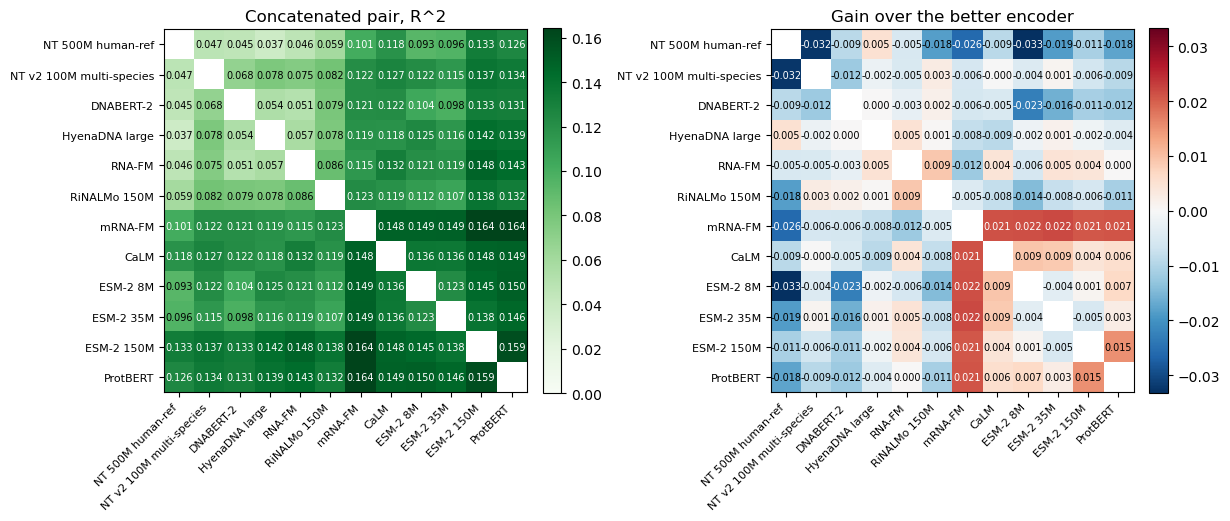

In [21]:
single_r2 = {k: stability_probes.loc[LABELS[k], "Stability R2"] for k in ENCODER_KEYS}

pair_concat, pair_gain = analysis.pairwise_concatenation_scores(
    EMBEDDINGS, ENCODER_KEYS, labels, single_r2, groups=kept_seqs,
)
analysis.plot_matrices(
    {"Concatenated pair, R^2": pair_concat, "Gain over the better encoder": pair_gain},
    LABELS,
    diverging={"Gain over the better encoder"},
    fmt="{:.3f}",
)

**Check across fold assignments.** The pairwise gains above come from the pinned folds alone. The calculation below repeats every pairwise comparison over the `N_FOLD_ASSIGNMENTS` further fold assignments. For each assignment, the gain is the concatenation's five-fold mean minus the better single encoder's five-fold mean on the same folds. The table reports the mean, minimum, and maximum gain and the number of assignments with a positive gain, sorted by mean gain. Every pair is included, so no pair is selected on its pinned result. `analysis.pairwise_assignment_gains` returns the per-assignment gain arrays; the notebook labels and summarizes them below.


In [ ]:
show_source(analysis.pairwise_assignment_gains, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.pairwise_assignment_gains` (line 161)](mbf/analysis.py#L161)

In [22]:
pair_assignment_gains = analysis.pairwise_assignment_gains(
    EMBEDDINGS, ENCODER_KEYS, labels, kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS,
)

gain_rows = []
for a, b in PAIRS:
    gain = pair_assignment_gains[a, b]
    gain_rows.append({
        "pair": f"{LABELS[a]} + {LABELS[b]}",
        "comparison": f"within {MODALITY[a]}" if MODALITY[a] == MODALITY[b] else "across modalities",
        "pinned gain": pair_gain.loc[a, b],
        "mean gain": gain.mean(),
        "min gain": gain.min(),
        "max gain": gain.max(),
        "assignments with a gain": int((gain > 0).sum()),
    })

pair_gains = pd.DataFrame(gain_rows).set_index("pair").sort_values("mean gain", ascending=False)
pair_gains.round(3)

,comparison,pinned gain,mean gain,min gain,max gain,assignments with a gain
pair,,,,,,
mRNA-FM + ESM-2 35M,across modalities,0.022,0.022,0.014,0.031,10
mRNA-FM + ESM-2 150M,across modalities,0.021,0.015,0.007,0.025,10
mRNA-FM + ProtBERT,across modalities,0.021,0.014,0.003,0.025,10
mRNA-FM + ESM-2 8M,across modalities,0.022,0.012,0.004,0.023,10
CaLM + ESM-2 35M,across modalities,0.009,0.012,0.006,0.019,10
...,...,...,...,...,...,...
RNA-FM + ESM-2 8M,across modalities,-0.006,-0.008,-0.020,0.002,1
RiNALMo 150M + ESM-2 8M,across modalities,-0.014,-0.012,-0.019,-0.000,0
DNABERT-2 + ESM-2 8M,across modalities,-0.023,-0.015,-0.022,-0.009,0


In [23]:
group_sets = {
    f"All {m} encoders": [k for k in ENCODER_KEYS if MODALITY[k] == m] for m in ("DNA", "RNA", "protein")
}
group_sets["One per modality: " + ", ".join(LABELS[k] for k in REFERENCE_KEYS)] = REFERENCE_KEYS
group_sets["All encoders"] = ENCODER_KEYS
group_sets = {name: keys for name, keys in group_sets.items() if len(keys) > 1}

group_probes = analysis.probe_table(
    {name: analysis.concatenate_embeddings(EMBEDDINGS, keys) for name, keys in group_sets.items()},
    {"Stability": labels},
    groups=kept_seqs,
    n_assignments=N_FOLD_ASSIGNMENTS,
)
group_probes["best member alone"] = [max(single_r2[k] for k in keys) for keys in group_sets.values()]
group_probes["difference"] = group_probes["Stability R2"] - group_probes["best member alone"]
group_probes.round(3)

,Stability R2,Stability SD,"Stability R2, 10 assignments","Stability SD, 10 assignments",best member alone,difference
encoder,,,,,,
All DNA encoders,0.063,0.036,0.072,0.009,0.080,-0.016
All RNA encoders,0.125,0.059,0.126,0.009,0.127,-0.002
All protein encoders,0.147,0.049,0.146,0.006,0.144,0.004
"One per modality: NT 500M human-ref, RNA-FM, ESM-2 35M",0.109,0.069,0.123,0.005,0.114,-0.005
All encoders,0.132,0.069,0.141,0.005,0.144,-0.012


**Results.** On the pinned folds, the best pairs, mRNA-FM with ESM-2 150M or with ProtBERT, reach $R^2$ 0.164, and 26 of the 66 pairs exceed the better of their two encoders, by at most 0.022. Over the further fold assignments, 16 pairs gain under every assignment:

| Pair | Mean gain | Range of gains |
|---|---:|---:|
| mRNA-FM + ESM-2 35M | $+0.022$ | $+0.014$ to $+0.031$ |
| mRNA-FM + ESM-2 150M | $+0.015$ | $+0.007$ to $+0.025$ |
| mRNA-FM + ProtBERT | $+0.014$ | $+0.003$ to $+0.025$ |
| mRNA-FM + ESM-2 8M | $+0.012$ | $+0.004$ to $+0.023$ |
| CaLM + ESM-2 35M | $+0.012$ | $+0.006$ to $+0.019$ |
| mRNA-FM + CaLM | $+0.011$ | $+0.001$ to $+0.023$ |
| CaLM + ProtBERT | $+0.010$ | $+0.004$ to $+0.017$ |
| NT v2 100M multi-species + RiNALMo 150M | $+0.009$ | $+0.006$ to $+0.012$ |
| CaLM + ESM-2 8M | $+0.009$ | $+0.001$ to $+0.012$ |
| CaLM + ESM-2 150M | $+0.008$ | $+0.001$ to $+0.013$ |
| NT 500M human-ref + DNABERT-2 | $+0.008$ | $+0.001$ to $+0.022$ |
| HyenaDNA large + RNA-FM | $+0.007$ | $+0.003$ to $+0.012$ |
| ESM-2 35M + ProtBERT | $+0.007$ | $+0.001$ to $+0.012$ |
| NT 500M human-ref + HyenaDNA large | $+0.007$ | $+0.002$ to $+0.012$ |
| ESM-2 8M + ProtBERT | $+0.007$ | $+0.000$ to $+0.012$ |
| HyenaDNA large + RiNALMo 150M | $+0.003$ | $+0.001$ to $+0.007$ |

The other 50 pairs have mean gains from $-0.015$ to $+0.009$ and lose under at least one assignment.

Larger concatenations:

| Combination | $R^2$, pinned (fold SD) | $R^2$, further assignments | Best member alone, pinned | Difference, pinned |
|---|---:|---:|---:|---:|
| All DNA encoders | 0.063 (0.036) | 0.072 | 0.080 | $-0.016$ |
| All RNA encoders | 0.125 (0.059) | 0.126 | 0.127 | $-0.002$ |
| All protein encoders | 0.147 (0.049) | 0.146 | 0.144 | $+0.004$ |
| One per modality (NT 500M human-ref, RNA-FM, ESM-2 35M) | 0.109 (0.069) | 0.123 | 0.114 | $-0.005$ |
| All encoders | 0.132 (0.069) | 0.141 | 0.144 | $-0.012$ |

**Interpretation.** Pairing a codon-level RNA encoder with a protein encoder gives the most consistent gains: all eight such pairs improve on the better encoder under every fold assignment, by about 0.012 to 0.022 for mRNA-FM and 0.008 to 0.012 for CaLM. The codon-level encoders read synonymous codon choice, which the protein encoders cannot see, while the protein encoders bring representations learned from protein sequence variation, so the two may carry complementary signal; this probe shows the gain but does not identify its source. mRNA-FM and CaLM also gain together, so the two codon-level encoders are not redundant with each other. The other consistent gains are smaller, at most 0.009 on average: some pairs within DNA or within protein, and some DNA encoders with a single-nucleotide RNA encoder.

Larger concatenations barely help. Each adds hundreds to thousands of columns for 981 rows, and the ridge probe cannot use most of them: all four protein encoders together exceed ESM-2 150M by 0.004 on the pinned folds, and every other group falls below its best member, including all twelve encoders together. Standardizing every feature before the ridge penalty also gives a wider encoder more total weight in a combined probe.

These results are concatenation baselines. They do not rule out complementarity that a nonlinear or position-aware fusion model could exploit, and they do not show that such a model would help. The codon-level and protein pairings are the clearest candidates for that test.

#### Final-layer representation similarity: linear CKA

Linear centered kernel alignment (CKA) compares how two final-layer mean-pooled representations organize the same retained examples. Each pair in `PAIRS` supplies separate matrices `X` of shape `(n, p)` and `Y` of shape `(n, q)`: corresponding rows must identify the same example, but feature widths may differ. `Y` is another representation, not the probe target `y`.

This descriptive comparison fits no cross-modal projection or predictor and uses no stability labels. Pairs within one modality provide a reference for pairs across modalities. See the [CKA walkthrough](../docs/methods/representation-comparison.md#final-layer-representation-similarity-linear-cka) for centering, matrix operations, and the worked norm example.

##### Linear centered kernel alignment

After subtracting each feature's mean across examples, `analysis.linear_cka` computes:

$$
\operatorname{CKA}(X,Y)
=\frac{\|Y_c^\top X_c\|_F^2}
{\|X_c^\top X_c\|_F\,\|Y_c^\top Y_c\|_F}.
$$

**In this notation:**

- $n$ counts matched rows; $p$ and $q$ are the two feature widths.
- $X_c$ and $Y_c$ are the centered matrices, with shapes $(n,p)$ and $(n,q)$. Centering does not divide by feature standard deviations.
- $\top$ transposes a matrix; juxtaposition denotes matrix multiplication. The cross-product has shape $(q,p)$ and the two within-representation products have shapes $(p,p)$ and $(q,q)$.
- $\|A\|_F$ is the Frobenius norm: the square root of the sum of squared entries of matrix $A$. The numerator squares this norm; the denominator multiplies two unsquared norms.

**Interpretation.** CKA describes agreement in relationships among examples. For nonzero centered representations it lies between zero and one in exact arithmetic. Orthogonal transformations and uniform nonzero scaling leave it unchanged; arbitrary changes of basis or separate feature rescaling can change it. See [Kornblith et al. (2019), Section 3 and Table 1](https://proceedings.mlr.press/v97/kornblith19a/kornblith19a.pdf). High CKA alone establishes neither target prediction nor benefit from combining representations.

**Connection to the code.** `linear_cka` directly centers, multiplies, and normalizes these arrays. If either centered matrix is entirely zero, its denominator is zero; the helper has no special handling for that undefined case.


In [ ]:
show_source(analysis.linear_cka, analysis.pairwise_matrix, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.linear_cka` (line 222)](mbf/analysis.py#L222), [`analysis.pairwise_matrix` (line 333)](mbf/analysis.py#L333)

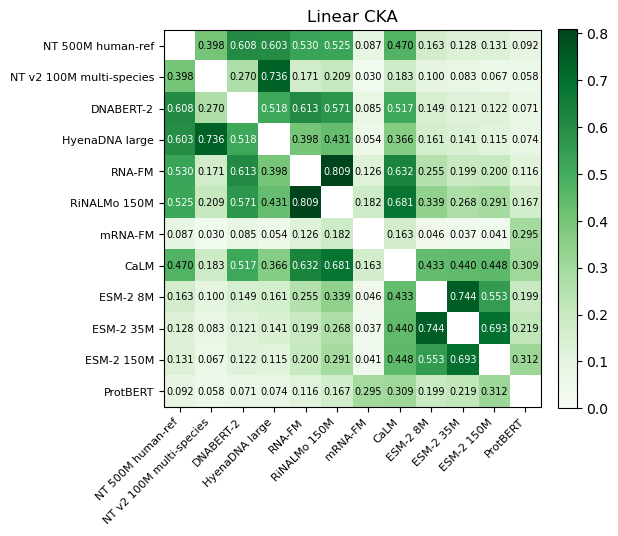

In [25]:
similarity = {
    "Linear CKA": analysis.pairwise_matrix(
        ENCODER_KEYS, lambda a, b: analysis.linear_cka(EMBEDDINGS[a], EMBEDDINGS[b])
    ),
}
analysis.plot_matrices({"Linear CKA": similarity["Linear CKA"]}, LABELS, fmt="{:.3f}")

**Results.** Linear CKA ranges from 0.030 to 0.809 across the 66 pairs:

| Group of pairs | Pairs | Linear CKA |
|---|---:|---:|
| Within ESM-2 | 3 | 0.553 to 0.744 |
| ProtBERT with ESM-2 | 3 | 0.199 to 0.312 |
| Within DNA | 6 | 0.270 to 0.736 |
| RNA-FM with RiNALMo | 1 | 0.809 |
| mRNA-FM with CaLM | 1 | 0.163 |
| DNA with RNA-FM or RiNALMo | 8 | 0.171 to 0.613 |
| DNA with mRNA-FM | 4 | 0.030 to 0.087 |
| DNA with CaLM | 4 | 0.183 to 0.517 |
| DNA with protein | 16 | 0.058 to 0.163 |
| RNA-FM or RiNALMo with mRNA-FM | 2 | 0.126 to 0.182 |
| RNA-FM or RiNALMo with CaLM | 2 | 0.632 to 0.681 |
| RNA-FM or RiNALMo with protein | 8 | 0.116 to 0.339 |
| mRNA-FM with protein | 4 | 0.037 to 0.295 |
| CaLM with protein | 4 | 0.309 to 0.448 |

**Interpretation.** Agreement follows tokenization and training more than the modality label. The two RNA encoders that read single nucleotides agree most of any pair (0.809), followed by the three ESM-2 models (0.553 to 0.744) and by Nucleotide Transformer v2 with HyenaDNA (0.736). Encoders that read single letters or short tokens of the same sequence organize it similarly whether they are called DNA or RNA encoders: Nucleotide Transformer 500M, DNABERT-2, and HyenaDNA agree with RNA-FM and RiNALMo at 0.398 to 0.613. The two Nucleotide Transformer models agree only moderately (0.398) despite sharing a tokenizer, so pretraining corpus and model version also shape the geometry.

The two codon-level encoders differ sharply. CaLM agrees with the single-nucleotide RNA encoders (0.632 and 0.681), with DNABERT-2 and Nucleotide Transformer 500M (0.517 and 0.470), and with every protein encoder (0.309 to 0.448). mRNA-FM agrees with almost nothing: at most 0.182 with any encoder except ProtBERT (0.295), and 0.163 with CaLM. Reading codons is therefore not what isolates mRNA-FM's geometry. ProtBERT agrees with the ESM-2 models (0.199 to 0.312) much less than they agree with each other, as expected for a different model family.

CKA is a descriptive similarity on a zero-to-one scale, not a percentage of shared information or a significance result, and low CKA does not establish that two representations hold distinct useful information.

#### Layerwise representation similarity: linear CKA

This analysis asks how similarity changes with encoder depth. It samples up to `LAYERWISE_N_ROWS = 200` rows, using `SEED`, from the main pre-filter sample, then applies `datasets.retain`. The limit is before filtering; the printed count identifies the actual retained sample.

`embeddings.embed_all_layers` obtains each encoder's returned hidden states and mean-pools each over tokens, including special tokens and using the configured token limits. DNABERT-2's states are captured with forward hooks. `embeddings.embed_layers` stacks one matrix per state, preserving the same retained row order across encoders. See the [state-extraction walkthrough](../docs/methods/representation-comparison.md#layerwise-representation-similarity-linear-cka).

For each encoder pair, the comparison is:

$$
C_{ij}=\operatorname{CKA}\!\left(X^{(i)},Y^{(j)}\right).
$$

**In this notation:**

- $n$ is the number of rows retained for this subsample; it may differ from the main analysis.
- $X^{(i)}$ and $Y^{(j)}$ are the first and second encoders' matrices at returned-state indices $i$ and $j$, with shapes $(n,p)$ and $(n,q)$. Parenthesized superscripts select states, not powers.
- $i$ and $j$ use the Python state indices in `layer_matrices[a][i]` and `layer_matrices[b][j]`.
- $C_{ij}$ is one scalar from [linear CKA](#Linear-centered-kernel-alignment); the complete matrix has one row per state of the first encoder and one column per state of the second.

**Interpretation.** A tile compares two whole representation matrices across matched examples, not individual example rows. State 0 denotes the embedding output before the encoder layers; later indices denote successive layer outputs. For a transformer with $L$ blocks this gives $L+1$ states; HyenaDNA uses a different layer architecture. These are descriptive comparisons, not fitted projections or evidence that a selected pair of layers improves prediction.

**Connection to the code.** `analysis.layerwise_cka` calls `linear_cka` for every state pair. `layerwise_summary` reports the maximum and the final-state value, `matrix[-1, -1]`. It also searches `matrix[:, 1:]`: this excludes state 0 of only the second encoder, retaining every state of the first. The reported column index is adjusted back to the original numbering.

The table summarizes all 66 pairs of the twelve encoders; the following heatmaps show `LAYERWISE_PLOT_PAIRS`. The [guide](../docs/methods/representation-comparison.md#layerwise-representation-similarity-linear-cka) preserves the indexing example and output-convention reference.


In [ ]:
show_source(embeddings.embed_all_layers, embeddings.embed_layers, analysis.layerwise_cka, analysis.layerwise_summary, full=SHOW_IMPLEMENTATION)


Implementation: [`embeddings.embed_all_layers` (line 76)](mbf/embeddings.py#L76), [`embeddings.embed_layers` (line 124)](mbf/embeddings.py#L124), [`analysis.layerwise_cka` (line 287)](mbf/analysis.py#L287), [`analysis.layerwise_summary` (line 296)](mbf/analysis.py#L296)

In [27]:
sampled_rows = datasets.sample_rows(DATASET, N_ROWS, SEED)
layer_dataset = datasets.retain(
    dataset.spec, sampled_rows.sample(n=min(LAYERWISE_N_ROWS, len(sampled_rows)), random_state=SEED)
)
print(
    f"Layer-wise subsample: {len(layer_dataset.sequences)} of {layer_dataset.n_sampled} "
    "sampled rows pass the filters."
)

layer_matrices = {}
for encoder in ENCODERS:
    layer_matrices[encoder.key] = embeddings.embed_layers(encoder, layer_dataset.sequences, DEVICE)
    print(f"{encoder.label}: {len(layer_matrices[encoder.key])} hidden states")

layer_cka = {(a, b): analysis.layerwise_cka(layer_matrices[a], layer_matrices[b]) for a, b in PAIRS}
layerwise_table = pd.DataFrame(
    [{"pair": f"{LABELS[a]} / {LABELS[b]}", **analysis.layerwise_summary(m)} for (a, b), m in layer_cka.items()]
).set_index("pair")
layerwise_table.round(3)

Layer-wise subsample: 194 of 200 sampled rows pass the filters.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NT 500M human-ref: 25 hidden states
NT v2 100M multi-species: 23 hidden states


/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 569
  warnings.warn(
/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:433: UserWarning: Increasing alibi size from 569 to 594
  warnings.warn(


...

ESM-2 150M: 31 hidden states


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ProtBERT: 31 hidden states


,maximum,at states,maximum without second state 0,at states (without),final states
pair,,,,,
NT 500M human-ref / NT v2 100M multi-species,0.834,"0, 13",0.834,"0, 13",0.427
NT 500M human-ref / DNABERT-2,0.884,"0, 1",0.884,"0, 1",0.676
NT 500M human-ref / HyenaDNA large,0.818,"0, 9",0.818,"0, 9",0.616
NT 500M human-ref / RNA-FM,0.764,"14, 1",0.764,"14, 1",0.596
NT 500M human-ref / RiNALMo 150M,0.755,"15, 9",0.755,"15, 9",0.585
...,...,...,...,...,...
ESM-2 8M / ESM-2 150M,0.982,"0, 0",0.903,"1, 2",0.590
ESM-2 8M / ProtBERT,0.771,"1, 2",0.771,"1, 2",0.222
ESM-2 35M / ESM-2 150M,0.994,"0, 0",0.930,"1, 2",0.712


**Read the full matrices.** Each heatmap shows one encoder pair in `LAYERWISE_PLOT_PAIRS`. Each tile shows one $C_{ij}$ value: the vertical axis selects the first encoder's hidden-state index, and the horizontal axis selects the second encoder's. The color bar gives the CKA score, and the panels share one color scale so their values can be compared. Inspecting a whole matrix shows whether elevated similarity is concentrated in a few pairs or spread across several depths; a single maximum cannot describe that pattern on its own. The second figure draws `LAYERWISE_CODON_PAIRS`: the two codon-level encoders against each other and each against ESM-2 35M, which shows whether codon tokens give an early correspondence with protein layers in more than one encoder family.

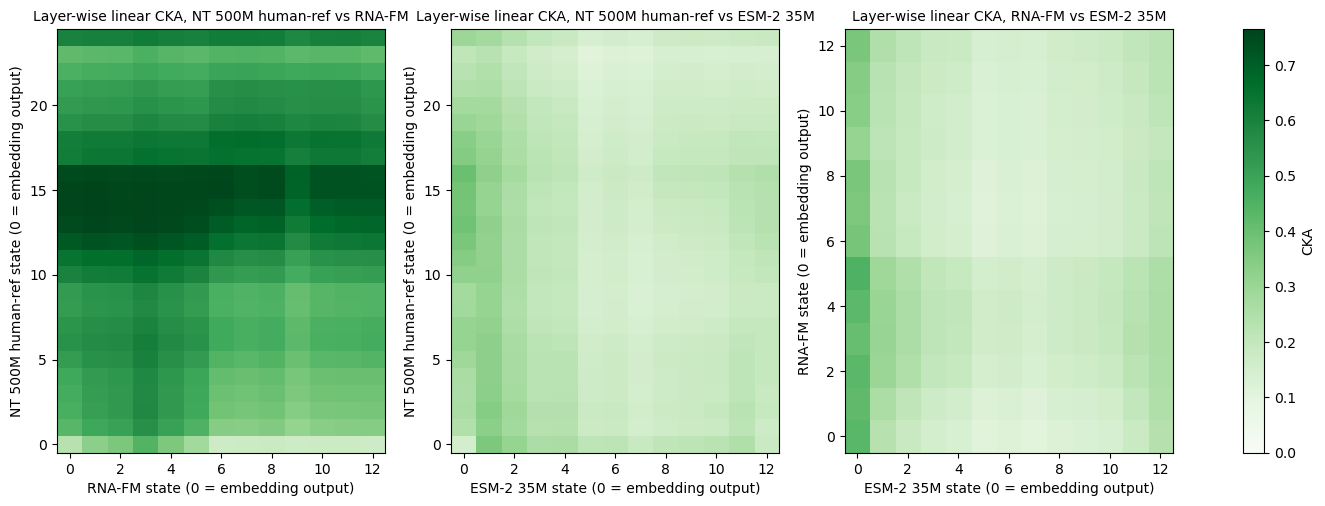

In [28]:
analysis.plot_layerwise({pair: layer_cka[pair] for pair in LAYERWISE_PLOT_PAIRS}, LABELS)

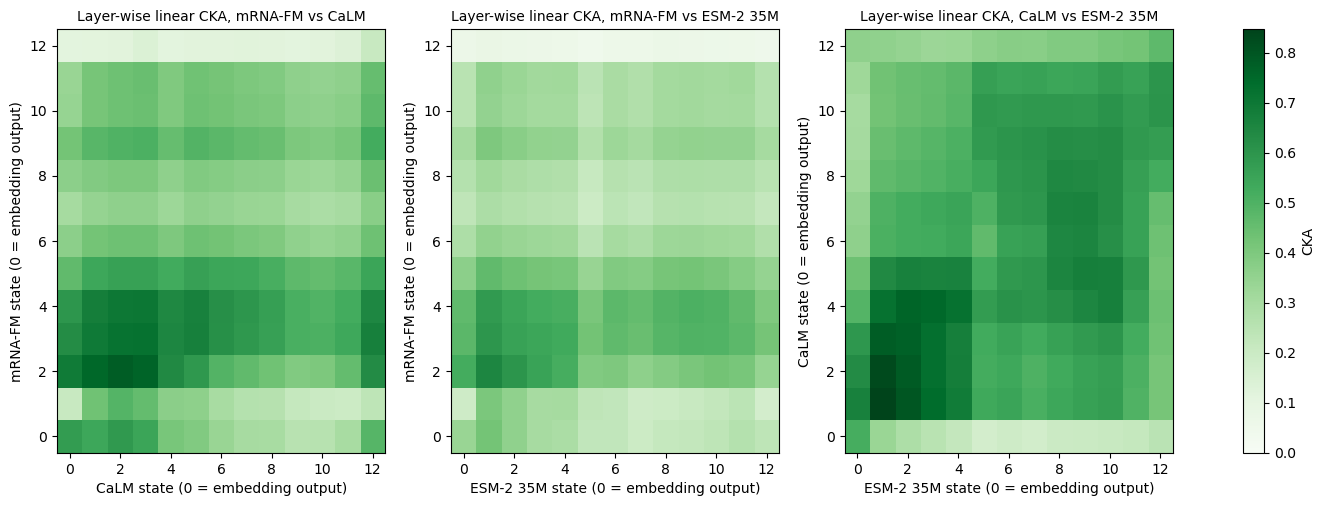

In [29]:
analysis.plot_layerwise({pair: layer_cka[pair] for pair in LAYERWISE_CODON_PAIRS}, LABELS)

**Results.** The layer-wise subsample keeps 194 of the 200 sampled rows. For the six pairs drawn above:

| Pair | Maximum CKA (states) | Maximum without the second encoder's state 0 (states) | Final-state CKA in this subsample |
|---|---|---|---:|
| NT 500M human-ref / RNA-FM | 0.764 (14, 1) | 0.764 (14, 1) | 0.596 |
| NT 500M human-ref / ESM-2 35M | 0.400 (16, 0) | 0.359 (0, 1) | 0.187 |
| RNA-FM / ESM-2 35M | 0.451 (5, 0) | 0.306 (3, 1) | 0.225 |
| mRNA-FM / CaLM | 0.780 (2, 2) | 0.780 (2, 2) | 0.207 |
| mRNA-FM / ESM-2 35M | 0.650 (2, 1) | 0.650 (2, 1) | 0.052 |
| CaLM / ESM-2 35M | 0.847 (1, 1) | 0.847 (1, 1) | 0.469 |

Across all 66 pairs in the table, the maximum involves state 0, 1, or 2 of at least one encoder in 58 pairs. The other eight peak deeper: Nucleotide Transformer 500M with RiNALMo, Nucleotide Transformer v2 with HyenaDNA, RNA-FM, and RiNALMo, ProtBERT with RNA-FM, RiNALMo, and CaLM, and ESM-2 150M with ProtBERT.

- **Codon-level encoders with protein.** CaLM peaks at 0.847 to 0.874 with the ESM-2 models, at CaLM state 1 and ESM-2 state 1 or 2, and keeps 0.469 to 0.480 at the final states, the highest final-state agreement of any nucleotide-protein pair. mRNA-FM peaks at 0.650 to 0.689 with the ESM-2 models, at mRNA-FM state 2, while its final states agree with them at only 0.052 to 0.068.
- **mRNA-FM's final state.** Against every state of every other encoder, mRNA-FM's final state reaches at most 0.362 (ProtBERT), and at most 0.244 for the other encoders; its states 2 to 5 reach 0.650 to 0.780 with every other encoder.
- **ProtBERT's early states.** ProtBERT's state 0 agrees with Nucleotide Transformer 500M, Nucleotide Transformer v2, DNABERT-2, HyenaDNA, and mRNA-FM at 0.875 to 0.944, but with RNA-FM and RiNALMo at most 0.481 at any states.
- **Within a family.** The three ESM-2 models agree almost perfectly at state 0 (0.982 to 0.994) and at 0.590 to 0.815 at their final states; RNA-FM and RiNALMo agree at 0.989 at state 0 and 0.834 at their final states.

**Interpretation.** The heatmap for Nucleotide Transformer 500M and RNA-FM shows a dark horizontal band at Nucleotide Transformer states of about 12 to 16 that spans every RNA-FM state. Agreement between these two encoders is therefore set mainly by the DNA encoder's depth: its middle layers resemble RNA-FM best, whatever RNA-FM state is chosen. Both reference pairs involving ESM-2 35M peak in its first columns, at state 0, the embedding output before any transformer block, and deeper ESM-2 layers agree only weakly with either nucleotide encoder.

The codon heatmaps show why the two codon-level encoders differ at the final layer. In both mRNA-FM panels, the top row, mRNA-FM's final state, is pale across every column, while its states 2 to 5 agree strongly with CaLM and with ESM-2 35M. mRNA-FM's isolated final-layer geometry, seen in every Track B metric, therefore arises in its last transformer blocks; its middle layers carry a codon-to-amino-acid correspondence much like CaLM's. CaLM's middle and deeper states keep agreeing with ESM-2 35M's deeper states, which fits its correspondence with the protein encoders after the [composition control](#Composition-control).

Across all pairs, the highest agreement sits mostly in early states, which have mixed little context between tokens and are close to summaries of token composition. ProtBERT's high early agreement with every nucleotide encoder that reads the full sequence, but not with the two that read only the first 1,022 nucleotides, is consistent with sequence length: ProtBERT adds a learned position embedding to every token, so its pooled early states vary with length, and truncation caps the length that RNA-FM and RiNALMo see. That explanation is consistent with the pattern but not tested here.

The final-state entries come from the 194 retained rows of this subsample and are higher than the full-sample values in [Final-layer representation similarity](#Final-layer-representation-similarity:-linear-CKA) for 63 of the 66 pairs, by up to 0.079; for example 0.596 against 0.530 for Nucleotide Transformer 500M and RNA-FM. Linear CKA tends to be inflated when the number of examples is small relative to the embedding widths. Layer-wise values should be compared within this analysis, not with the full-sample values.

#### Neighborhood overlap across representations

Neighborhood overlap asks whether the same examples are nearest to a query in two representation spaces. Each encoder pair supplies matrices `X` of shape `(n, p)` and `Y` of shape `(n, q)` with matched rows. Neighbor identities refer to those rows, not corresponding feature coordinates. This comparison fits no cross-modal transformation or predictor and uses no stability labels.

First measure each query's shared-neighbor fraction:

$$
o_i=\frac{|N_X(i)\cap N_Y(i)|}{k}.
$$

**In this notation:**

- $n$ counts matched examples; $p$ and $q$ are their feature widths. $i$ selects a query row, from 1 through $n$ here and 0 through `n - 1` in Python.
- $N_X(i)$ and $N_Y(i)$ are the sets of retained neighbor-row indices in the two spaces.
- $\cap$ selects their intersection and $|\cdot|$ counts its members. $k=10$ here; the helper requires $1\le k\le n-1$.
- $o_i$ is the fraction of the $k$ retained neighbors shared by query $i$, between zero and one.

The final score averages these fractions:

$$
\operatorname{overlap@}k=\frac{1}{n}\sum_{i=1}^{n}o_i.
$$

**In this notation:**

- $\sum_{i=1}^{n}$ adds the query fractions; division by $n$ gives their mean.
- $\operatorname{overlap@}k$ names that scalar mean, read as “overlap at k.”

**Interpretation.** Larger values indicate greater agreement about local neighbors. Despite the helper's name, `mutual_knn_alignment` measures overlap between neighbor sets; it does not test reciprocal neighbor relationships. The [neighborhood walkthrough](../docs/methods/representation-comparison.md#neighborhood-overlap-across-representations) supplies the worked example and library reference.

**Connection to the code and limitation.** `NearestNeighbors` uses its default Euclidean distance. The helper requests $k+1$ neighbors and discards the first returned index, intending to exclude the query itself. With duplicate vectors or distance ties, that first index need not be the query; the formula describes the sets actually retained, not guaranteed nonself sets.

The printed chance reference, $k/(n-1)$, assumes two independent, uniformly selected sets of $k$ nonself neighbors. It is an idealized expectation, not a simulated embedding baseline or significance test. Disagreement with CKA alone does not invalidate either metric.


In [ ]:
show_source(analysis.mutual_knn_alignment, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.mutual_knn_alignment` (line 232)](mbf/analysis.py#L232)

Chance level for k = 10 among 981 rows: about 0.0102


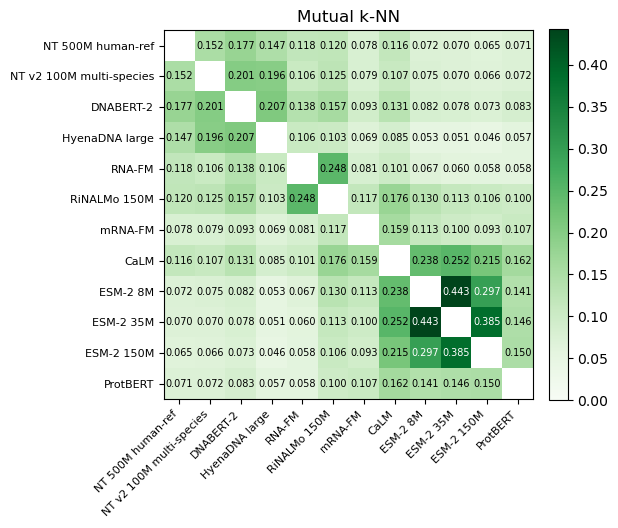

In [31]:
similarity["Mutual k-NN"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.mutual_knn_alignment(EMBEDDINGS[a], EMBEDDINGS[b], k=10)
)
print(f"Chance level for k = 10 among {len(kept_seqs)} rows: about {10 / (len(kept_seqs) - 1):.4f}")
analysis.plot_matrices({"Mutual k-NN": similarity["Mutual k-NN"]}, LABELS, fmt="{:.3f}")

**Results.** Neighborhood overlap with $k=10$ on all 981 rows, where chance is about 0.0102:

| Group of pairs | Mutual $k$-NN |
|---|---:|
| Within ESM-2 | 0.30 to 0.44 |
| ProtBERT with ESM-2 | 0.14 to 0.15 |
| Within DNA | 0.15 to 0.21 |
| RNA-FM with RiNALMo | 0.25 |
| mRNA-FM with CaLM | 0.16 |
| DNA with RNA-FM or RiNALMo | 0.10 to 0.16 |
| DNA with mRNA-FM or CaLM | 0.07 to 0.13 |
| DNA with protein | 0.05 to 0.08 |
| RNA-FM or RiNALMo with mRNA-FM or CaLM | 0.08 to 0.18 |
| RNA-FM or RiNALMo with protein | 0.06 to 0.13 |
| mRNA-FM with protein | 0.09 to 0.11 |
| CaLM with protein | 0.16 to 0.25 |

**Interpretation.** Every pair shares more neighbors than chance, from about 5 times (HyenaDNA with ESM-2 150M) to about 43 times (ESM-2 8M with ESM-2 35M). The ordering largely follows CKA, with two differences. CaLM shares more neighbors with the ESM-2 models (0.22 to 0.25) than with any nucleotide encoder (at most 0.18), and more than ProtBERT shares with the ESM-2 models (0.14 to 0.15). mRNA-FM, whose global geometry agrees least with the protein encoders, shares more local neighborhoods with them (0.09 to 0.11) than the DNA encoders do. Two encoders can therefore agree on which sequences are near each other while their spaces differ overall. Most neighbors still differ between any two encoders, even the ESM-2 models, which share at most 44%.

#### Canonical correlation and cross-modal retrieval

Canonical correlation analysis (CCA) learns linear combinations that vary together across matched rows of two representations. It can expose correspondence in selected directions when whole-matrix similarity is modest. Every pair uses the same aligned training and test rows; stability labels are not used.

**Fit on training rows.** `splits.grouped_holdout_split(kept_seqs, seed=SEED)` assigns about 30% of rows to testing through a hash of each sequence and the seed. Exact duplicate strings stay together; related but nonidentical sequences can cross the boundary. Each representation receives its own training-fitted PCA, requesting up to `min(50, n_train - 1, p, q)` components (50 here), followed by `CCA(n_components=10)`. PCA centers without feature standardization; CCA uses its default input scaling. Test rows are transformed without refitting. The [CCA walkthrough](../docs/methods/representation-comparison.md#canonical-correlation-and-cross-modal-retrieval) retains the fitting details and shape table.

Here `n_train` counts paired training rows, and `p` and `q` are the original embedding widths.

For the first canonical pair, CCA seeks:

$$
(\mathbf a^\star,\mathbf b^\star)
=\underset{\mathbf a,\mathbf b}{\operatorname{arg\,max}}
\operatorname{corr}\!\left(\widetilde X_{\mathrm{train}}\mathbf a,
\widetilde Y_{\mathrm{train}}\mathbf b\right).
$$

**In this notation:**

- $\widetilde X_{\mathrm{train}}$ and $\widetilde Y_{\mathrm{train}}$ are the PCA-reduced, CCA-centered/scaled training matrices, each of shape $(n_{\mathrm{train}},50)$.
- $\mathbf a$ and $\mathbf b$ are 50-entry coefficient vectors. Multiplication produces one canonical coordinate per training row.
- $\operatorname{corr}$ is Pearson correlation across paired rows, requiring nonconstant projections; $\operatorname{arg\,max}$ chooses the coefficients maximizing it. Stars label those chosen coefficients.

**Interpretation.** This describes the first-pair objective delegated to `CCA.fit`, not handwritten optimization. The fitted transformations yield ten coordinates per test row; these numerical combinations do not identify biological mechanisms.

**Retrieve held-out partners.** The first encoder in `ENCODER_KEYS` queries the second by Euclidean distance in those ten coordinates. The tables mirror this one-direction result into both matrix positions. The designated correct partner has the same test-array index:

$$
\operatorname{Recall@}k=\frac{1}{n_{\mathrm{test}}}
\sum_{i=1}^{n_{\mathrm{test}}}\mathbf{1}\{i\in R_k(i)\}.
$$

**In this notation:**

- $n_{\mathrm{test}}$ counts paired test rows; $i$ is a position within their arrays, not an original dataset row number.
- $R_k(i)$ contains the second encoder's first $k$ returned neighbor indices. Reported $k$ values are 1, 5, and 10; the formula assumes $1\le k\le n_{\mathrm{test}}$.
- $\mathbf{1}\{i\in R_k(i)\}$ is 1 when the designated partner is retrieved and 0 otherwise. Summing and dividing counts the fraction of successful queries.

**Interpretation and limits.** Another row with an identical sequence does not count as the designated partner. Ties follow the library's returned ordering. A uniform random ranking gives chance $k/n_{\mathrm{test}}$; this is a ranking reference, not a p-value.

`analysis.cca_retrieval` also correlates corresponding test-coordinate columns. Their correlations need not decrease with component index because component order was learned on training rows. Its returned `test_coords` feed the later [sample-level alignment diagnostic](#Sample-level-alignment-and-prediction-error). See the [guide](../docs/methods/representation-comparison.md#canonical-correlation-and-cross-modal-retrieval) for the worked projections, retrieval example, and library references.


In [ ]:
show_source(splits.grouped_holdout_split, analysis.cca_retrieval, full=SHOW_IMPLEMENTATION)


Implementation: [`splits.grouped_holdout_split` (line 36)](mbf/splits.py#L36), [`analysis.cca_retrieval` (line 241)](mbf/analysis.py#L241)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


690 training rows, 291 test rows; Recall@1 chance 0.0034.


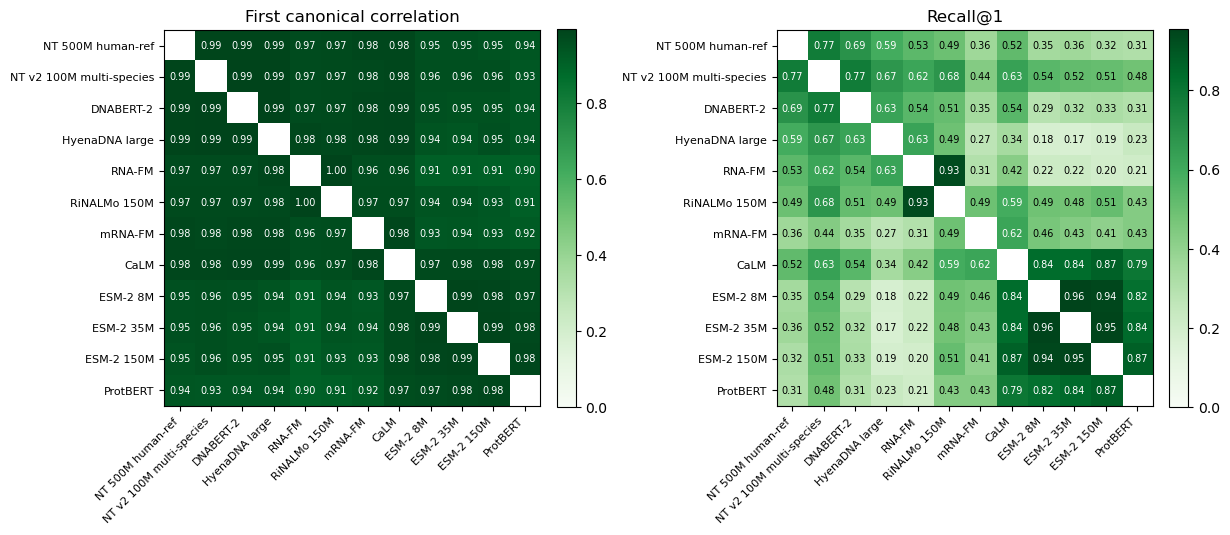

In [33]:
train_idx, test_idx = splits.grouped_holdout_split(kept_seqs, seed=SEED)
cca_results = {
    (a, b): analysis.cca_retrieval(EMBEDDINGS[a], EMBEDDINGS[b], train_idx, test_idx, SEED)
    for a, b in PAIRS
}


def from_cca(extract):
    """Turn a summary of one pair's CCA result into a function of the two encoder keys."""
    return lambda a, b: extract(cca_results[(a, b)])


similarity["First canonical correlation"] = analysis.pairwise_matrix(
    ENCODER_KEYS, from_cca(lambda r: r["correlations"][0])
)
similarity["Mean canonical correlation"] = analysis.pairwise_matrix(
    ENCODER_KEYS, from_cca(lambda r: r["correlations"].mean())
)
for k in (1, 5, 10):
    similarity[f"Recall@{k}"] = analysis.pairwise_matrix(ENCODER_KEYS, from_cca(lambda r, k=k: r["recall"][k]))

print(f"{len(train_idx)} training rows, {len(test_idx)} test rows; Recall@1 chance {1 / len(test_idx):.4f}.")
analysis.plot_matrices({name: similarity[name] for name in ["First canonical correlation", "Recall@1"]}, LABELS)

**Results.** CCA fitted on 690 rows and evaluated on 291 held-out rows, with every copy of a sequence on one side; Recall@1 chance is 0.0034:

| Group of pairs | First canonical correlation | Recall@1 |
|---|---:|---:|
| Within ESM-2 | 0.984 to 0.990 | 0.942 to 0.955 |
| ProtBERT with ESM-2 | 0.969 to 0.981 | 0.818 to 0.873 |
| Within DNA | 0.989 to 0.994 | 0.591 to 0.773 |
| RNA-FM with RiNALMo | 0.995 | 0.931 |
| mRNA-FM with CaLM | 0.983 | 0.619 |
| DNA with RNA-FM or RiNALMo | 0.971 to 0.983 | 0.491 to 0.677 |
| DNA with mRNA-FM | 0.979 to 0.983 | 0.271 to 0.436 |
| DNA with CaLM | 0.983 to 0.985 | 0.340 to 0.632 |
| DNA with protein | 0.935 to 0.959 | 0.168 to 0.540 |
| RNA-FM or RiNALMo with mRNA-FM or CaLM | 0.962 to 0.967 | 0.306 to 0.591 |
| RNA-FM or RiNALMo with protein | 0.902 to 0.944 | 0.196 to 0.509 |
| mRNA-FM with protein | 0.922 to 0.940 | 0.405 to 0.464 |
| CaLM with protein | 0.967 to 0.976 | 0.794 to 0.866 |

The `ConvergenceWarning` lines printed by this cell mean that a few of the 66 fits reached scikit-learn's iteration limit; the values for those pairs come from those fits, whose canonical directions are approximate.

**Interpretation.** After fitting linear projections, every pair shares a strongly correlated low-dimensional subspace: the first canonical direction correlates above 0.90 on held-out rows for all 66 pairs. Retrieval separates the pairs more clearly. The ESM-2 models identify each other's sequences almost perfectly, and so do RNA-FM and RiNALMo (93%). CaLM finds a sequence's protein partner 79% to 87% of the time, as often as ProtBERT finds an ESM-2 model's partner, about 230 to 250 times chance. mRNA-FM does so 41% to 46% of the time, and among the DNA encoders Nucleotide Transformer v2 does best (48% to 54%). RNA-FM, which reads a truncated sequence, finds a protein partner least often of the single-nucleotide encoders (20% to 22%), against 43% to 51% for RiNALMo, which reads the same truncated window.

High retrieval can coexist with modest CKA because CCA selects a few directions that agree and ignores the rest. The [composition control](#Composition-control) below shows how much of this correspondence remains once letter, codon, and amino-acid frequencies are removed. Retrieval measures correspondence between representations, not stability prediction, and does not show that a learned fusion method will help.

#### Composition control

This control asks how much representation agreement remains after subtracting the part predicted linearly by specified composition features. For each retained coding sequence, `composition_features` supplies 87 values: GC, GC3, log nucleotide length, 64 codon frequencies, and 20 translated amino-acid frequencies. The [composition walkthrough](../docs/methods/representation-comparison.md#composition-control) defines them and the fit.

For each encoder, the fitted contribution is subtracted:

$$
X^{\perp}=X-F_s\hat B.
$$

**In this notation:**

- $X$ is the encoder's $(n,d)$ embedding matrix, with matched example rows.
- $F_s$ contains standardized composition features plus an intercept column, giving shape $(n,88)$; $\hat B$ is the least-squares coefficient matrix of shape $(88,d)$.
- $X^{\perp}$ is the residual matrix, with the same shape as $X$.

In the helper, the mathematical $F_s$ is named `design`; the code variable `F_s` holds the 87 standardized features before the intercept is added.

**Interpretation.** The fit removes the sampled embeddings' linear component associated with these features. Nonlinear composition effects and other shared influences can remain; residual agreement alone does not identify a biological mechanism.

`composition_share` reports the in-sample fraction of embedding variance removed:

$$
R^2_{\mathrm{comp}}(X)=1-\frac{\lVert X^{\perp}\rVert_F^2}{\lVert X-\bar X\rVert_F^2}.
$$

**In this notation:**

- $\bar X$ repeats the feature means in every row.
- Each squared Frobenius norm sums the squared entries of its matrix.

This is an in-sample variance ratio, distinct from held-out prediction $R^2$.

The code prints a predictor-count ratio, $88/n$, as a chance reference. That is a heuristic, not a calibrated null: these features have dependencies, and no null distribution is estimated here.

CKA and CCA Recall@1 are repeated on the residuals, using the same retrieval split as before. **Residualization uses all retained rows**, including those later held out for PCA/CCA. Thus the post-control comparison does not hold out rows from every fitted preprocessing step, although it never uses stability labels. See the [retrieval procedure](../docs/methods/representation-comparison.md#canonical-correlation-and-cross-modal-retrieval) for its separate fitting boundary.


In [ ]:
show_source(sequences.composition_features, analysis.residualize, analysis.composition_share, full=SHOW_IMPLEMENTATION)


Implementation: [`sequences.composition_features` (line 58)](mbf/sequences.py#L58), [`analysis.residualize` (line 349)](mbf/analysis.py#L349), [`analysis.composition_share` (line 362)](mbf/analysis.py#L362)

In [35]:
composition = np.array([sequences.composition_features(s) for s in kept_seqs])
RESIDUALS = {k: analysis.residualize(X, composition) for k, X in EMBEDDINGS.items()}

n_predictors = composition.shape[1] + 1  # composition features plus the intercept
print(
    f"Chance level for {n_predictors} predictors on {len(kept_seqs)} rows: "
    f"about {n_predictors / len(kept_seqs):.3f}"
)
pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "share of variance explained by composition": [
         analysis.composition_share(EMBEDDINGS[k], RESIDUALS[k]) for k in ENCODER_KEYS
     ]},
    index=[LABELS[k] for k in ENCODER_KEYS],
).round(3)

Chance level for 88 predictors on 981 rows: about 0.090


,modality,share of variance explained by composition
NT 500M human-ref,DNA,0.618
NT v2 100M multi-species,DNA,0.804
DNABERT-2,DNA,0.610
HyenaDNA large,DNA,0.924
RNA-FM,RNA,0.677
RiNALMo 150M,RNA,0.648
mRNA-FM,RNA,0.296
CaLM,RNA,0.472
ESM-2 8M,protein,0.479
ESM-2 35M,protein,0.446


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


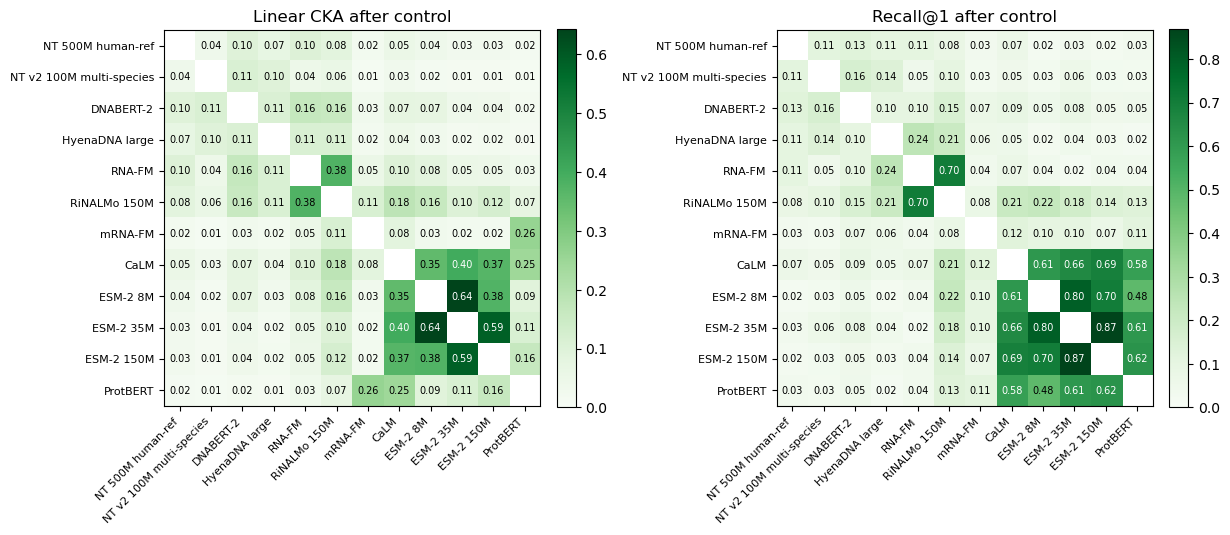

,comparison,CKA before,CKA after,Recall@1 before,Recall@1 after,CKA reduction
pair,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,0.398,0.038,0.773,0.113,0.904
NT 500M human-ref / DNABERT-2,within DNA,0.608,0.097,0.687,0.127,0.840
NT 500M human-ref / HyenaDNA large,within DNA,0.603,0.068,0.591,0.107,0.887
NT 500M human-ref / RNA-FM,across modalities,0.530,0.101,0.533,0.107,0.810
NT 500M human-ref / RiNALMo 150M,across modalities,0.525,0.084,0.495,0.079,0.840
...,...,...,...,...,...,...
ESM-2 8M / ESM-2 150M,within protein,0.553,0.376,0.942,0.701,0.320
ESM-2 8M / ProtBERT,within protein,0.199,0.093,0.818,0.481,0.534
ESM-2 35M / ESM-2 150M,within protein,0.693,0.588,0.948,0.869,0.152


In [36]:
similarity["Linear CKA after control"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.linear_cka(RESIDUALS[a], RESIDUALS[b])
)
similarity["Recall@1 after control"] = analysis.pairwise_matrix(
    ENCODER_KEYS,
    lambda a, b: analysis.cca_retrieval(RESIDUALS[a], RESIDUALS[b], train_idx, test_idx, SEED)["recall"][1],
)
analysis.plot_matrices(
    {name: similarity[name] for name in ["Linear CKA after control", "Recall@1 after control"]}, LABELS
)

composition_control = analysis.pair_table(
    {
        "CKA before": similarity["Linear CKA"],
        "CKA after": similarity["Linear CKA after control"],
        "Recall@1 before": similarity["Recall@1"],
        "Recall@1 after": similarity["Recall@1 after control"],
    },
    PAIRS, LABELS, MODALITY,
)
composition_control["CKA reduction"] = 1 - composition_control["CKA after"] / composition_control["CKA before"]
composition_control.round(3)

**Results.** Share of embedding variance explained by composition, in sample, where 88 unrelated predictors would explain about 0.090:

| Encoder | Modality | $R^2_{\mathrm{comp}}$ |
|---|---|---:|
| NT 500M human-ref | DNA | 0.618 |
| NT v2 100M multi-species | DNA | 0.804 |
| DNABERT-2 | DNA | 0.610 |
| HyenaDNA large | DNA | 0.924 |
| RNA-FM | RNA | 0.677 |
| RiNALMo 150M | RNA | 0.648 |
| mRNA-FM | RNA | 0.296 |
| CaLM | RNA | 0.472 |
| ESM-2 8M | Protein | 0.479 |
| ESM-2 35M | Protein | 0.446 |
| ESM-2 150M | Protein | 0.437 |
| ProtBERT | Protein | 0.415 |

Agreement before and after removing composition, where Recall@1 chance is about 0.0034:

| Group of pairs | CKA before | CKA after | Recall@1 before | Recall@1 after |
|---|---:|---:|---:|---:|
| Within ESM-2 | 0.553 to 0.744 | 0.376 to 0.643 | 0.942 to 0.955 | 0.701 to 0.869 |
| ProtBERT with ESM-2 | 0.199 to 0.312 | 0.093 to 0.162 | 0.818 to 0.873 | 0.481 to 0.622 |
| Within DNA | 0.270 to 0.736 | 0.038 to 0.113 | 0.591 to 0.773 | 0.103 to 0.162 |
| RNA-FM with RiNALMo | 0.809 | 0.378 | 0.931 | 0.704 |
| mRNA-FM with CaLM | 0.163 | 0.084 | 0.619 | 0.124 |
| DNA with RNA-FM or RiNALMo | 0.171 to 0.613 | 0.044 to 0.164 | 0.491 to 0.677 | 0.052 to 0.244 |
| DNA with mRNA-FM | 0.030 to 0.087 | 0.012 to 0.031 | 0.271 to 0.436 | 0.027 to 0.069 |
| DNA with CaLM | 0.183 to 0.517 | 0.029 to 0.075 | 0.340 to 0.632 | 0.048 to 0.086 |
| DNA with protein | 0.058 to 0.163 | 0.010 to 0.072 | 0.168 to 0.540 | 0.021 to 0.082 |
| RNA-FM or RiNALMo with mRNA-FM | 0.126 to 0.182 | 0.055 to 0.114 | 0.306 to 0.491 | 0.041 to 0.076 |
| RNA-FM or RiNALMo with CaLM | 0.632 to 0.681 | 0.101 to 0.183 | 0.423 to 0.591 | 0.069 to 0.210 |
| RNA-FM or RiNALMo with protein | 0.116 to 0.339 | 0.035 to 0.161 | 0.196 to 0.509 | 0.021 to 0.223 |
| mRNA-FM with protein | 0.037 to 0.295 | 0.021 to 0.261 | 0.405 to 0.464 | 0.069 to 0.113 |
| CaLM with protein | 0.309 to 0.448 | 0.246 to 0.401 | 0.794 to 0.866 | 0.581 to 0.687 |

As in the CCA cell, the `ConvergenceWarning` lines mean that a few fits reached scikit-learn's iteration limit.

**Interpretation.** Composition is a large part of most pooled embeddings: letter, codon, and amino-acid frequencies explain 61% to 92% of the variance in the DNA embeddings and in the two single-nucleotide RNA embeddings, and 42% to 48% in the protein embeddings, several times the chance level. HyenaDNA is the most composition-dominated encoder (92%), and the codon-level encoders the least (mRNA-FM 30%, CaLM 47%).

Removing composition removes most of the agreement involving a DNA encoder: CKA falls by 52% to 90% for every such pair, and Recall@1 to at most 0.244. Three groups keep strong agreement. The ESM-2 models still retrieve each other's sequences 70% to 87% of the time, and ProtBERT the ESM-2 models' 48% to 62%. RNA-FM and RiNALMo keep a Recall@1 of 0.704. CaLM and the protein encoders keep the most of any cross-modal pairing: CKA falls by only 9% to 20%, and CaLM still finds its protein partner 58% to 69% of the time, about 170 to 200 times chance. mRNA-FM keeps 7% to 11% with the protein encoders, about 20 to 33 times chance.

These residuals are the part of the agreement that could reflect shared information beyond composition, such as the order of codons and amino acids along the sequence, which frequency features do not describe; nonlinear composition effects are not excluded by this linear control. CaLM's correspondence with the protein encoders after the control is the strongest evidence in Stage 1 that a nucleotide encoder represents something protein-like beyond counts.

For the project's definition of alignment, this means raw similarity between frozen pooled embeddings is a weak target: most agreement involving DNA encoders can be reproduced from counts alone. Comparisons of alignment methods or fusion models should report agreement both before and after a composition control like this one.

#### High- and low-variance directions

This analysis asks whether agreement, composition, and stability signal occur in an encoder's dominant directions or in its remaining directions. `analysis.pca_bands` fits PCA to each full embedding matrix without using labels and splits its coordinates:

$$
X\;\longmapsto\;\big(Z_{\mathrm{top}},Z_{\mathrm{rest}}\big).
$$

**In this notation:**

- $X$ has $n$ example rows and $d$ features.
- $Z_{\mathrm{top}}$ holds coordinates on the first `PCA_TOP_K` components (currently 10).
- $Z_{\mathrm{rest}}$ holds the remaining components, up to $\min(n-1,d)$ components in total. Together the two blocks retain the centered sample's variance.

**Interpretation.** The table reports the top block's variance share, plus the in-sample composition share and stability-probe $R^2$ for both blocks. The heatmaps compare top with top and remaining with remaining across encoder pairs. High variance does not itself establish predictive usefulness.

PCA is fitted on **all rows before the probes are evaluated**, so held-out probe rows help choose the directions even though their labels do not. This is an exploratory decomposition, not fold-local PCA preprocessing. Composition shares retain the [control's in-sample and heuristic-reference limitations](../docs/methods/representation-comparison.md#composition-control). See the [PCA-band walkthrough](../docs/methods/representation-comparison.md#high--and-low-variance-directions) for shapes and how the comparisons connect, and the [probe evaluation](../docs/methods/linear-probing.md#evaluation-and-interpretation) for the score summaries.


In [ ]:
show_source(analysis.pca_bands, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.pca_bands` (line 372)](mbf/analysis.py#L372)

In [38]:
BANDS = {}
band_rows = []
for k in ENCODER_KEYS:
    top, rest, top_share = analysis.pca_bands(EMBEDDINGS[k], k=PCA_TOP_K)
    BANDS[k] = {"top": top, "rest": rest}
    band_rows.append({
        "encoder": LABELS[k],
        "modality": MODALITY[k],
        f"variance share, top {PCA_TOP_K}": top_share,
        "composition share, top": analysis.composition_share(top, analysis.residualize(top, composition)),
        "composition share, rest": analysis.composition_share(rest, analysis.residualize(rest, composition)),
        "stability R2, top": analysis.probe_scores(top, labels, groups=kept_seqs).mean(),
        "stability R2, rest": analysis.probe_scores(rest, labels, groups=kept_seqs).mean(),
        "stability R2, whole": single_r2[k],
    })
pd.DataFrame(band_rows).set_index("encoder").round(3)

,modality,"variance share, top 10","composition share, top","composition share, rest","stability R2, top","stability R2, rest","stability R2, whole"
encoder,,,,,,,
NT 500M human-ref,DNA,0.747,0.742,0.252,0.039,-0.010,0.032
NT v2 100M multi-species,DNA,0.891,0.858,0.356,0.057,-0.010,0.080
DNABERT-2,DNA,0.715,0.764,0.224,0.039,-0.020,0.054
HyenaDNA large,DNA,0.963,0.950,0.236,0.024,-0.009,0.026
RNA-FM,RNA,0.858,0.745,0.265,0.038,-0.008,0.052
RiNALMo 150M,RNA,0.796,0.720,0.364,0.047,-0.008,0.078
mRNA-FM,RNA,0.606,0.369,0.182,0.061,-0.009,0.127
CaLM,RNA,0.548,0.647,0.259,0.066,-0.008,0.127
ESM-2 8M,protein,0.625,0.575,0.319,0.108,-0.010,0.127


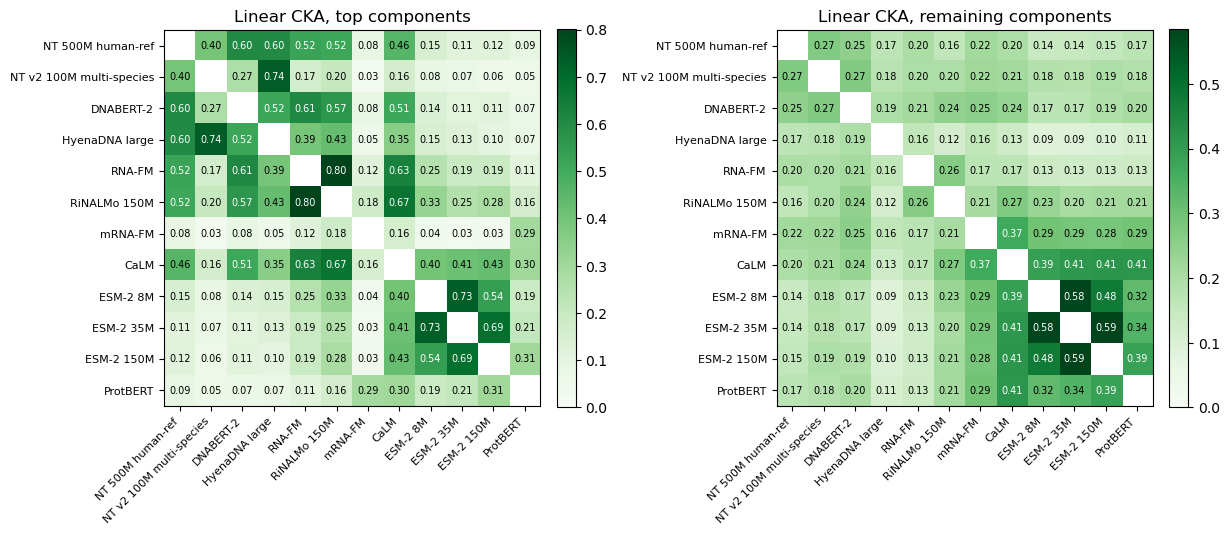

In [39]:
similarity["Linear CKA, top components"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.linear_cka(BANDS[a]["top"], BANDS[b]["top"])
)
similarity["Linear CKA, remaining components"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.linear_cka(BANDS[a]["rest"], BANDS[b]["rest"])
)
analysis.plot_matrices(
    {name: similarity[name] for name in ["Linear CKA, top components", "Linear CKA, remaining components"]},
    LABELS,
)

**Results.**

| Encoder | Variance in top 10 | Composition share, top | Composition share, rest | Stability $R^2$, top | Stability $R^2$, rest | Stability $R^2$, whole |
|---|---:|---:|---:|---:|---:|---:|
| NT 500M human-ref | 0.747 | 0.742 | 0.252 | 0.039 | $-0.010$ | 0.032 |
| NT v2 100M multi-species | 0.891 | 0.858 | 0.356 | 0.057 | $-0.010$ | 0.080 |
| DNABERT-2 | 0.715 | 0.764 | 0.224 | 0.039 | $-0.020$ | 0.054 |
| HyenaDNA large | 0.963 | 0.950 | 0.236 | 0.024 | $-0.009$ | 0.026 |
| RNA-FM | 0.858 | 0.745 | 0.265 | 0.038 | $-0.008$ | 0.052 |
| RiNALMo 150M | 0.796 | 0.720 | 0.364 | 0.047 | $-0.008$ | 0.078 |
| mRNA-FM | 0.606 | 0.369 | 0.182 | 0.061 | $-0.009$ | 0.127 |
| CaLM | 0.548 | 0.647 | 0.259 | 0.066 | $-0.008$ | 0.127 |
| ESM-2 8M | 0.625 | 0.575 | 0.319 | 0.108 | $-0.010$ | 0.127 |
| ESM-2 35M | 0.648 | 0.534 | 0.285 | 0.107 | $-0.009$ | 0.114 |
| ESM-2 150M | 0.698 | 0.500 | 0.292 | 0.095 | $-0.008$ | 0.144 |
| ProtBERT | 0.818 | 0.453 | 0.246 | 0.086 | $-0.009$ | 0.143 |

Linear CKA within each block, by group of pairs:

| Group of pairs | CKA, whole | CKA, top 10 | CKA, rest |
|---|---:|---:|---:|
| Within ESM-2 | 0.553 to 0.744 | 0.541 to 0.735 | 0.478 to 0.585 |
| ProtBERT with ESM-2 | 0.199 to 0.312 | 0.189 to 0.306 | 0.318 to 0.388 |
| Within DNA | 0.270 to 0.736 | 0.267 to 0.736 | 0.166 to 0.270 |
| RNA-FM with RiNALMo | 0.809 | 0.802 | 0.262 |
| mRNA-FM with CaLM | 0.163 | 0.156 | 0.366 |
| DNA with protein | 0.058 to 0.163 | 0.055 to 0.146 | 0.090 to 0.205 |
| RNA-FM or RiNALMo with protein | 0.116 to 0.339 | 0.112 to 0.325 | 0.127 to 0.232 |
| mRNA-FM with protein | 0.037 to 0.295 | 0.028 to 0.292 | 0.285 to 0.294 |
| CaLM with protein | 0.309 to 0.448 | 0.304 to 0.429 | 0.392 to 0.414 |

**Interpretation.** Each embedding's variance is concentrated in a few directions: the top ten components hold 55% (CaLM) to 96% (HyenaDNA) of it, and 63% to 82% for the protein encoders. Composition sits mostly in those directions, explaining 37% to 95% of the top block and 18% to 36% of the rest in every encoder. The stability signal a linear probe can reach also sits there: for ESM-2 8M and 35M, the top ten components alone give 85% and 94% of the whole embedding's $R^2$. The remaining block on its own gives $-0.008$ to $-0.020$, below zero for every encoder. The probe rescales each of its several hundred columns to unit variance, so low-variance noise directions weigh as much as any signal; that the whole embedding still beats the top block for most encoders (for example 0.144 against 0.095 for ESM-2 150M) shows that some signal lies outside the top ten, usable alongside the dominant directions.

Agreement between encoders is carried by the dominant directions as well: CKA on the top block reproduces the whole-embedding CKA within 0.035 for every pair. The low-variance directions agree too. The ESM-2 models keep a CKA of 0.48 to 0.59 between their remaining blocks, and CaLM keeps 0.39 to 0.41 with the protein encoders, so their agreement is not confined to the dominant directions. mRNA-FM is the case where the remaining block agrees more than the top block: 0.29 with every protein encoder and 0.37 with CaLM, against 0.03 to 0.16 on the top block for the ESM-2 models and CaLM. Its correspondence with the protein encoders therefore sits in low-variance directions, which fits its low CKA but substantial CCA retrieval.

The remaining blocks have up to 970 columns for 981 rows, and linear CKA rises with the number of columns relative to rows, so their values should be compared with each other, not with the top-block values; the lowest pairs (about 0.09) show the floor.

#### Summary of Track B metrics for every pair

The table collects the geometry metrics above for each pair of encoders and labels whether the two encoders share a modality. Within-modality pairs are the reference for reading pairs across modalities.

In [40]:
track_b_summary = analysis.pair_table(
    {name: similarity[name] for name in [
        "Linear CKA", "Mutual k-NN", "First canonical correlation", "Mean canonical correlation",
        "Recall@1", "Recall@5", "Recall@10", "Linear CKA after control", "Recall@1 after control",
        "Linear CKA, top components", "Linear CKA, remaining components",
    ]},
    PAIRS, LABELS, MODALITY,
)
track_b_summary.round(3)

,comparison,Linear CKA,Mutual k-NN,First canonical correlation,Mean canonical correlation,Recall@1,Recall@5,Recall@10,Linear CKA after control,Recall@1 after control,"Linear CKA, top components","Linear CKA, remaining components"
pair,,,,,,,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,0.398,0.152,0.989,0.871,0.773,0.969,0.986,0.038,0.113,0.396,0.270
NT 500M human-ref / DNABERT-2,within DNA,0.608,0.177,0.989,0.870,0.687,0.921,0.962,0.097,0.127,0.605,0.248
NT 500M human-ref / HyenaDNA large,within DNA,0.603,0.147,0.990,0.835,0.591,0.890,0.952,0.068,0.107,0.603,0.166
NT 500M human-ref / RNA-FM,across modalities,0.530,0.118,0.971,0.826,0.533,0.818,0.887,0.101,0.107,0.524,0.200
NT 500M human-ref / RiNALMo 150M,across modalities,0.525,0.120,0.973,0.810,0.495,0.808,0.897,0.084,0.079,0.515,0.158
...,...,...,...,...,...,...,...,...,...,...,...,...
ESM-2 8M / ESM-2 150M,within protein,0.553,0.297,0.984,0.957,0.942,0.986,0.997,0.376,0.701,0.541,0.478
ESM-2 8M / ProtBERT,within protein,0.199,0.141,0.969,0.932,0.818,0.983,0.990,0.093,0.481,0.189,0.318
ESM-2 35M / ESM-2 150M,within protein,0.693,0.385,0.989,0.968,0.948,0.993,1.000,0.588,0.869,0.688,0.585


#### Two-dimensional UMAP views

UMAP provides a visual summary of neighborhoods in each final-layer embedding matrix. Each plotted point represents one retained row, and the two coordinates are fitted visualization coordinates. The code fits one projection per encoder; their axes do not form a shared coordinate system, even though their rows correspond. Points are colored by the encoder's modality.

Every projection uses `random_state=SEED`. Fixing the random state supports repeatability of this stochastic projection, while the neighborhood and spacing settings still affect its appearance. See the [UMAP parameter guide](https://umap-learn.readthedocs.io/en/latest/parameters.html) and [reproducibility documentation](https://umap-learn.readthedocs.io/en/latest/reproducibility.html).

Use these plots to suggest examples or groups for further inspection. A two-dimensional layout does not preserve every relationship in the original space, and it does not replace the quantitative comparisons above.

In [ ]:
show_source(analysis.plot_umap, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.plot_umap` (line 651)](mbf/analysis.py#L651)

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

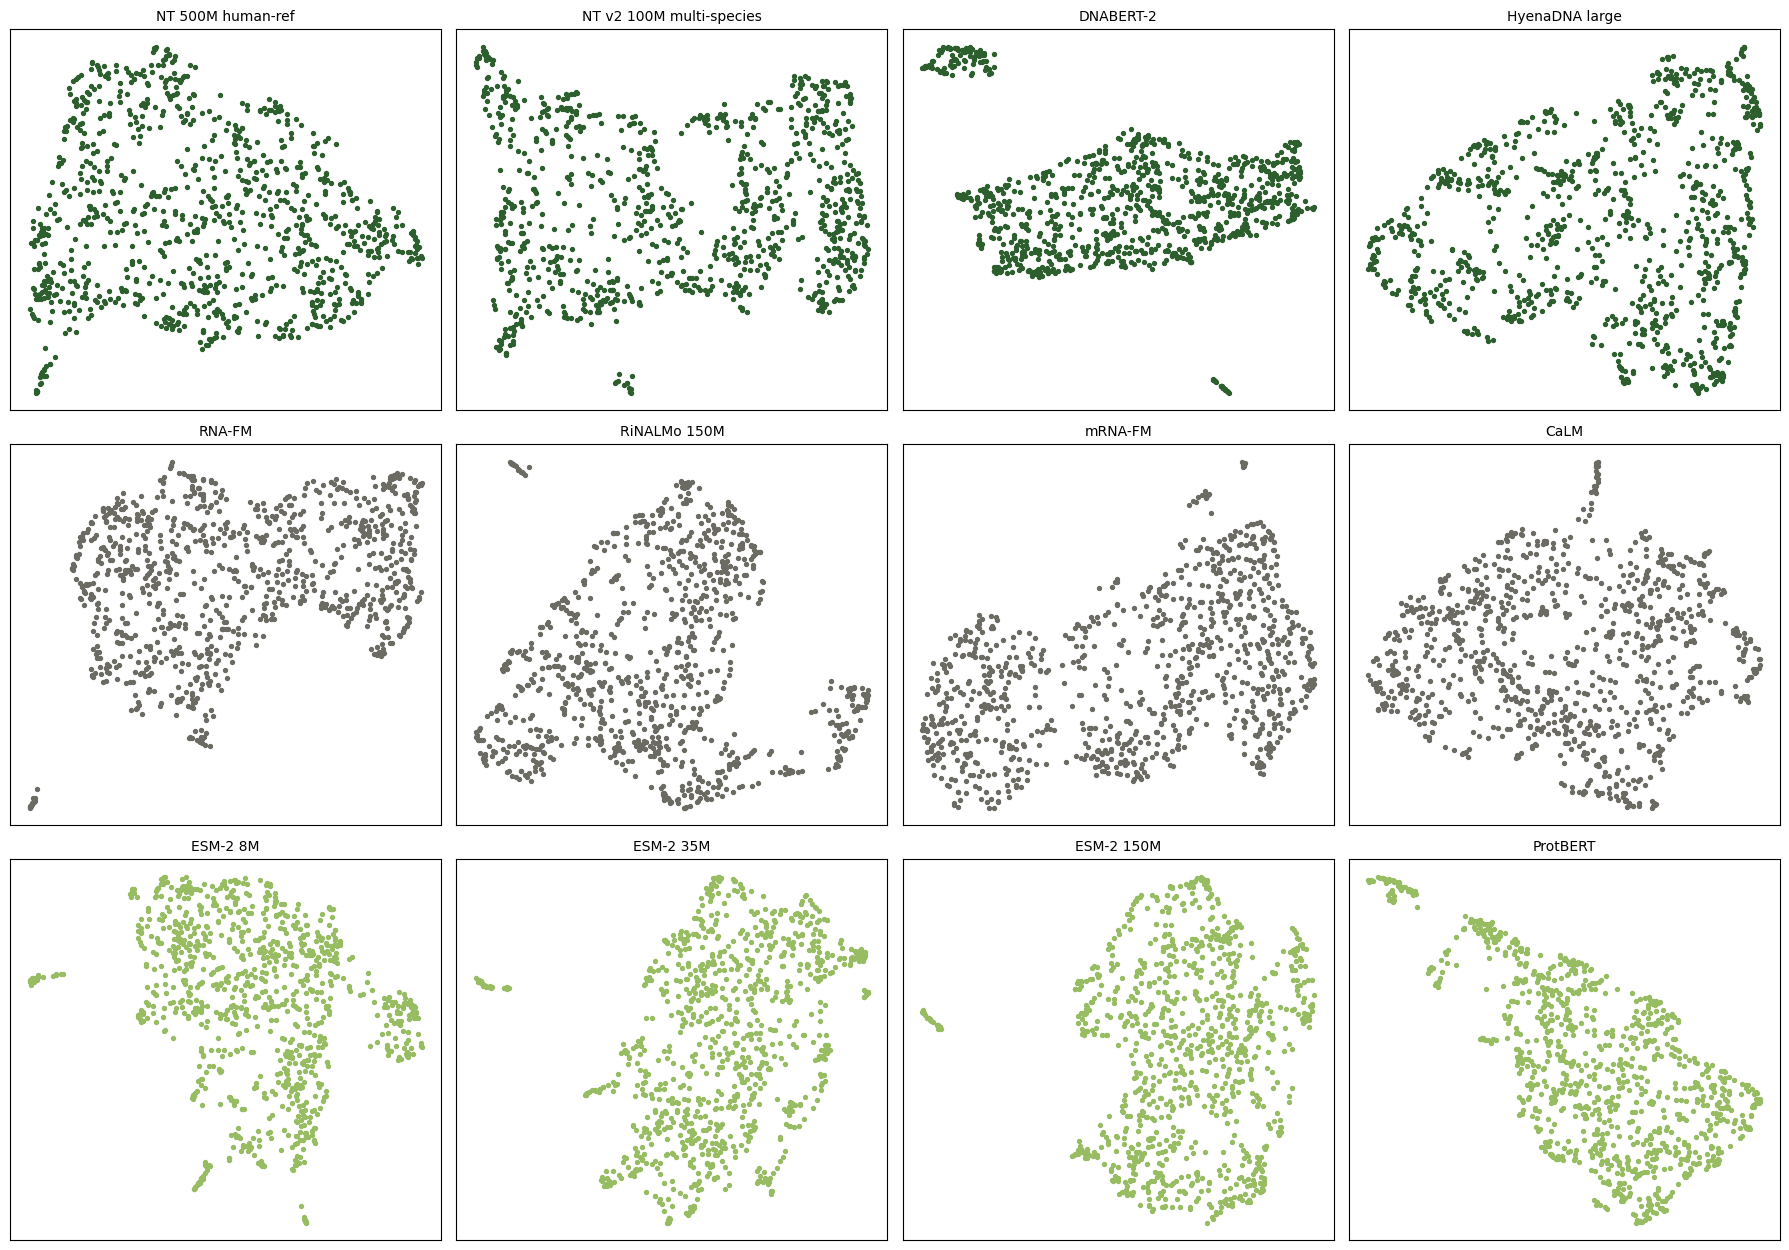

In [42]:
analysis.plot_umap(EMBEDDINGS, LABELS, MODALITY, seed=SEED)

**Reading the plots.** Most layouts show one broad cloud plus one or two small, tightly packed groups separated from it: at the lower left of the Nucleotide Transformer 500M and RNA-FM layouts, below the Nucleotide Transformer v2 layout, at the upper left of the RiNALMo layout, at the left of the three ESM-2 layouts, and at the upper left of the ProtBERT layout. DNABERT-2 separates a larger group at the upper left. HyenaDNA and CaLM show a single loose cloud without a separated group, and mRNA-FM is the only layout whose main cloud divides into two large lobes.

The small separated groups are candidates for sequences that differ systematically from the rest, such as unusual lengths, compositions, or source organisms. Their similar appearance across layouts does not establish that they contain the same rows, because each layout is fitted separately and the plots do not label points. Tracing the grouped points back to their rows, and checking their length, GC content, and source species, would test that; the same check would show what separates mRNA-FM's two lobes. The figures are exploratory and do not establish any biological grouping.

---

### Pipeline control: synonymous recoding

The `mRFP_Expression` control checks the translation/embedding relationship: synonymous recodings change codons while preserving the amino-acid sequence. Identical translated strings give each protein encoder the same input, while distinct nucleotide strings can give the DNA and RNA encoders different inputs.

The code loads the existing `CONTROL_DATASET`; it does not generate recodings. `datasets.load_dataset` removes missing sequences, samples `N_ROWS` rows with `SEED`, and applies the sequence filters. It counts distinct retained translations and measures the spread of each encoder's control embeddings separately.

For one matrix, first average the row vectors into a centroid:

$$
\bar{\mathbf z} = \frac{1}{n}\sum_{i=1}^{n}\mathbf z_i.
$$

**In this notation:**

- $Z$ is `CONTROL_EMBEDDINGS[key]`, with shape `(n, d)`: $n$ retained control rows and $d$ embedding features.
- $\mathbf z_i$ is row $i$, a $d$-coordinate vector; equations index rows from 1 while Python starts at 0.
- $\bar{\mathbf z}$ is the centroid. The summation adds all rows coordinate by coordinate, and division by $n$ gives the average embedding.

The centroid provides a common reference within this matrix. Average the rows' Euclidean distances from it to obtain spread:

$$
\operatorname{spread}(Z)
= \frac{1}{n}\sum_{i=1}^{n}\left\|\mathbf z_i-\bar{\mathbf z}\right\|_2.
$$

**In this notation:**

- $\|\cdot\|_2$ is Euclidean length: square the coordinate differences, sum them, then take the square root. The 2 identifies the norm, not the feature count.
- $n$ and $i$ have the same meanings; the quantities averaged here are distances rather than vectors.
- $\operatorname{spread}(Z)$ is one nonnegative scalar: mean distance, not variance. Larger spread means rows lie farther from their average within this representation space.

`analysis.centroid_spread` implements this directly with NumPy and fits no model. The [three-step derivation, array-shape table, worked example, and NumPy source](../docs/methods/biological-targets-and-controls.md#pipeline-control-synonymous-recoding) explain the operations.

Identical vectors have zero spread in exact arithmetic. Near-zero protein spread together with one distinct translation is consistent with the expected behavior; nonzero DNA/RNA spread indicates variation within those representations. Encoders have different dimensions and scales, so raw spreads do not provide a normalized comparison of information content. This control supports this particular pipeline relationship; it does not validate every method or conclusion in the notebook.


In [ ]:
show_source(analysis.centroid_spread, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.centroid_spread` (line 357)](mbf/analysis.py#L357)

In [44]:
control = datasets.load_dataset(CONTROL_DATASET, n_rows=N_ROWS, seed=SEED)
control_proteins = {sequences.translate_cds(s) for s in control.sequences}
print(
    f"Retained {len(control.sequences)} of {control.n_sampled} sampled control rows; "
    f"distinct translated proteins: {len(control_proteins)}."
)

CONTROL_EMBEDDINGS = {}
for encoder in ENCODERS:
    CONTROL_EMBEDDINGS[encoder.key], _ = embeddings.embed_with_cache(
        encoder, control.sequences, CONTROL_EMBEDDING_DIR, DEVICE
    )

pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "mean distance to centroid": [analysis.centroid_spread(CONTROL_EMBEDDINGS[k]) for k in ENCODER_KEYS]},
    index=[LABELS[k] for k in ENCODER_KEYS],
).round(5)

Retained 1000 of 1000 sampled control rows; distinct translated proteins: 1.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] HyenaDnaModel LOAD REPORT from: multimolecule/hyenadna-large
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/opt/anaconda3/lib/python3.12/site-packages/multimolecule/models/hyenadna/modeling_hyenadna.py:602: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [256, 681]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  k_f = torch.fft.rfft(k.to(torch.float32), n=fft_size) / fft_size
/opt/anaconda3/lib/python3.

    hyenadna: 200/1000
    hyenadna: 400/1000
    hyenadna: 600/1000
    hyenadna: 800/1000
    hyenadna: 1000/1000


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

...

    calm: 200/1000
    calm: 400/1000
    calm: 600/1000
    calm: 800/1000
    calm: 1000/1000


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    protbert: 200/1000
    protbert: 400/1000
    protbert: 600/1000
    protbert: 800/1000
    protbert: 1000/1000


,modality,mean distance to centroid
NT 500M human-ref,DNA,4.72361
NT v2 100M multi-species,DNA,1.26535
DNABERT-2,DNA,0.74851
HyenaDNA large,DNA,0.61138
RNA-FM,RNA,0.81823
RiNALMo 150M,RNA,3.96281
mRNA-FM,RNA,1.74951
CaLM,RNA,1.99879
ESM-2 8M,protein,0.00004
ESM-2 35M,protein,0.00004


**Results.** All 1,000 retained variants translate to one identical protein.

| Encoder | Modality | Mean distance to centroid |
|---|---|---:|
| NT 500M human-ref | DNA | 4.72361 |
| NT v2 100M multi-species | DNA | 1.26535 |
| DNABERT-2 | DNA | 0.74851 |
| HyenaDNA large | DNA | 0.61138 |
| RNA-FM | RNA | 0.81823 |
| RiNALMo 150M | RNA | 3.96281 |
| mRNA-FM | RNA | 1.74951 |
| CaLM | RNA | 1.99879 |
| ESM-2 8M | Protein | 0.00004 |
| ESM-2 35M | Protein | 0.00004 |
| ESM-2 150M | Protein | 0.00006 |
| ProtBERT | Protein | 0.00002 |

**Interpretation.** The pipeline behaves as expected for synonymous recodings. The embeddings of all four protein encoders are identical up to numerical rounding because every variant gives them the same input, while all eight nucleotide encoders produce clearly different embeddings for different codon choices. This confirms that the protein branch is insensitive to synonymous changes by construction, and that every nucleotide branch responds to them.

The raw spreads cannot be compared across encoders, since the spaces have different widths and scales; only the contrast between near-zero protein spread and clearly nonzero nucleotide spread is meaningful. This control checks one translation and embedding behavior; it does not validate the reading-frame assumption or labels on the main dataset.

---

### Track C: Attention and exploratory diagnostics

Track A asks which targets a simple model can recover from the frozen embeddings. Track B compares the geometry of final-layer and intermediate representations. Track C examines a selected summary of attention in the nucleotide encoders listed in `ATTENTION_ENCODERS`, at candidate RNA motif positions, followed by exploratory alignment-error and representation-distance diagnostics for every pair of encoders.

Protein encoders are not included in the attention analysis because the candidate patterns are defined on nucleotide positions. Encoders marked `attention=False` in the registry are left out: DNABERT-2, whose model code returns no attention weights, and HyenaDNA, which has no attention layers. The attention analysis follows a sequence of transformations for each nucleotide encoder: extract self-attention weights, summarize them by token, map those summaries to nucleotide positions, scan the input for candidate patterns, and compare scores inside and outside the matched spans. The [attention and motif guide](../docs/methods/attention-and-motifs.md) develops these transformations and their interpretation limits. The resulting plots and statistics describe the selected model behavior. A pattern match is not a validated regulatory site, and attention is not a direct assay of regulatory function.

These diagnostics can motivate specific follow-up experiments. An alignment-error correlation does not measure the effect of adding an alignment loss, and the observations do not select a fusion architecture by themselves.

#### Extracting self-attention from the frozen nucleotide encoders

`embeddings.attention_maps` requests `output_attentions=True` for one nucleotide sequence and encoder. These are **self-attention** weights: queries and keys belong to that same sequence, not separate modalities. The [attention-extraction guide](../docs/methods/attention-and-motifs.md#extracting-self-attention-from-the-frozen-nucleotide-encoders) explains the arrays, loading choices, and coverage checks in detail.

Each layer returns shape `(1, H, T, T)`. Removing the one-sequence batch axis gives `(H, T, T)`:

- $H$ counts heads, the parallel attention computations; $T$ counts processed tokens, including special tokens.
- $A^{(h)}_{qk}$ is the scalar weight from query position $q$ to key position $k$ in head $h$; the superscript selects a head, not a power.
- Equations index heads from 1 through $H$ and positions from 1 through $T$; NumPy indexes from zero.

**Connection to the code.** `attentions[i][0].float().cpu().numpy()` converts one selected layer after removing its batch axis. The current call selects only the final layer for conversion, reducing the returned NumPy data; the model call still requests its attention outputs before that selection. Token strings come from the same call. Attention weights participate in a weighted combination of value vectors; they are not a full decomposition of a representation or direct biological importance scores. See [Vaswani et al., Section 3.2](https://arxiv.org/html/1706.03762v7#S3.SS2) and the [ESM output definitions](https://huggingface.co/docs/transformers/en/model_doc/esm#transformers.EsmModel).

`encoders.load_encoder(..., eager_attention=True)` requests the [eager attention backend](https://huggingface.co/docs/transformers/en/attention_interface) for supported loaders; remote model code uses its own implementation. The model is in evaluation mode and `attention_maps` uses `torch.no_grad()`, without parameter updates. Tokenization truncates at the registry's `max_len`; the returned tokens may cover less than the sequence. This separate extraction does not modify earlier embeddings.

Interpret [loading messages](#Interpreting-the-loading-messages) according to the output consumed: newly initialized pooler weights do not affect this analysis, which reads `outputs.attentions`. Their presence does not confirm that every model component is pretrained.

In [ ]:
show_source(embeddings.attention_maps, full=SHOW_IMPLEMENTATION)


Implementation: [`embeddings.attention_maps` (line 101)](mbf/embeddings.py#L101)

#### Summarizing attention and mapping tokens to nucleotides

`analysis.aggregate_attention` summarizes a selected layer's `(H, T, T)` weights as one score per token. The current choice is final-layer incoming attention averaged across heads, not a claim that this layer or summary is most informative. The [aggregation and mapping guide](../docs/methods/attention-and-motifs.md#summarizing-attention-and-mapping-tokens-to-nucleotides) gives the array-operation table and worked examples.

**1. Average the heads.**

$$
\bar A_{qk}=\frac{1}{H}\sum_{h=1}^{H}A^{(h)}_{qk}.
$$

**In this notation:**

- $A^{(h)}_{qk}$ is head $h$'s query-to-key weight, defined above; $H$ counts heads.
- $q,k$ each range over $T$ processed tokens, including special tokens.
- $\bar A$ is the `(T, T)` matrix of head means; the bar averages heads at fixed positions.

**2. Sum incoming weight for each key.**

$$
s_k=\sum_{q=1}^{T}\bar A_{qk}.
$$

**In this notation:**

- $s_k$ adds column $k$ across query positions, giving the incoming score before rescaling.
- The full vector has $T$ entries. These summarize attention, not embedding features.

**3. Rescale within this sequence.**

$$
\widetilde s_k=\frac{s_k-\min_j s_j}{\max_j s_j-\min_j s_j+\varepsilon}.
$$

**In this notation:**

- $j$ spans all tokens; $\min$ and $\max$ select the smallest and largest incoming scores.
- $\widetilde s_k$ is the returned score; $\varepsilon=10^{-8}$ prevents division by zero.

**Interpretation.** Unequal-score ordering is retained; constant scores become zero. In exact arithmetic the maximum remains below 1 because of $\varepsilon$, approaching 1 when the score range is much larger. Separate rescaling means scores across sequences are not calibrated amounts of attention. Special tokens participate throughout.

**Connection to the code.** `.mean(axis=0)` averages heads; the next `.sum(axis=0)` adds query rows, because the head axis is gone. Other `mode` values use outgoing row sums; notebook calls use `"incoming"`. No model is fitted.

**Map tokens to nucleotides.** `analysis.expand_token_attention_to_nucleotides` pairs scores with token strings, skips strings beginning with `<` or `[`, and repeats each remaining score once per character. [Nucleotide Transformer](https://huggingface.co/InstaDeepAI/nucleotide-transformer-500m-human-ref#preprocessing) uses six-nucleotide tokens where possible; RNA-FM and RiNALMo use one nucleotide per token, and mRNA-FM/CaLM use codons. Thus a six-letter token contributes six identical position scores, not six independent estimates. No normalization follows special-token removal.

This assumes retained tokens spell covered nucleotides in order; it is not a general mapping for arbitrary tokenizers or unknown tokens. Truncation cannot be reversed: RNA-FM and RiNALMo cover at most 1,022 nucleotides. The comparison clips later matches to coverage, while printed lengths diagnose rather than enforce agreement.

In [ ]:
show_source(analysis.aggregate_attention, analysis.expand_token_attention_to_nucleotides, embeddings.nucleotide_attention, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.aggregate_attention` (line 390)](mbf/analysis.py#L390), [`analysis.expand_token_attention_to_nucleotides` (line 402)](mbf/analysis.py#L402), [`embeddings.nucleotide_attention` (line 116)](mbf/embeddings.py#L116)

#### Scanning candidate RNA stability-associated patterns

The sequence scan supplies **candidate annotations** for the attention comparison; it does not measure binding, modification, or altered stability. The [pattern-scanning guide](../docs/methods/attention-and-motifs.md#scanning-candidate-rna-stability-associated-patterns) retains the implementation walkthrough and dataset provenance discussion.

| Pattern | Candidate annotation | Interpretation limit |
|---|---|---|
| AUUUA | ARE-associated pentamer | A match does not establish an active AU-rich element. |
| UUAUUUAUU | ARE-associated nonamer | Contains the pentamer; these are related patterns. |
| DRACH | Consensus associated with candidate m6A sites | D = A/G/U, R = A/G, H = A/C/U; the central A is a potential methylation site. |

The ARE patterns have experimental precedent in [Zubiaga et al. (1995)](https://pmc.ncbi.nlm.nih.gov/articles/PMC230450/). Only a subset of DRACH candidates are methylated; see [Linder et al. (2015)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4487409/). Occurrence, modification or binding, and an effect on stability are distinct claims.

`sequences.iupac_to_regex` converts allowed letters to the DNA alphabet; DRACH becomes `[AGT][AG]AC[ACT]`. `find_iupac_matches` converts U to T and uses regex lookahead to retain overlaps. `scan_sequence_for_motifs` returns named, zero-based, end-exclusive spans: `start` is covered and `end` is the first position after the match. Masks cover the entire span, including all five DRACH positions, not just its central A. No external database is queried.

The [CodonBERT repository](https://github.com/Sanofi-Public/CodonBERT) links the stability task to [iCodon](https://www.nature.com/articles/s41598-022-15526-7), which studies coding-sequence codon composition. The exact region and label mapping for the local CSV still need verification; its columns do not establish UTR coverage. Pattern occurrence must therefore be interpreted in its sequence-region context.

In [ ]:
show_source(sequences.iupac_to_regex, sequences.find_iupac_matches, sequences.scan_sequence_for_motifs, full=SHOW_IMPLEMENTATION)


Implementation: [`sequences.iupac_to_regex` (line 96)](mbf/sequences.py#L96), [`sequences.find_iupac_matches` (line 101)](mbf/sequences.py#L101), [`sequences.scan_sequence_for_motifs` (line 112)](mbf/sequences.py#L112)

#### Comparing attention at matched and other positions

`analysis.attention_motif_overlap` compares expanded attention at candidate-pattern positions with other covered positions in the same sequence. The pooled comparison uses the union of matched spans, counting overlaps once; separate comparisons repeat this for each pattern. Ends are clipped to the attention array. A per-pattern comparison's other positions can match a different pattern. See the [comparison guide](../docs/methods/attention-and-motifs.md#comparing-attention-at-matched-and-other-positions) for the worked example and code mapping.

First average the scores in each group:

$$
\bar\alpha_M=\frac{1}{n_M}\sum_{p\in M}\alpha_p,
\qquad
\bar\alpha_O=\frac{1}{n_O}\sum_{p\in O}\alpha_p.
$$

**In this notation:**

- $\alpha_p$ is the expanded score at nucleotide-array position $p$; this index is not a p-value.
- $M$ is the set inside the chosen spans and $O$ its complement within the covered array of length $L$.
- $n_M=|M|$ and $n_O=|O|$ count distinct positions, with $n_M+n_O=L$. The sums add scores in each set; dividing takes their means.
- $\bar\alpha_M,\bar\alpha_O$ are those scalar means. The bar denotes averaging.

**Interpretation.** Both groups must be nonempty. `_test` returns `None` otherwise, indicating an unavailable comparison rather than zero effect; an unavailable pooled comparison makes the outer function return `None` too.

The descriptive mean gap is:

$$
\Delta=\bar\alpha_M-\bar\alpha_O.
$$

**In this notation:**

- $\Delta$ is the matched-minus-other difference, in the same rescaled-score units.

**Interpretation.** Positive values mean higher average scores at matches. `attention_motif_overlap` returns the means, not a `Delta` field; `analysis.attention_summary` later subtracts them.

The separate [Mann-Whitney U test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html) uses `alternative="greater"` to test a tendency toward larger matched scores. It compares ranks/distributions, not directly whether $\Delta>0$. Its standard null is equal distributions, against stochastically greater matched scores.

The returned p-values are **nominal**. Repeated token scores, dependence between neighbors, overlapping patterns, and many uncorrected comparisons limit their interpretation; composition and tokenization may affect both masks and scores. A small p-value or positive gap does not establish functional RNA regulation. The later [position and codon controls](../docs/methods/attention-and-motifs.md#controlling-the-attention-test-for-position-and-codons) test two specific alternatives, rather than validating a regulatory mechanism.

In [ ]:
show_source(analysis.attention_motif_overlap, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.attention_motif_overlap` (line 416)](mbf/analysis.py#L416)

#### Plotting attention and candidate pattern spans

`analysis.plot_attention_with_motifs` combines the expanded attention array and the sequence-pattern matches in one figure. The black line shows the rescaled attention summary at each covered nucleotide index. Colored bands show matched spans, with one legend entry per pattern type. A token's repeated score can produce a flat segment across several nucleotide positions.

The plot is a qualitative companion to the numerical comparison: it makes peaks and candidate spans visible on the same coordinate axis. Visual overlap alone does not establish regulatory function or a statistically calibrated association. The plotting code draws the supplied spans as given, so interpreting the full sequence requires that attention coverage and motif coordinates agree.

In [ ]:
show_source(analysis.plot_attention_with_motifs, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.plot_attention_with_motifs` (line 557)](mbf/analysis.py#L557)

---

#### Running the attention-motif analysis

The single-example execution follows one retained sequence for every `ATTENTION_ENCODERS` entry: convert its alphabet, extract attention, summarize the final layer, expand tokens to positions, scan candidate patterns, compare groups, and plot. `embeddings.nucleotide_attention` performs the first four steps. Printed sequence and attention lengths help inspect coverage but do not enforce coordinate agreement.

The second execution uses the **first `ATTENTION_N_ROWS` retained sequences**, currently 100, separately for each encoder. `embeddings.attention_profiles` supplies expanded arrays, saved in `attention_profiles` for later permutation tests. `analysis.attention_motif_tests` retains available pooled comparisons in `attention_results`; `attention_summary` reports two summaries. The [execution and summary guide](../docs/methods/attention-and-motifs.md#running-the-attention-motif-analysis) gives the worked example and code mapping.

**1. Count nominal threshold crossings.**

$$
f_{0.05}=\frac{1}{m}\sum_{i=1}^{m}\mathbf{1}\{p_i<0.05\}.
$$

**In this notation:**

- $m>0$ counts usable sequences; $i$ indexes them, not nucleotide positions.
- $p_i$ is sequence $i$'s nominal Mann-Whitney p-value.
- $\mathbf{1}\{p_i<0.05\}$ equals 1 when the condition holds, otherwise 0. Their average is the fraction $f_{0.05}$, not a p-value.

**2. Average the mean gaps.**

$$
\overline{\Delta}=\frac{1}{m}\sum_{i=1}^{m}\Delta_i.
$$

**In this notation:**

- $\Delta_i$ is the [matched-minus-other gap](#Comparing-attention-at-matched-and-other-positions) for usable sequence $i$.
- $\overline{\Delta}$ is their mean, using the same $m$ sequences as the threshold fraction.

**Interpretation.** Each sequence has equal weight regardless of length or match count; this is not a test pooling nucleotide positions. Every pattern row uses its own available comparisons, so usable counts can differ. A pattern with no usable comparison has zero sequences and empty summary columns.

The threshold fraction counts unadjusted crossings of 0.05 and does not establish calibrated significance under the positional dependence and multiple-comparison limitations above. The first execution illustrates one sequence; the second describes the selected 100-sequence sample.

In [ ]:
show_source(embeddings.attention_profiles, analysis.attention_motif_tests, analysis.attention_summary, full=SHOW_IMPLEMENTATION)


Implementation: [`embeddings.attention_profiles` (line 136)](mbf/embeddings.py#L136), [`analysis.attention_motif_tests` (line 453)](mbf/analysis.py#L453), [`analysis.attention_summary` (line 527)](mbf/analysis.py#L527)

Example sequence: 2556 nucleotides, 63 candidate matches.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NT 500M human-ref: 2556 positions covered, 311 matched; mean attention at matches 0.00310, elsewhere 0.00325, nominal p 0.603


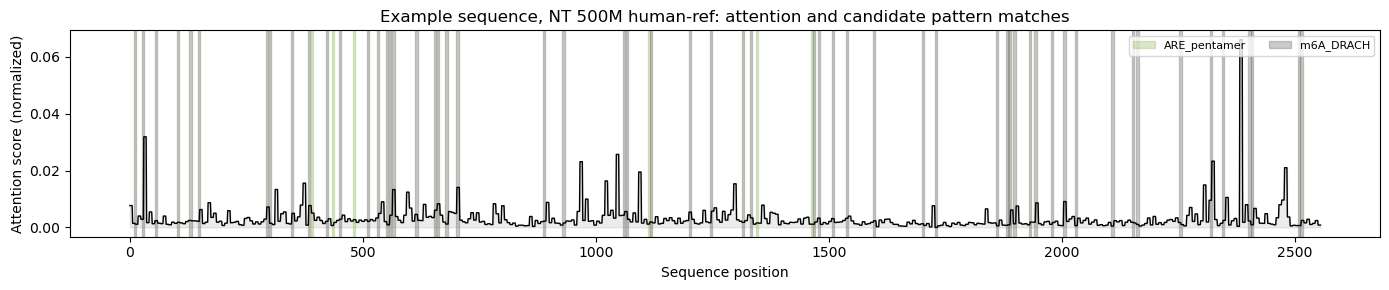

NT v2 100M multi-species: 2556 positions covered, 311 matched; mean attention at matches 0.13401, elsewhere 0.11912, nominal p 0.000


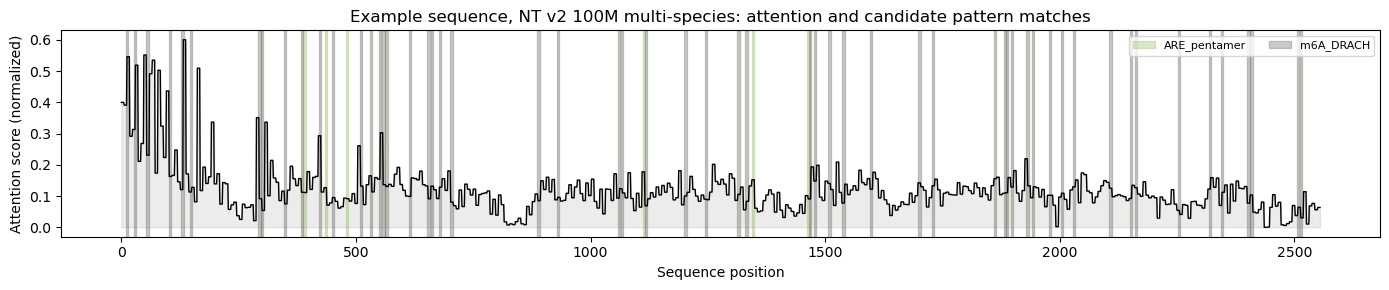

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/rnafm
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
ss_head.decoder.bias                | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RNA-FM: 1022 positions covered, 135 matched; mean attention at matches 0.01722, elsewhere 0.01375, nominal p 0.068


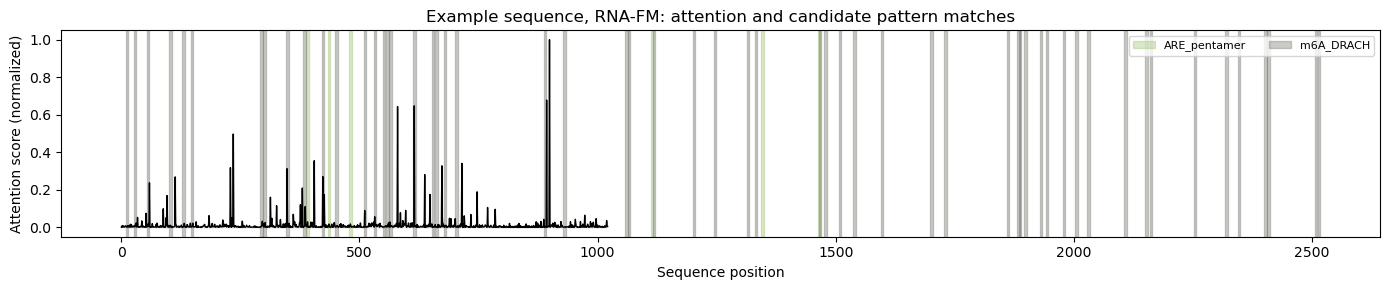

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

[transformers] RiNALMoModel LOAD REPORT from: multimolecule/rinalmo-mega
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight              | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RiNALMo 150M: 1022 positions covered, 135 matched; mean attention at matches 0.24294, elsewhere 0.22484, nominal p 0.019


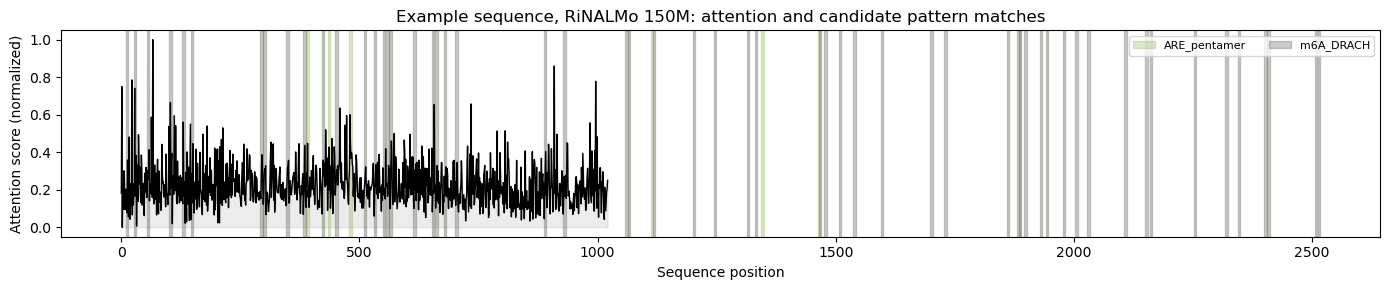

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/mrnafm
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
ss_head.decoder.bias                | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mRNA-FM: 2556 positions covered, 311 matched; mean attention at matches 0.00179, elsewhere 0.00123, nominal p 0.000


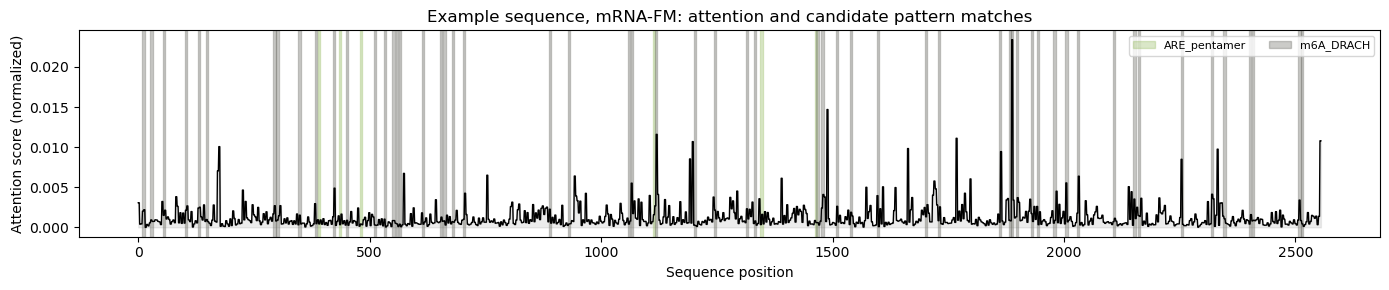

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

[transformers] CaLmModel LOAD REPORT from: multimolecule/calm
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CaLM: 2556 positions covered, 311 matched; mean attention at matches 0.05398, elsewhere 0.05685, nominal p 0.805


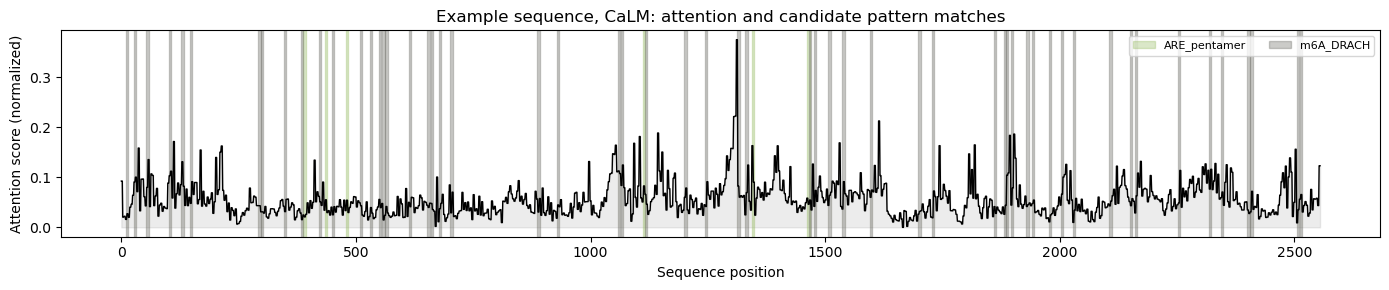

In [51]:
sample_seq = kept_seqs[0]
motif_hits = sequences.scan_sequence_for_motifs(sample_seq)
print(f"Example sequence: {len(sample_seq)} nucleotides, {len(motif_hits)} candidate matches.")

for key in ATTENTION_ENCODERS:
    encoder = encoders.ENCODERS[key]
    tokenizer, model = encoders.load_encoder(encoder, DEVICE, eager_attention=True)
    try:
        attention = embeddings.nucleotide_attention(sample_seq, encoder, tokenizer, model, DEVICE)
    except Exception as error:
        print(f"{encoder.label}: attention weights unavailable ({type(error).__name__}: {error})")
        continue
    finally:
        del model, tokenizer
        encoders.free_memory()
    result = analysis.attention_motif_overlap(attention, motif_hits)
    if result is None:
        print(f"{encoder.label}: no usable comparison for this sequence")
        continue
    print(
        f"{encoder.label}: {len(attention)} positions covered, {result['n_motif_positions']} matched; "
        f"mean attention at matches {result['mean_attention_at_motifs']:.5f}, "
        f"elsewhere {result['mean_attention_elsewhere']:.5f}, nominal p {result['p_value']:.3f}"
    )
    analysis.plot_attention_with_motifs(
        attention, motif_hits, title=f"Example sequence, {encoder.label}: attention and candidate pattern matches"
    )

**Results.** The example sequence is 2,556 nucleotides long with 63 candidate matches covering 311 positions.

| Encoder | Positions covered | Matched positions | Mean attention at matches | Mean elsewhere | Nominal $p$ |
|---|---:|---:|---:|---:|---:|
| NT 500M human-ref | 2,556 | 311 | 0.00310 | 0.00325 | 0.603 |
| NT v2 100M multi-species | 2,556 | 311 | 0.13401 | 0.11912 | below 0.001 |
| RNA-FM | 1,022 | 135 | 0.01722 | 0.01375 | 0.068 |
| RiNALMo 150M | 1,022 | 135 | 0.24294 | 0.22484 | 0.019 |
| mRNA-FM | 2,556 | 311 | 0.00179 | 0.00123 | below 0.001 |
| CaLM | 2,556 | 311 | 0.05398 | 0.05685 | 0.805 |

DNABERT-2 and HyenaDNA are not in `ATTENTION_ENCODERS`: DNABERT-2's model code returns no attention weights, and HyenaDNA has no attention layers.

**Interpretation.** Coverage follows the tokenizers. Both Nucleotide Transformer models and the two codon-level encoders cover the whole sequence, because each token spells up to six nucleotides or one codon, while RNA-FM and RiNALMo cover only their first 1,022 nucleotides and exclude the matches beyond them. For this sequence, Nucleotide Transformer 500M and CaLM attend slightly less to matched positions than to others and RNA-FM slightly more, with none of the three reaching the nominal 0.05 threshold. Nucleotide Transformer v2, RiNALMo, and mRNA-FM give more attention to matched positions, with nominal $p$-values of 0.019 or below.

The plots show why those $p$-values need care. Nucleotide Transformer v2's attention is highest over roughly the first 200 nucleotides and lower afterwards, so matches near the start gain attention from position alone; RiNALMo's highest values also sit near the start of its window. mRNA-FM's attention is concentrated in a few sharp peaks, and each codon's score is repeated over its three positions. A single example illustrates the calculation; it does not establish a biological association, and the positional test has the dependence and calibration limitations described above.

In [52]:
attention_seqs = kept_seqs[:ATTENTION_N_ROWS]
attention_profiles = {}
attention_results = {}
for key in ATTENTION_ENCODERS:
    attention_profiles[key] = embeddings.attention_profiles(encoders.ENCODERS[key], attention_seqs, DEVICE)
    attention_results[key] = analysis.attention_motif_tests(attention_profiles[key], attention_seqs)

analysis.attention_summary(attention_results, LABELS, sequences.STABILITY_MOTIFS).round(4)

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/rnafm
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
ss_head.decoder.bias                | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/mrnafm
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
ss_head.decoder.bias                | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

[transformers] CaLmModel LOAD REPORT from: multimolecule/calm
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


sequences with hits  \
encoder                  pattern                                    
NT 500M human-ref        All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
NT v2 100M multi-species All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
RNA-FM                   All patterns pooled                  100   
                         ARE_pentamer                          33   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
RiNALMo 150M             All patterns pooled                  100   
                         ARE_pentamer                          33   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
mRNA-FM                  All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
CaLM                     All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   

                                              fraction with nominal p < 0.05  \
encoder                  pattern                                               
NT 500M human-ref        All patterns pooled                          0.0700   
                         ARE_pentamer                                 0.0488   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.0800   
NT v2 100M multi-species All patterns pooled                          0.1500   
                         ARE_pentamer                                 0.3415   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.1400   
RNA-FM                   All patterns pooled                          0.0900   
                         ARE_pentamer                                 0.1212   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.0800   
RiNALMo 150M             All patterns pooled                          0.0400   
                         ARE_pentamer                                 0.2424   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.0200   
mRNA-FM                  All patterns pooled                          0.9300   
                         ARE_pentamer                                 0.0976   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.9200   
CaLM                     All patterns pooled                          0.1500   
                         ARE_pentamer                                 0.3659   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.1400   

                                              mean gap  
encoder                  pattern                        
NT 500M human-ref        All patterns pooled   -0.0009  

**Results.** First 100 retained sequences; every sequence had at least one usable match, and none contained the ARE nonamer. RNA-FM and RiNALMo find ARE pentamers in fewer sequences because they cover only the first 1,022 nucleotides.

| Encoder | Pattern | Sequences with hits | Fraction with nominal $p<0.05$ | Mean gap |
|---|---|---:|---:|---:|
| NT 500M human-ref | All patterns pooled | 100 | 0.07 | $-0.0009$ |
| NT 500M human-ref | ARE pentamer | 41 | 0.05 | $-0.0027$ |
| NT 500M human-ref | m6A DRACH | 100 | 0.08 | $-0.0009$ |
| NT v2 100M multi-species | All patterns pooled | 100 | 0.15 | $-0.0042$ |
| NT v2 100M multi-species | ARE pentamer | 41 | 0.34 | $+0.0110$ |
| NT v2 100M multi-species | m6A DRACH | 100 | 0.14 | $-0.0051$ |
| RNA-FM | All patterns pooled | 100 | 0.09 | $-0.0015$ |
| RNA-FM | ARE pentamer | 33 | 0.12 | $-0.0006$ |
| RNA-FM | m6A DRACH | 100 | 0.08 | $-0.0016$ |
| RiNALMo 150M | All patterns pooled | 100 | 0.04 | $-0.0084$ |
| RiNALMo 150M | ARE pentamer | 33 | 0.24 | $+0.0400$ |
| RiNALMo 150M | m6A DRACH | 100 | 0.02 | $-0.0099$ |
| mRNA-FM | All patterns pooled | 100 | 0.93 | $+0.0014$ |
| mRNA-FM | ARE pentamer | 41 | 0.10 | $-0.0011$ |
| mRNA-FM | m6A DRACH | 100 | 0.92 | $+0.0015$ |
| CaLM | All patterns pooled | 100 | 0.15 | $-0.0072$ |
| CaLM | ARE pentamer | 41 | 0.37 | $+0.0298$ |
| CaLM | m6A DRACH | 100 | 0.14 | $-0.0084$ |

**Interpretation.** Nucleotide Transformer 500M and RNA-FM show no higher final-layer incoming attention at these candidate stability patterns: their mean gaps are slightly negative, and their threshold fractions stay between 5% and 12%, near the 5% expected if attention and pattern positions were unrelated.

The other four encoders depart from that rate in two ways. Nucleotide Transformer v2, RiNALMo, and CaLM give ARE pentamers more attention in a quarter to a third of the sequences that contain one, with positive ARE gaps of 0.011 to 0.040, while their pooled and DRACH gaps are negative. mRNA-FM crosses the nominal threshold in 93 of 100 sequences, almost entirely through DRACH matches, but its mean gap is only 0.0015 on a zero-to-one scale. With about 2,500 positions per sequence and each codon score repeated over three positions, the rank test detects very small systematic shifts; attention that varies with position, or with which codon a position belongs to, could produce any of these results. The [next analysis](#Controlling-the-attention-test-for-position-and-codons) tests both alternatives.

The results are limited to these candidate patterns, 100 sequences, and final-layer incoming attention averaged over heads. They do not establish whether the encoders represent regulatory elements: attention in other layers or heads, or information carried in hidden states rather than attention weights, is not tested. The threshold fractions are not calibrated tests, because of positional dependence, repeated token scores, and multiple comparisons.

#### Controlling the attention test for position and codons

Attention can concentrate near a sequence's start, and codon encoders repeat one score across three positions. Either property can favor candidate matches without identifying their regulatory role. `analysis.motif_permutation_test` compares the observed gap with label shuffles that retain selected positional or sequence-composition properties. The [permutation-control guide](../docs/methods/attention-and-motifs.md#controlling-the-attention-test-for-position-and-codons) explains the procedure and its assumptions.

**1. Average the observed gaps.**

$$
G=\frac{1}{m}\sum_{i=1}^{m}\Delta_i.
$$

**In this notation:**

- $\Delta_i$ is sequence $i$'s matched-minus-other gap for one pattern or all patterns pooled.
- $m$ counts sequences with both matched and other covered positions.
- $G$ averages the same per-sequence gap as `attention_summary`, but each permutation comparison selects its own usable sequences.

**2. Shuffle matched labels within strata.**

For each of `ATTENTION_NULL_PERMUTATIONS` rounds, shuffle which positions count as matched within each sequence and stratum, retaining its matched count, then recompute $G$.

| Null | Positions exchanging labels | Preserved property |
|---|---|---|
| Position | Same 100-nucleotide bin | Number of matched positions in each bin |
| Codon and frame | Same codon and same position within it | Codon identity and within-codon position of matched labels |

**3. Compare observed and shuffled statistics.**

$$
p=\frac{1+\#\{r:G^{(r)}\ge G\}}{R+1}.
$$

**In this notation:**

- $R$ is the shuffle count; $G^{(r)}$ is the statistic after shuffle $r$.
- $\#$ counts shuffled statistics at least as large as observed. Adding 1 gives a minimum of $1/(R+1)$, about 0.002 for 500 shuffles.

**Interpretation.** This is a one-sided comparison conditional on the chosen strata. The position null retains bin-level occupancy, not exact positions or arbitrary within-bin trends. The codon null retains the stated codon/frame grouping. Shuffled masks need not form intact motif occurrences; the interpretation requires matched labels to be exchangeable within strata under the chosen null.

The table reports observed $G$, mean shuffled gap, their difference (`excess gap`), and permutation $p$. Its usable set can differ from `attention_summary`, which first discards sequences with unavailable pooled comparisons. A small p-value identifies a departure from that specific null, not a regulatory mechanism. Comparisons with no usable sequences are omitted. The tests reuse the same 100 sequences and do not correct for multiple encoders, patterns, or nulls.

In [ ]:
show_source(analysis.motif_permutation_test, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.motif_permutation_test` (line 472)](mbf/analysis.py#L472)

In [54]:
null_rows = []
for key, profiles in attention_profiles.items():
    for motif in [None, *sequences.STABILITY_MOTIFS]:
        for strata, kept in (("position", "position"), ("codon", "codon and frame")):
            result = analysis.motif_permutation_test(
                profiles, attention_seqs, motif=motif, strata=strata,
                n_permutations=ATTENTION_NULL_PERMUTATIONS, seed=SEED,
            )
            if result is not None:
                null_rows.append({
                    "encoder": LABELS[key], "pattern": motif or "All patterns pooled", "null keeps": kept, **result,
                })

pd.DataFrame(null_rows).set_index(["encoder", "pattern", "null keeps"]).round(4)

sequences  \
encoder                  pattern             null keeps                   
NT 500M human-ref        All patterns pooled position               100   
                                             codon and frame        100   
                         ARE_pentamer        position                41   
                                             codon and frame         41   
                         m6A_DRACH           position               100   
                                             codon and frame        100   
NT v2 100M multi-species All patterns pooled position               100   
                                             codon and frame        100   
                         ARE_pentamer        position                41   
                                             codon and frame         41   
                         m6A_DRACH           position               100   
                                             codon and frame        100   
RNA-FM                   All patterns pooled position               100   
                                             codon and frame        100   
                         ARE_pentamer        position                33   
                                             codon and frame         33   
                         m6A_DRACH           position               100   
                                             codon and frame        100   
RiNALMo 150M             All patterns pooled position               100   
                                             codon and frame        100   
                         ARE_pentamer        position                33   
                                             codon and frame         33   
                         m6A_DRACH           position               100   
                                             codon and frame        100   
mRNA-FM                  All patterns pooled position               100   
                                             codon and frame        100   
                         ARE_pentamer        position                41   
                                             codon and frame         41   
                         m6A_DRACH           position               100   
                                             codon and frame        100   
CaLM                     All patterns pooled position               100   
                                             codon and frame        100   
                         ARE_pentamer        position                41   
                                             codon and frame         41   
                         m6A_DRACH           position               100   
                                             codon and frame        100   

                                                              observed gap  \
encoder                  pattern             null keeps                      
NT 500M human-ref        All patterns pooled position              -0.0009   
                                             codon and frame       -0.0009   
                         ARE_pentamer        position              -0.0027   
                                             codon and frame       -0.0027   
                         m6A_DRACH           position              -0.0009   
                                             codon and frame       -0.0009   
NT v2 100M multi-species All patterns pooled position              -0.0042   
                                             codon and frame       -0.0042   
                         ARE_pentamer        position               0.0110   
                                             codon and frame        0.0110   
                         m6A_DRACH           position              -0.0051   
                                             codon and frame       -0.0051   
RNA-FM                   All patterns pooled position              -0.0015   
                                         

**Results.** The rows whose permutation $p$ is below 0.05 under either null; every other row in the table has $p$ of at least 0.54.

| Encoder | Pattern | Observed gap | Position null: excess gap ($p$) | Codon-and-frame null: excess gap ($p$) |
|---|---|---:|---:|---:|
| NT v2 100M multi-species | ARE pentamer | $+0.0110$ | $+0.0149$ (0.014) | $+0.0061$ (0.200) |
| RiNALMo 150M | ARE pentamer | $+0.0400$ | $+0.0424$ (0.002) | $-0.0008$ (0.585) |
| mRNA-FM | All patterns pooled | $+0.0014$ | $+0.0014$ (0.002) | $+0.0001$ (0.072) |
| mRNA-FM | m6A DRACH | $+0.0015$ | $+0.0014$ (0.002) | $+0.0001$ (0.082) |
| CaLM | ARE pentamer | $+0.0298$ | $+0.0302$ (0.002) | $+0.0140$ (0.002) |

**Interpretation.** Position does not explain these associations: each keeps almost its whole gap when matched labels move only within 100-nucleotide bins. Codon context explains most of them. Once labels move only among positions with the same codon and the same place within it, mRNA-FM's DRACH shift falls to 0.0001 and RiNALMo's ARE gap disappears, so both encoders attend to the codons that these patterns occupy rather than to the patterns. Nucleotide Transformer v2 keeps about half of its ARE gap under the codon null, without reaching 0.05.

CaLM is the one encoder whose association survives both nulls: under the codon-and-frame null it keeps an excess gap of 0.014, about half its observed gap, with $p$ at the smallest attainable value. CaLM therefore gives more attention to AUUUA pentamers within coding sequence than their codons, their reading frame, or their position explain. This rests on 41 sequences and one attention summary, and 500 shuffles cannot produce a $p$ small enough to pass a Bonferroni correction for the 36 tests in the table, so it is a candidate for follow-up rather than an established association. Any such follow-up needs data with 3' untranslated regions, where AU-rich elements act; the [GTEx attention analysis](Stage1_gtex.ipynb#Attention-at-candidate-patterns-in-3'-untranslated-regions) covers that for the single-nucleotide RNA encoders.

---

#### Sample-level alignment and prediction error

This exploratory diagnostic asks whether examples with more similar paired representations are easier to predict. It adapts the motivation of [Tjandrasuwita et al. (ICML 2025), Sections 5–6](https://proceedings.mlr.press/v267/tjandrasuwita25a.html); it does not reproduce their across-model comparisons or contrastive-training intervention. See the [sample-level diagnostic guide](../docs/methods/representation-comparison.md#sample-level-alignment-and-prediction-error) for the derivation and worked example.

Each encoder pair supplies `cca_results[(a, b)]["test_coords"]` and `labels[test_idx]`: corresponding CCA vectors and stability labels from the earlier test subset. PCA and CCA remain fixed; this diagnostic fits new ordinary linear regressions.

For each example, compare the directions of its nonzero CCA vectors using [cosine similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html):

$$
c_i = \frac{\mathbf u_i^\top\mathbf v_i}{\|\mathbf u_i\|_2\,\|\mathbf v_i\|_2}.
$$

**In this notation:**

- $\mathbf u_i$ and $\mathbf v_i$ are example $i$'s matched vectors, each with $d=10$ CCA coordinates.
- $\top$ denotes transpose, the numerator is their dot product, and $\|\cdot\|_2$ is Euclidean length.
- $c_i$ is their cosine score, from $-1$ to $1$; larger values mean more similar directions in this fitted coordinate system.

**Interpretation.** This is a chosen alignment score, not a biological measurement. The ratio is undefined for zero vectors; the library returns zero, which does not define a direction.

Append the coordinates as $\mathbf z_i=[\mathbf u_i;\mathbf v_i]$, a vector with $2d=20$ coordinates; the semicolon means concatenation. Then measure absolute error from a regression fitted without that example's fold:

$$
e_i=\left|y_i-\hat f_{-F(i)}(\mathbf z_i)\right|.
$$

**In this notation:**

- $y_i$ is the observed stability label; $F(i)$ is its held-out regression fold.
- $\hat f_{-F(i)}$ is ordinary least squares with an intercept fitted on the other folds; $e_i$ is the absolute prediction error.

**Interpretation.** Five shuffled `KFold` splits using `SEED` give each row an error from a regression that excluded it. PCA/CCA were fitted on a separate subset using a sequence-grouped holdout; these new regression folds are row-wise and do not keep duplicate sequences together.

Finally, compare alignment ranks with error ranks:

$$
\rho_s=\operatorname{corr}\!\left(\operatorname{rank}(\mathbf c),\operatorname{rank}(\mathbf e)\right).
$$

**In this notation:**

- $\mathbf c$ and $\mathbf e$ collect corresponding scores and errors.
- $\operatorname{rank}$ assigns average ranks to ties; $\operatorname{corr}$ is Pearson correlation, giving Spearman's $\rho_s$.

**Interpretation.** Negative $\rho_s$ means higher alignment accompanies smaller errors. `analysis.alignment_error_association` uses [`spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) to return this coefficient and a nominal p-value, not an alignment–error slope. Constant scores or errors make the coefficient undefined. Shared transformations, overlapping regression training folds, and repeated sequences limit independent-observation interpretations. This association neither estimates an alignment-loss intervention nor establishes modality uniqueness.

In [ ]:
show_source(analysis.alignment_error_association, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.alignment_error_association` (line 262)](mbf/analysis.py#L262)

#### Representational similarity analysis

Representational similarity analysis (RSA) asks whether the same example pairs are dissimilar within two representations. It compares all matched final-layer `EMBEDDINGS`, fits no predictor or projection, and needs corresponding row order even when feature counts differ. The [RSA guide](../docs/methods/representation-comparison.md#representational-similarity-analysis) develops the calculations and worked example.

For each representation, center every row across its own features:

$$
\widetilde{\mathbf x}_i=\mathbf x_i-\bar x_i\mathbf 1_p.
$$

**In this notation:**

- $X$ has $n$ matched example rows and $p$ features; $\mathbf x_i$ is row $i$, $\bar x_i$ its mean feature value, and $\mathbf 1_p$ a vector of ones.
- $\widetilde{\mathbf x}_i$ is the centered row.

**Interpretation.** This differs from CKA's centering of each feature across examples. [SciPy's correlation distance](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.correlation.html) compares these centered profiles:

$$
d_X(i,j)=1-\frac{\widetilde{\mathbf x}_i^\top\widetilde{\mathbf x}_j}{\|\widetilde{\mathbf x}_i\|_2\,\|\widetilde{\mathbf x}_j\|_2}.
$$

**In this notation:**

- $\top$ denotes transpose; the numerator is a dot product and $\|\cdot\|_2$ Euclidean length.
- $d_X(i,j)$ is the distance between distinct rows $i,j$. The same calculation within $Y$ uses its own $q$ features; individual features are not matched across encoders.

**Interpretation.** Correlations $1,0,-1$ give distances $0,1,2$. Constant feature profiles make distances undefined; the helper adds no special handling.

[`pdist`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html) collects each unordered pair once, in matching order, then `analysis.compute_rsa` compares the distance ranks:

$$
M=\frac{n(n-1)}{2},
\qquad
\rho_{\mathrm{RSA}}=\operatorname{corr}\!\left(\operatorname{rank}(\mathbf d_X),\operatorname{rank}(\mathbf d_Y)\right).
$$

**In this notation:**

- $\mathbf d_X,\mathbf d_Y$ each contain $M$ distances for pairs $i<j$.
- $\operatorname{rank}$ assigns average ranks to ties; $\operatorname{corr}$ is Pearson correlation, so the result is Spearman correlation.

**Interpretation.** Positive RSA means agreement in distance rankings, not a particular shared subspace or biological mechanism. Constant distance vectors make RSA undefined. With 981 rows there are 480,690 distances, but pairs share examples: the default Spearman p-value is nominal, not a calibrated geometry test.

`analysis.mantel_p_value` instead permutes sequence identities, keeping each distance matrix's internal structure intact:

$$
p_{\mathrm{Mantel}}=\frac{1+\#\{\pi:r_\pi\ge r_{\mathrm{obs}}\}}{P+1}.
$$

**In this notation:**

- $r_{\mathrm{obs}}$ is observed RSA; $r_\pi$ follows a joint row-and-column reordering $\pi$ of the second distance matrix.
- $P=499$ permutations; $\#$ counts those reaching the observed value. The minimum p-value is $1/500=0.002$.

**Interpretation.** This one-sided test accounts for shared pair entries by shuffling whole examples. Its validity requires exchangeable sequence identities under the null; shuffling alone does not establish that assumption for repeated or related sequences. The implementation ranks once, then permutes the second rank matrix. RSA reuses the earlier embeddings, so it is descriptive evidence rather than independent confirmation of the other metrics.

In [ ]:
show_source(analysis.compute_rsa, analysis.mantel_p_value, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.compute_rsa` (line 308)](mbf/analysis.py#L308), [`analysis.mantel_p_value` (line 313)](mbf/analysis.py#L313)

#### Run and interpret the alignment diagnostics

The loop below runs both diagnostics for every pair of encoders. They use different representations and sets of rows:

| Diagnostic | Inputs | Reported quantity |
|---|---|---|
| Alignment and prediction error | Held-out CCA vectors `cca_results[(a, b)]["test_coords"]`, with the corresponding `labels[test_idx]` | Spearman association between per-example cosine similarity and out-of-fold absolute error |
| RSA | All matched final-layer embeddings, `EMBEDDINGS[a]` and `EMBEDDINGS[b]` | Spearman agreement between within-modality pairwise-distance rankings, with the default and Mantel permutation $p$-values |

The first diagnostic fits its regression folds inside the earlier CCA test subset; that subset was held out when PCA and CCA were fitted. This distinction matters: the same phrase "held out" refers to two different fitting steps. The second diagnostic fits no predictor. Both results summarize the existing procedure and do not select an alignment objective for the next stage.

For the derivations and examples, see [alignment and prediction error](../docs/methods/representation-comparison.md#sample-level-alignment-and-prediction-error) and [RSA](../docs/methods/representation-comparison.md#representational-similarity-analysis).


In [57]:
diagnostic_rows = []
for a, b in PAIRS:
    a_test_c, b_test_c = cca_results[(a, b)]["test_coords"]
    association = analysis.alignment_error_association(a_test_c, b_test_c, labels[test_idx], seed=SEED)
    rsa, rsa_p = analysis.compute_rsa(EMBEDDINGS[a], EMBEDDINGS[b])
    diagnostic_rows.append({
        "pair": f"{LABELS[a]} / {LABELS[b]}",
        "comparison": f"within {MODALITY[a]}" if MODALITY[a] == MODALITY[b] else "across modalities",
        "alignment vs. error, Spearman rho": association["spearman"],
        "nominal p": association["p_value"],
        "RSA": rsa,
        "default p": rsa_p,
        "Mantel p": analysis.mantel_p_value(EMBEDDINGS[a], EMBEDDINGS[b], seed=SEED),
    })

print(f"Bonferroni threshold for {len(PAIRS)} pairs at 0.05: {0.05 / len(PAIRS):.4f}")
pd.DataFrame(diagnostic_rows).set_index("pair").round(4)

Bonferroni threshold for 66 pairs at 0.05: 0.0008


,comparison,"alignment vs. error, Spearman rho",nominal p,RSA,default p,Mantel p
pair,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,0.0509,0.3865,0.3015,0.0,0.002
NT 500M human-ref / DNABERT-2,within DNA,0.0201,0.7334,0.6981,0.0,0.002
NT 500M human-ref / HyenaDNA large,within DNA,0.0486,0.4085,0.6476,0.0,0.002
NT 500M human-ref / RNA-FM,across modalities,-0.0889,0.1305,0.5480,0.0,0.002
NT 500M human-ref / RiNALMo 150M,across modalities,0.0315,0.5922,0.5107,0.0,0.002
...,...,...,...,...,...,...
ESM-2 8M / ESM-2 150M,within protein,0.0641,0.2755,0.6155,0.0,0.002
ESM-2 8M / ProtBERT,within protein,0.0285,0.6282,0.2998,0.0,0.002
ESM-2 35M / ESM-2 150M,within protein,-0.0008,0.9885,0.7392,0.0,0.002


**Results.** Alignment against prediction error uses the 291 CCA test rows; RSA uses all 981 rows.

- **Alignment against error.** Spearman $\rho$ ranges from $-0.125$ to $+0.122$ across the 66 pairs. Four pairs have a nominal $p$ below 0.05, the smallest 0.033 for RiNALMo with ESM-2 8M; none is below the Bonferroni threshold of 0.0008.
- **RSA.** Every default $p$ prints as 0. The Mantel $p$ is 0.002 for 61 pairs, 0.004 to 0.016 for Nucleotide Transformer v2 with ESM-2 35M and 150M and for mRNA-FM with ESM-2 8M and 35M, and 0.056 for mRNA-FM with ESM-2 150M.

| Group of pairs | RSA |
|---|---:|
| Within ESM-2 | 0.616 to 0.818 |
| ProtBERT with ESM-2 | 0.300 to 0.350 |
| Within DNA | 0.269 to 0.698 |
| RNA-FM with RiNALMo | 0.758 |
| mRNA-FM with CaLM | 0.112 |
| DNA with RNA-FM or RiNALMo | 0.207 to 0.627 |
| DNA with mRNA-FM | 0.074 to 0.101 |
| DNA with CaLM | 0.139 to 0.479 |
| DNA with protein | 0.031 to 0.265 |
| RNA-FM or RiNALMo with mRNA-FM | 0.076 to 0.080 |
| RNA-FM or RiNALMo with CaLM | 0.469 to 0.556 |
| RNA-FM or RiNALMo with protein | 0.174 to 0.340 |
| mRNA-FM with protein | 0.041 to 0.126 |
| CaLM with protein | 0.351 to 0.469 |

**Interpretation.** How well a sequence's two representations align has no detectable relationship with how accurately its stability is predicted, for any pair: the few nominal associations are weak, run in both directions, and do not survive correction for testing 66 pairs. These use the 291 CCA test rows, and this is not the paper's across-model slope.

RSA ranks the pairs much as CKA does. The ESM-2 models' distance structures agree most, then RNA-FM with RiNALMo, then the encoders that read single letters or short tokens of the same nucleotide sequence; CaLM's distance structure resembles the protein encoders' and the single-nucleotide RNA encoders'. mRNA-FM's barely resembles any other encoder's (at most 0.126), and its agreement with ESM-2 150M does not reach the 0.05 level under the Mantel test even though mRNA-FM finds protein partners well under CCA. Agreement in a few fitted directions and agreement of whole distance structures are therefore different properties.

The default $p$-values are below $10^{-100}$ and print as 0; they come from an approximation that assumes independent observations, which pairwise distances are not. The Mantel permutation test accounts for the dependence between pairwise distances, and 0.002 is the smallest value attainable with 499 permutations. The [composition control](#Composition-control) suggests that much of the shared structure involving DNA encoders reflects composition.

Together with the predictive probes, geometry comparisons, and attention summaries, these diagnostics describe the frozen representations. They leave the alignment objective and fusion design open.

---

### Published-split comparison

The probes above use five grouped folds on a 981-sequence sample. [BioLangFusion](../Papers/BioLangFusion.pdf), Table 1, instead trains on the dataset's published training split and reports the Spearman correlation between predicted and measured stability on its published test split. This section places the frozen encoders on that footing.

**1. Sample the published splits.** `datasets.official_split_sample` draws `BENCHMARK_N_TRAIN` rows from the published training split and `BENCHMARK_N_TEST` rows from the published test split, before filtering, and applies the same sequence filters as the main sample. Each encoder embeds both sets; the saved matrices go to `BENCHMARK_TRAIN_DIR` and `BENCHMARK_TEST_DIR`.

**2. Fit once and score the test rows.** `analysis.fit_predict` fits the same standardized ridge probe on the sampled training rows and predicts the sampled test rows. The table reports the Spearman correlation, BioLangFusion's metric, and $R^2$ on the test rows, for each encoder, for mRNA-FM concatenated with each protein encoder, for BioLangFusion's three encoders concatenated, and for all encoders concatenated.

**3. Separate test sequences that also occur in training.** The [dataset audit](#Dataset-audit-for-published-comparisons) shows that the published split places thousands of identical sequences in both training and test. The table therefore also reports the Spearman correlation on the test rows whose sequence occurs nowhere in the full published training split, which is the comparison free of that overlap.

**Published values for reference.** BioLangFusion, Table 1, mRNA stability, Spearman correlation: Nucleotide Transformer 0.530, RNA-FM 0.553, ESM-2 8M 0.539; concatenation 0.539; MIL with entropy regularization 0.563; cross attention 0.550.

These values are not directly comparable with the table below. BioLangFusion trains a TextCNN prediction head on token-level embeddings, using its filtered version of the data, 23,929 sequences (Appendix A.2), while this section fits a linear probe on mean-pooled embeddings from a few thousand sampled rows of a different version of the file. The comparison shows whether frozen pooled embeddings reach a similar range, not which method is better.

In [ ]:
show_source(datasets.official_split_sample, analysis.fit_predict, full=SHOW_IMPLEMENTATION)


Implementation: [`datasets.official_split_sample` (line 185)](mbf/datasets.py#L185), [`analysis.fit_predict` (line 208)](mbf/analysis.py#L208)

In [59]:
bench_train, bench_test = datasets.official_split_sample(DATASET, BENCHMARK_N_TRAIN, BENCHMARK_N_TEST, seed=SEED)

all_rows = datasets.sample_rows(DATASET)
spec = dataset.spec
published_train_sequences = set(
    all_rows.loc[all_rows[spec.split_column] == "train", spec.sequence_column].astype(str).str.strip().str.upper()
)
unseen = np.array([s not in published_train_sequences for s in bench_test.sequences])
print(f"Published train split: {len(bench_train.sequences)} of {bench_train.n_sampled} sampled rows retained.")
print(
    f"Published test split: {len(bench_test.sequences)} of {bench_test.n_sampled} sampled rows retained; "
    f"{unseen.sum()} have a sequence that occurs nowhere in the published train split."
)

BENCH_TRAIN, BENCH_TEST = {}, {}
for encoder in ENCODERS:
    BENCH_TRAIN[encoder.key], _ = embeddings.embed_with_cache(
        encoder, bench_train.sequences, BENCHMARK_TRAIN_DIR, DEVICE
    )
    BENCH_TEST[encoder.key], _ = embeddings.embed_with_cache(
        encoder, bench_test.sequences, BENCHMARK_TEST_DIR, DEVICE
    )
    print(f"{encoder.label}: embedded")

Published train split: 2937 of 3000 sampled rows retained.
Published test split: 981 of 1000 sampled rows retained; 295 have a sequence that occurs nowhere in the published train split.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    nt500m: 200/2937
    nt500m: 400/2937
    nt500m: 600/2937
    nt500m: 800/2937
    nt500m: 1000/2937
    nt500m: 1200/2937
    nt500m: 1400/2937
    nt500m: 1600/2937
    nt500m: 1800/2937
    nt500m: 2000/2937
    nt500m: 2200/2937
    nt500m: 2400/2937
    nt500m: 2600/2937
    nt500m: 2800/2937


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    protbert: 200/2937
    protbert: 400/2937
    protbert: 600/2937
    protbert: 800/2937
    protbert: 1000/2937
    protbert: 1200/2937
    protbert: 1400/2937
    protbert: 1600/2937
    protbert: 1800/2937
    protbert: 2000/2937
    protbert: 2200/2937
    protbert: 2400/2937
    protbert: 2600/2937
    protbert: 2800/2937


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    protbert: 200/981
    protbert: 400/981
    protbert: 600/981
    protbert: 800/981
ProtBERT: embedded


In [60]:
def published_split_scores(keys):
    """Fit the probe on the sampled published training rows and score the sampled test rows."""
    X_train = np.hstack([BENCH_TRAIN[k] for k in keys])
    X_test = np.hstack([BENCH_TEST[k] for k in keys])
    predicted = analysis.fit_predict(X_train, bench_train.labels, X_test)
    return {
        "Spearman, all test rows": spearmanr(predicted, bench_test.labels)[0],
        "Spearman, test sequences absent from training": spearmanr(predicted[unseen], bench_test.labels[unseen])[0],
        "R2, all test rows": r2_score(bench_test.labels, predicted),
    }


bench_sets = {LABELS[k]: [k] for k in ENCODER_KEYS}
bench_sets.update(
    {f"{LABELS['mrnafm']} + {LABELS[k]}": ["mrnafm", k] for k in ENCODER_KEYS if MODALITY[k] == "protein"}
)
BIOLANGFUSION_KEYS = ["ntv2_100m", "rnafm", "esm2_8m"]
bench_sets["BioLangFusion encoders: " + ", ".join(LABELS[k] for k in BIOLANGFUSION_KEYS)] = BIOLANGFUSION_KEYS
bench_sets["All encoders"] = ENCODER_KEYS

pd.DataFrame({name: published_split_scores(keys) for name, keys in bench_sets.items()}).T.round(3)

,"Spearman, all test rows","Spearman, test sequences absent from training","R2, all test rows"
NT 500M human-ref,0.275,0.280,0.082
NT v2 100M multi-species,0.275,0.290,0.080
DNABERT-2,0.297,0.270,0.091
HyenaDNA large,0.286,0.224,0.085
RNA-FM,0.292,0.317,0.088
RiNALMo 150M,0.322,0.330,0.117
mRNA-FM,0.328,0.326,0.120
CaLM,0.377,0.391,0.153
ESM-2 8M,0.329,0.299,0.131
ESM-2 35M,0.329,0.312,0.122


**Results.** The sample keeps 2,937 of the 3,000 rows drawn from the published training split and 981 of the 1,000 drawn from the published test split; 295 of the test rows have a sequence that occurs nowhere in the full published training split.

| Encoders | Spearman, all test rows | Spearman, test sequences absent from training | $R^2$, all test rows |
|---|---:|---:|---:|
| NT 500M human-ref | 0.275 | 0.280 | 0.082 |
| NT v2 100M multi-species | 0.275 | 0.290 | 0.080 |
| DNABERT-2 | 0.297 | 0.270 | 0.091 |
| HyenaDNA large | 0.286 | 0.224 | 0.085 |
| RNA-FM | 0.292 | 0.317 | 0.088 |
| RiNALMo 150M | 0.322 | 0.330 | 0.117 |
| mRNA-FM | 0.328 | 0.326 | 0.120 |
| CaLM | 0.377 | 0.391 | 0.153 |
| ESM-2 8M | 0.329 | 0.299 | 0.131 |
| ESM-2 35M | 0.329 | 0.312 | 0.122 |
| ESM-2 150M | 0.371 | 0.373 | 0.143 |
| ProtBERT | 0.396 | 0.433 | 0.172 |
| mRNA-FM + ESM-2 8M | 0.336 | 0.314 | 0.133 |
| mRNA-FM + ESM-2 35M | 0.337 | 0.320 | 0.128 |
| mRNA-FM + ESM-2 150M | 0.377 | 0.368 | 0.154 |
| mRNA-FM + ProtBERT | 0.392 | 0.417 | 0.166 |
| BioLangFusion's encoders: NT v2 100M, RNA-FM, ESM-2 8M | 0.364 | 0.351 | 0.146 |
| All encoders | 0.401 | 0.402 | 0.175 |

**Interpretation.** On the published split the frozen encoders keep the order seen under cross-validation. ProtBERT, CaLM, and ESM-2 150M lead (Spearman 0.371 to 0.396 on all test rows), and the encoders that read single nucleotides, six-nucleotide tokens, or byte-pair tokens trail (0.275 to 0.322). The scores on test sequences absent from training are within 0.04 of those on all test rows for every encoder except HyenaDNA, which drops from 0.286 to 0.224. With 295 rows, a Spearman correlation near 0.35 has a standard error of about 0.05, so differences of a few hundredths between columns or encoders are within sampling noise.

Concatenation helps less here than under cross-validation. mRNA-FM with ProtBERT or ESM-2 150M scores about the same as the protein encoder alone, and all twelve encoders together reach 0.401, against 0.396 for ProtBERT alone. BioLangFusion's three encoders together reach 0.364, above each of them alone (0.275 to 0.329).

The frozen probes stay well below BioLangFusion's published values: 0.364 for its three encoders concatenated here, against 0.539 for its concatenation baseline and 0.563 for its best fusion. The comparison is not like for like. BioLangFusion trains a TextCNN head on token-level embeddings with 23,929 filtered sequences, while this probe is linear, uses one mean-pooled vector per sequence, and trains on 2,937 rows of a different version of the file. The gap is therefore an upper bound on what trained heads, token-level inputs, and more data add together, not a measure of any one of them. Reproducing BioLangFusion's head on these embeddings would separate those factors.

---

## Summary

The result notes beside each analysis retain the observations for this experiment. The [cross-dataset summary](Stage1_analysis.ipynb#Summary) brings the stability and GTEx findings together and explains their implications for alignment and fusion.
